# Static glove → robot amb bottleneck

Aquest notebook parteix del teu codi base `Static_glove_to_robot`.

S'hi afegeix una **estrangulació intermèdia** (*bottleneck*) a la xarxa neuronal:

```text
dades estàtiques del guant → capes denses → bottleneck → capes decoder → joints robot
```

Configuració inicial:

```python
bottleneck_dim = 6
```

L'objectiu és comprovar si la informació del guant es pot reduir abans de predir els 16 joints estàtics del robot.


## Afegit en aquesta versió

S'ha incorporat una cel·la de **resum de prediccions per posició estàtica**. Per cada postura es genera una figura 2×2 amb:

- valors reals del robot;
- predicció mitjana de la xarxa;
- desviació estàndard de la predicció;
- mètriques exportades en CSV.

També s'ha afegit una cel·la final per comprimir i descarregar tots els resultats en ZIP des de Google Colab.


In [1]:
import yaml
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)


In [2]:
from pathlib import Path
import zipfile

# Nom del ZIP que has pujat a Colab
zip_path = Path("/content/TFM.zip")

# Carpeta on es descomprimirà
base_dir = Path("/content/TFM")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(base_dir)

print("ZIP descomprimit a:", base_dir)
print(list(base_dir.iterdir()))

ZIP descomprimit a: /content/TFM
[PosixPath('/content/TFM/CyberGlove_multi_moviments_0_100.ipynb'), PosixPath('/content/TFM/Static_glove_to_robot.ipynb'), PosixPath('/content/TFM/Moviments Ma Robot'), PosixPath('/content/TFM/Moviments guant'), PosixPath('/content/TFM/Movements_glove_to_robot.ipynb'), PosixPath('/content/TFM/CyberGlove_static_vs_robot_0_100.ipynb'), PosixPath('/content/TFM/Estatic Guant')]


In [3]:
glove_movements_dir = base_dir / "Moviments guant"
robot_movements_dir = base_dir / "Moviments Ma Robot"
glove_static_dir = base_dir / "Estatic Guant"

data_dir = glove_movements_dir
robot_data_dir = robot_movements_dir

glove_ranges_yaml_path = glove_movements_dir / "AA_Rangs1.yaml"

In [4]:
# ============================================================
# CONFIGURACIÓ
# ============================================================

data_dir = glove_static_dir
static_file_pattern = "A_*Stat*.yaml"
glove_ranges_yaml_path = glove_static_dir / "AA_Rangs1.yaml"

glove_value_key = "calib_deg"
clip_to_0_100 = True

# "all" = usa els 22 joints del guant
# "robot_common" = usa només els 16 joints comuns amb el robot
use_glove_joints = "all"

test_size = 0.20
random_state = 42

epochs = 120
batch_size = 64
learning_rate = 1e-3

# ============================================================
# CONFIGURACIÓ BOTTLENECK
# ============================================================

use_bottleneck = True
bottleneck_dim = 6  # reducció lleugera inicial. Pots provar 16, 12, 8...
bottleneck_activation = "linear"
bottleneck_l1 = 0.0

output_dir = Path("nn_static_glove_to_robot_bottleneck")
output_dir.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})


In [5]:
# ============================================================
# ORDRES DE JOINTS
# ============================================================

glove_joint_order = [
    "Thumb j1", "Thumb j2", "Thumb j3", "Thumb j0",
    "Index j1", "Index j2", "Index j3",
    "Middle j1", "Middle j2", "Middle j3",
    "Index j0",
    "Annular j1", "Annular j2", "Annular j3", "Annular j0",
    "Pinky j1", "Pinky j2", "Pinky j3", "Pinky j0",
    "Middle j0",
    "Wrist j1", "Wrist j0",
]

robot_joint_order = [
    "Index j0", "Index j1", "Index j2", "Index j3",
    "Middle j0", "Middle j1", "Middle j2", "Middle j3",
    "Annular j0", "Annular j1", "Annular j2", "Annular j3",
    "Thumb j0", "Thumb j1", "Thumb j2", "Thumb j3",
]


In [6]:
# ============================================================
# LIMITS DEL ROBOT
# ============================================================

robot_joint_limits = {
    "Index j0":   {"min": -0.596932, "max": 0.588071},
    "Index j1":   {"min": -0.284220, "max": 1.798060},
    "Index j2":   {"min": -0.277444, "max": 1.772960},
    "Index j3":   {"min": -0.282001, "max": 1.760870},

    "Middle j0":  {"min": -0.596932, "max": 0.588071},
    "Middle j1":  {"min": -0.284220, "max": 1.798060},
    "Middle j2":  {"min": -0.277444, "max": 1.772960},
    "Middle j3":  {"min": -0.282001, "max": 1.760870},

    "Annular j0": {"min": -0.596932, "max": 0.588071},
    "Annular j1": {"min": -0.284220, "max": 1.798060},
    "Annular j2": {"min": -0.277444, "max": 1.772960},
    "Annular j3": {"min": -0.282001, "max": 1.760870},

    "Thumb j0":   {"min":  0.218668, "max": 1.532940},
    "Thumb j1":   {"min": -0.396993, "max": 1.202960},
    "Thumb j2":   {"min": -0.251244, "max": 1.767010},
    "Thumb j3":   {"min": -0.260209, "max": 1.822620},
}


In [7]:
# ============================================================
# VALORS ESTÀTICS DEL ROBOT
# Ordre: index, middle, annular, thumb. 4 joints per dit.
# ============================================================

robot_static_values = {
    "BotiStat": [
        -0.11920892271473398, 1.6322657332846189, 1.3367731765330555, -0.23859537174773263,
        0.051837684933287151, -0.033996289947686609, 0.067460000940579162, -0.10775847518666198,
        0.028581737240613806, 1.6352836806951185, 1.2426842278527741, -0.076336316853813271,
        0.7574160368762658, 1.1809938322557971, 0.48393674358952321, 0.80907619549128829,
    ],
    "OneStat": [
        -0.14770189679621545, 0.013847052824645198, 0.019084079213453318, -0.23815155595207094,
        -0.0039943421609553451, 1.634662338581192, 1.7225378661222095, -0.069146500964093652,
        0.05157139545589013, 1.6354612070133832, 1.7128626817767847, 0.085035106448782691,
        0.30898455693967908, 1.1881836481455168, 1.1271145946624663, 1.7288400504206061,
    ],
    "PaperStat": [
        -0.018817789736056297, -0.018906552895188639, 0.013580763347248176, -0.0064797106166608939,
        0.0060358948209991888, -0.013403237028983493, 0.017131289712541815, -0.012160552801130717,
        0.013669526506380517, -0.017131289712541815, -0.0060358948209991888, 0.21107879241670693,
        0.26069739837168554, 0.013935815983777538, -0.0066572369349255757, -0.0040831053200876865,
    ],
    "RockStat": [
        0.048109632249728827, 1.6376802859916917, 1.7201412608256366, -0.14361879147612777,
        0.0041718684792200278, 1.6316443911706926, 1.7349647084007374, -0.052902842842875247,
        -0.090627185474120173, 1.6351061543768537, 1.6043053381579315, 0.16501071282702195,
        0.26060863521255323, 0.037546816312980243, 1.605991838181446, 0.08583397488097376,
    ],
    "ScisStat": [
        -0.0088763159132341004, -0.20708445025575159, 0.21045745030278054, -0.22625729262833724,
        -0.0024853684557055483, -0.20681816077835455, 0.021303158191761842, -0.15719955482337594,
        -0.090715948633252524, 1.6355499701725154, 1.6079446276823575, 0.16518823914528663,
        1.0613410937454015, 1.1914678850334135, 0.84857580130518007, 1.0823779624597663,
    ],
    "ThumbUpStat": [
        0.13101442287933532, 1.6324432596028835, 1.4069848354067374, 1.6423847334257058,
        0.041186105837406228, 1.6349286280585891, 1.4048545195875612, 1.6397218386517356,
        -0.0039943421609553451, 1.6281826279645313, 1.5425261794018221, 1.4421350464231446,
        0.26291647734999407, -0.083703659061797581, 0.21471808194113293, 0.032132263605907443,
    ],
}

static_position_names = {
    "BotiStat": "Botifarra",
    "OneStat": "One",
    "PaperStat": "Paper",
    "RockStat": "Rock",
    "ScisStat": "Scissors",
    "ThumbUpStat": "Thumb Up",
}


In [8]:
# ============================================================
# FUNCIONS
# ============================================================

def parse_static_file(path):
    match = re.match(r"A_(BotiStat|OneStat|PaperStat|RockStat|ScisStat|ThumbUpStat)(\d+)\.ya?ml$", path.name)
    if not match:
        return None
    pos = match.group(1)
    version = int(match.group(2))
    return {
        "position_code": pos,
        "position_name": static_position_names[pos],
        "version": version,
        "label": f"{pos}{version}",
        "path": path,
        "file": path.name,
    }


def find_static_files(data_dir, pattern):
    rows = []
    for path in sorted(data_dir.glob(pattern)):
        parsed = parse_static_file(path)
        if parsed:
            rows.append(parsed)
    if not rows:
        raise FileNotFoundError(f"No s'han trobat fitxers amb patró {pattern}")
    return pd.DataFrame(rows)


def load_glove_ranges(path, value_key):
    with open(path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    if value_key == "calib_deg":
        min_key, max_key = "calib_min_deg", "calib_max_deg"
    elif value_key == "raw_deg":
        min_key, max_key = "raw_min_deg", "raw_max_deg"
    elif value_key == "calib_rad":
        min_key, max_key = "calib_min_rad", "calib_max_rad"
    elif value_key == "raw_rad":
        min_key, max_key = "raw_min_rad", "raw_max_rad"
    else:
        raise ValueError(value_key)

    ranges = {}
    for s in data["sensor_range"]["sensors"]:
        ranges[s["name"]] = {"min": s[min_key], "max": s[max_key]}
    return ranges


def load_glove_yaml(path, value_key):
    with open(path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    rows = []
    for sample in data["recording"]["samples"]:
        values = sample[value_key]
        if len(values) != len(glove_joint_order):
            raise ValueError(f"{path.name}: {len(values)} valors, però s'esperen {len(glove_joint_order)}")
        row = {"t": sample["t"]}
        for i, joint in enumerate(glove_joint_order):
            row[joint] = values[i]
        rows.append(row)

    return pd.DataFrame(rows), data["recording"]


def norm_value(value, q_min, q_max, clip=True):
    if q_max == q_min:
        return np.nan
    out = (value - q_min) / (q_max - q_min) * 100
    return np.clip(out, 0, 100) if clip else out


def norm_dataframe(df, ranges, joints, clip=True):
    out = pd.DataFrame(index=df.index)
    out["t"] = df["t"]
    for joint in joints:
        q_min = ranges[joint]["min"]
        q_max = ranges[joint]["max"]
        out[joint] = (df[joint] - q_min) / (q_max - q_min) * 100
        if clip:
            out[joint] = out[joint].clip(0, 100)
    return out


def norm_robot_vector(values, clip=True):
    out = []
    for joint, value in zip(robot_joint_order, values):
        q_min = robot_joint_limits[joint]["min"]
        q_max = robot_joint_limits[joint]["max"]
        out.append(norm_value(value, q_min, q_max, clip))
    return np.array(out, dtype=float)


In [9]:
# ============================================================
# CREACIÓ DEL DATASET
# ============================================================

files_df = find_static_files(data_dir, static_file_pattern)
glove_ranges = load_glove_ranges(glove_ranges_yaml_path, glove_value_key)

if use_glove_joints == "all":
    input_joints = glove_joint_order
elif use_glove_joints == "robot_common":
    input_joints = [j for j in robot_joint_order if j in glove_joint_order]
else:
    raise ValueError("use_glove_joints ha de ser 'all' o 'robot_common'")

X_list = []
Y_list = []
meta_rows = []

for _, row in files_df.iterrows():
    pos = row["position_code"]

    if pos not in robot_static_values:
        continue

    df_raw, recording = load_glove_yaml(row["path"], glove_value_key)
    df_norm = norm_dataframe(df_raw, glove_ranges, glove_joint_order, clip_to_0_100)

    x = df_norm[input_joints].to_numpy(dtype=float)
    y_target = norm_robot_vector(robot_static_values[pos], clip_to_0_100)
    y = np.tile(y_target, (len(x), 1))

    X_list.append(x)
    Y_list.append(y)

    for i in range(len(x)):
        meta_rows.append({
            "file": row["file"],
            "label": row["label"],
            "position_code": pos,
            "position_name": row["position_name"],
            "version": row["version"],
            "sample_index": i,
            "t": df_norm["t"].iloc[i],
        })

X = np.vstack(X_list)
Y = np.vstack(Y_list)
meta_df = pd.DataFrame(meta_rows)

valid = ~np.isnan(X).any(axis=1) & ~np.isnan(Y).any(axis=1)
X = X[valid]
Y = Y[valid]
meta_df = meta_df.loc[valid].reset_index(drop=True)

print("Dataset creat")
print("Mostres:", X.shape[0])
print("Inputs:", X.shape[1], input_joints)
print("Outputs:", Y.shape[1], robot_joint_order)
print("Fitxers:", files_df['file'].tolist())

pd.DataFrame(X, columns=input_joints).head()


Dataset creat
Mostres: 23123
Inputs: 22 ['Thumb j1', 'Thumb j2', 'Thumb j3', 'Thumb j0', 'Index j1', 'Index j2', 'Index j3', 'Middle j1', 'Middle j2', 'Middle j3', 'Index j0', 'Annular j1', 'Annular j2', 'Annular j3', 'Annular j0', 'Pinky j1', 'Pinky j2', 'Pinky j3', 'Pinky j0', 'Middle j0', 'Wrist j1', 'Wrist j0']
Outputs: 16 ['Index j0', 'Index j1', 'Index j2', 'Index j3', 'Middle j0', 'Middle j1', 'Middle j2', 'Middle j3', 'Annular j0', 'Annular j1', 'Annular j2', 'Annular j3', 'Thumb j0', 'Thumb j1', 'Thumb j2', 'Thumb j3']
Fitxers: ['A_BotiStat1.yaml', 'A_BotiStat2.yaml', 'A_BotiStat3.yaml', 'A_OneStat1.yaml', 'A_OneStat2.yaml', 'A_OneStat3.yaml', 'A_PaperStat1.yaml', 'A_PaperStat2.yaml', 'A_PaperStat3.yaml', 'A_RockStat1.yaml', 'A_RockStat2.yaml', 'A_RockStat3.yaml', 'A_ScisStat1.yaml', 'A_ScisStat2.yaml', 'A_ScisStat3.yaml', 'A_ThumbUpStat1.yaml', 'A_ThumbUpStat2.yaml', 'A_ThumbUpStat3.yaml']


,Thumb j1,Thumb j2,Thumb j3,Thumb j0,Index j1,Index j2,Index j3,Middle j1,Middle j2,Middle j3,...,Annular j2,Annular j3,Annular j0,Pinky j1,Pinky j2,Pinky j3,Pinky j0,Middle j0,Wrist j1,Wrist j0
0,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
1,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
2,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
3,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0
4,82.574562,20.330678,13.795015,13.599189,0.0,100.0,61.450924,87.949404,33.381399,70.621469,...,0.0,80.772497,0.0,37.581589,0.0,61.29933,8.987497,0.0,56.910731,100.0


In [10]:
# ============================================================
# TRAIN / TEST
# ============================================================

idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size=test_size,
    random_state=random_state,
    stratify=meta_df["position_code"],
)

X_train, X_test = X[idx_train], X[idx_test]
Y_train, Y_test = Y[idx_train], Y[idx_test]
meta_train = meta_df.iloc[idx_train].reset_index(drop=True)
meta_test = meta_df.iloc[idx_test].reset_index(drop=True)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

print("Train:", X_train_s.shape, Y_train.shape)
print("Test:", X_test_s.shape, Y_test.shape)


Train: (18498, 22) (18498, 16)
Test: (4625, 22) (4625, 16)


In [11]:
# ============================================================
# MODEL AMB BOTTLENECK
# ============================================================

from tensorflow.keras import regularizers

def build_model(input_dim, output_dim):
    inputs = keras.Input(
        shape=(input_dim,),
        name="glove_input",
    )

    # Encoder: extrau característiques de la postura del guant
    x = layers.Dense(
        128,
        activation="relu",
        name="encoder_dense_128",
    )(inputs)

    x = layers.BatchNormalization(
        name="encoder_bn_128",
    )(x)

    x = layers.Dropout(
        0.10,
        name="encoder_dropout_128",
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="encoder_dense_64",
    )(x)

    x = layers.BatchNormalization(
        name="encoder_bn_64",
    )(x)

    x = layers.Dropout(
        0.10,
        name="encoder_dropout_64",
    )(x)

    x = layers.Dense(
        32,
        activation="relu",
        name="encoder_dense_32",
    )(x)

    # Coll d'ampolla: representació comprimida de la postura del guant
    if use_bottleneck:
        bottleneck = layers.Dense(
            bottleneck_dim,
            activation=bottleneck_activation,
            kernel_regularizer=regularizers.l1(bottleneck_l1) if bottleneck_l1 > 0 else None,
            name="bottleneck_layer",
        )(x)
    else:
        bottleneck = x

    # Decoder: reconstrueix la sortida cap als joints del robot
    x = layers.Dense(
        32,
        activation="relu",
        name="decoder_dense_32",
    )(bottleneck)

    x = layers.Dense(
        32,
        activation="relu",
        name="decoder_dense_32_b",
    )(x)

    outputs = layers.Dense(
        output_dim,
        activation="linear",
        name="robot_output",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="static_glove_to_robot_bottleneck_model",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss="mse",
        metrics=["mae"],
    )

    return model


model = build_model(
    X_train_s.shape[1],
    Y_train.shape[1],
)

model.summary()

print("Input dim:", X_train_s.shape[1])
print("Bottleneck dim:", bottleneck_dim if use_bottleneck else "sense bottleneck")
print("Output dim:", Y_train.shape[1])


Model: "static_glove_to_robot_bottleneck_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_input (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_128 (Dense)       │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_128 (Dropout)   │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_64 (Dense)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_64 (Dropout)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_32 (Dense)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_layer (Dense)        │ (None, 6)              │           198 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_32 (Dense)        │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_32_b (Dense)      │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ robot_output (Dense)            │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,054 (62.71 KB)

 Trainable params: 15,670 (61.21 KB)

 Non-trainable params: 384 (1.50 KB)

Input dim: 22
Bottleneck dim: 6
Output dim: 16


In [12]:
# ============================================================
# ENTRENAMENT
# ============================================================

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5),
]

history = model.fit(
    X_train_s,
    Y_train,
    validation_split=0.20,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1189.3418 - mae: 24.4600 - val_loss: 466.3595 - val_mae: 15.6483 - learning_rate: 0.0010
Epoch 2/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 325.5179 - mae: 12.9871 - val_loss: 82.4295 - val_mae: 6.8332 - learning_rate: 0.0010
Epoch 3/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 65.0989 - mae: 5.7226 - val_loss: 10.6307 - val_mae: 2.4776 - learning_rate: 0.0010
Epoch 4/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 29.9320 - mae: 3.7767 - val_loss: 3.9117 - val_mae: 1.6052 - learning_rate: 0.0010
Epoch 5/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 22.7318 - mae: 3.2782 - val_loss: 1.3187 - val_mae: 0.9708 - learning_rate: 0.0010
Epoch 6/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 18.8399 - mae: 2.9882 - val_loss: 0.8138 - val_mae: 0.6886 - learning_rate: 0.0010
Epoch 7/120
232/232 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 15.7137 - mae: 2.7348 - val_loss: 1.0777 - val_mae: 0.8348 - lear

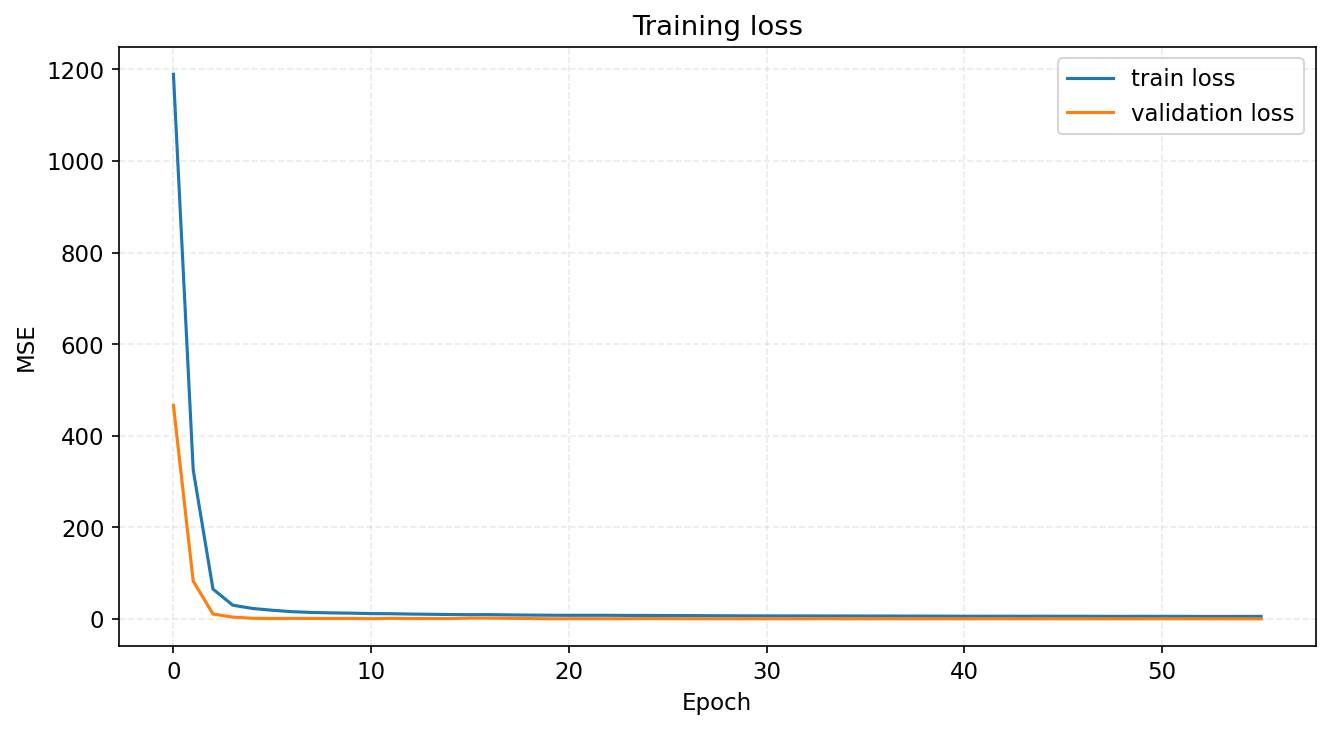

In [13]:
# ============================================================
# PLOT TRAINING LOSS
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["val_loss"], label="validation loss")
ax.set_title("Training loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "training_loss.png", bbox_inches="tight")
plt.show()


In [14]:
# ============================================================
# AVALUACIÓ
# ============================================================

Y_pred = model.predict(X_test_s)

mae_global = mean_absolute_error(Y_test, Y_pred)
rmse_global = np.sqrt(mean_squared_error(Y_test, Y_pred))

print(f"MAE global:  {mae_global:.3f} punts sobre 0–100")
print(f"RMSE global: {rmse_global:.3f} punts sobre 0–100")

rows = []
for j, joint in enumerate(robot_joint_order):
    y_true = Y_test[:, j]
    y_pred = Y_pred[:, j]
    rows.append({
        "joint": joint,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if np.std(y_true) > 0 else np.nan,
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(output_dir / "metrics_by_robot_joint.csv", index=False)
metrics_df.sort_values("MAE", ascending=False)


145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE global:  0.224 punts sobre 0–100
RMSE global: 0.280 punts sobre 0–100


,joint,MAE,RMSE,R2
10,Annular j2,0.402958,0.450206,0.999759
1,Index j1,0.395075,0.460182,0.999874
2,Index j2,0.297962,0.327330,0.999912
9,Annular j1,0.296928,0.356492,0.999854
14,Thumb j2,0.270449,0.301969,0.999877
13,Thumb j1,0.261357,0.322900,0.999926
15,Thumb j3,0.218034,0.254946,0.999932
8,Annular j0,0.213068,0.248393,0.997224
4,Middle j0,0.205985,0.233175,0.984201
6,Middle j2,0.192676,0.244696,0.999961


In [15]:
# ============================================================
# REPRESENTACIÓ COMPRIMIDA DEL BOTTLENECK
# ============================================================

if use_bottleneck:
    bottleneck_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer("bottleneck_layer").output,
    )

    Z_train = bottleneck_model.predict(
        X_train_s,
        verbose=0,
    )

    Z_test = bottleneck_model.predict(
        X_test_s,
        verbose=0,
    )

    print("Bottleneck train:", Z_train.shape)
    print("Bottleneck test:", Z_test.shape)

    bottleneck_columns = [
        f"bottleneck_{i+1}"
        for i in range(Z_test.shape[1])
    ]

    bottleneck_df = meta_test.copy()

    for i, col in enumerate(bottleneck_columns):
        bottleneck_df[col] = Z_test[:, i]

    bottleneck_df.to_csv(
        output_dir / "bottleneck_representation_test_static.csv",
        index=False,
    )

    display(
        bottleneck_df.head()
    )
else:
    print("El model no utilitza bottleneck.")


Bottleneck train: (18498, 6)
Bottleneck test: (4625, 6)


,file,label,position_code,position_name,version,sample_index,t,bottleneck_1,bottleneck_2,bottleneck_3,bottleneck_4,bottleneck_5,bottleneck_6
0,A_OneStat2.yaml,OneStat2,OneStat,One,2,8,0.018686,12.805449,-14.727067,-8.313360,-10.001437,-17.895554,-14.351681
1,A_BotiStat1.yaml,BotiStat1,BotiStat,Botifarra,1,815,1.906766,8.612885,27.201395,-7.985736,-24.372622,6.955846,-5.698219
2,A_BotiStat1.yaml,BotiStat1,BotiStat,Botifarra,1,369,0.865035,8.601701,27.152908,-7.956285,-24.359816,6.963881,-5.644262
3,A_ThumbUpStat1.yaml,ThumbUpStat1,ThumbUpStat,Thumb Up,1,1229,2.867651,20.580114,-4.828813,2.485610,33.223873,-11.027669,-1.299739
4,A_RockStat1.yaml,RockStat1,RockStat,Rock,1,71,0.165486,7.968440,-13.479278,13.420521,10.296382,-18.308926,-1.018770


In [16]:
# ============================================================
# RESULTATS PER POSICIÓ
# ============================================================

pred_df = meta_test.copy()

for j, joint in enumerate(robot_joint_order):
    pred_df[f"true_{joint}"] = Y_test[:, j]
    pred_df[f"pred_{joint}"] = Y_pred[:, j]
    pred_df[f"error_{joint}"] = Y_pred[:, j] - Y_test[:, j]

position_rows = []

for pos, group in pred_df.groupby("position_code"):
    for joint in robot_joint_order:
        y_true = group[f"true_{joint}"].to_numpy()
        y_pred = group[f"pred_{joint}"].to_numpy()
        position_rows.append({
            "position_code": pos,
            "position_name": static_position_names[pos],
            "joint": joint,
            "true_mean": y_true.mean(),
            "pred_mean": y_pred.mean(),
            "pred_std": y_pred.std(),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        })

position_metrics_df = pd.DataFrame(position_rows)
position_metrics_df.to_csv(output_dir / "metrics_by_position_and_joint.csv", index=False)
position_metrics_df.sort_values(["position_code", "MAE"], ascending=[True, False]).head(30)


,position_code,position_name,joint,true_mean,pred_mean,pred_std,MAE,RMSE
1,BotiStat,Botifarra,Index j1,92.037850,92.850151,0.108281,0.812316,0.819501
10,BotiStat,Botifarra,Annular j2,74.137986,73.637917,0.074191,0.500068,0.505541
14,BotiStat,Botifarra,Thumb j2,36.426572,36.048046,0.036275,0.378529,0.380263
15,BotiStat,Botifarra,Thumb j3,51.338117,50.984264,0.058231,0.353853,0.358612
2,BotiStat,Botifarra,Index j2,78.726786,79.049431,0.080400,0.322647,0.332513
12,BotiStat,Botifarra,Thumb j0,40.992126,40.719551,0.041104,0.272575,0.275657
13,BotiStat,Botifarra,Thumb j1,98.627074,98.365303,0.095965,0.261765,0.278801
4,BotiStat,Botifarra,Middle j0,54.748358,54.556480,0.066477,0.191881,0.203070
9,BotiStat,Botifarra,Annular j1,92.182784,91.999451,0.091812,0.183338,0.205042
11,BotiStat,Botifarra,Annular j3,10.067434,9.926957,0.015024,0.140477,0.141278


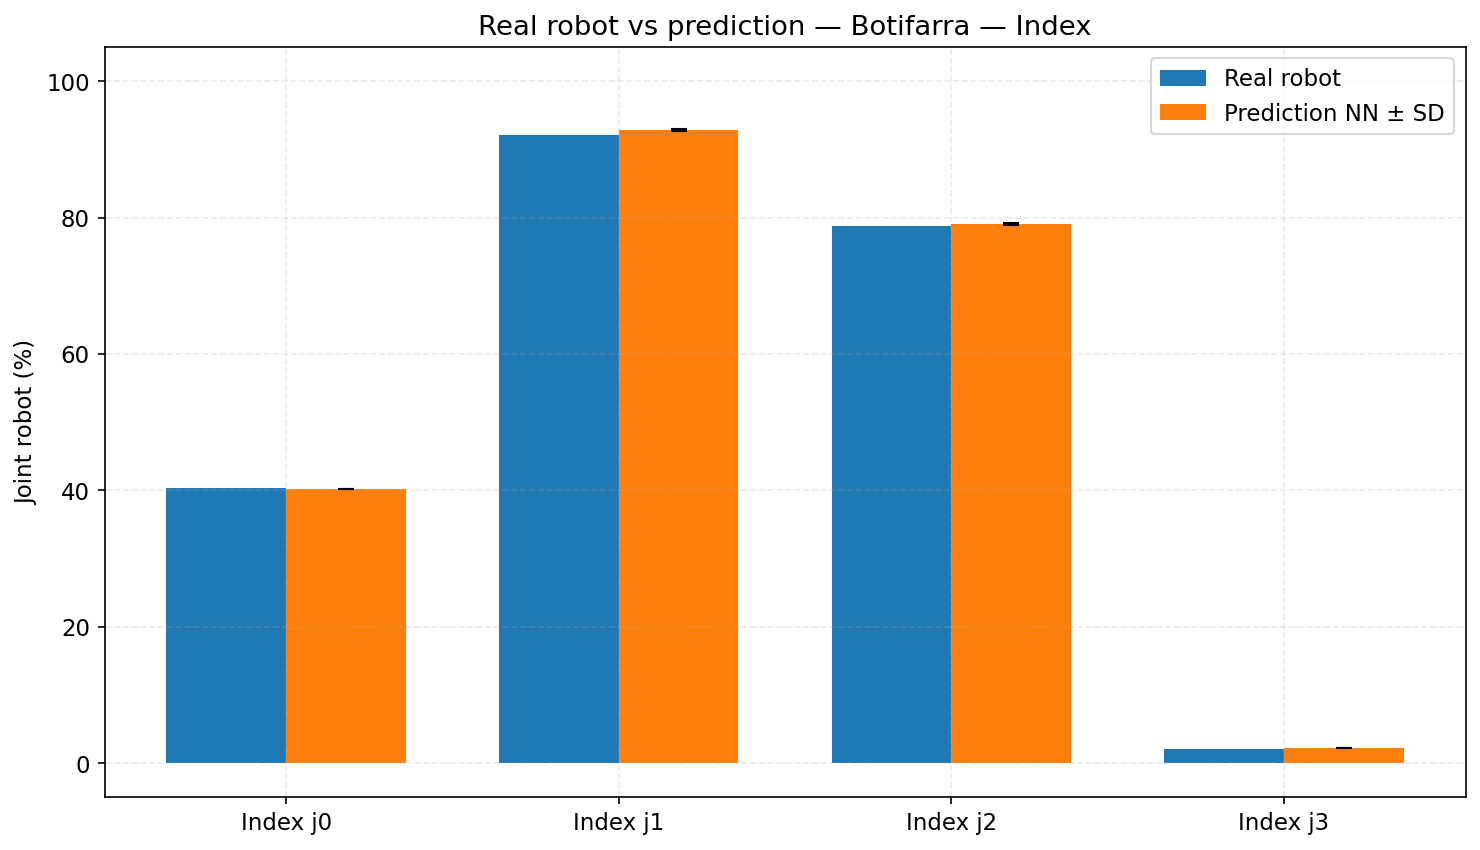

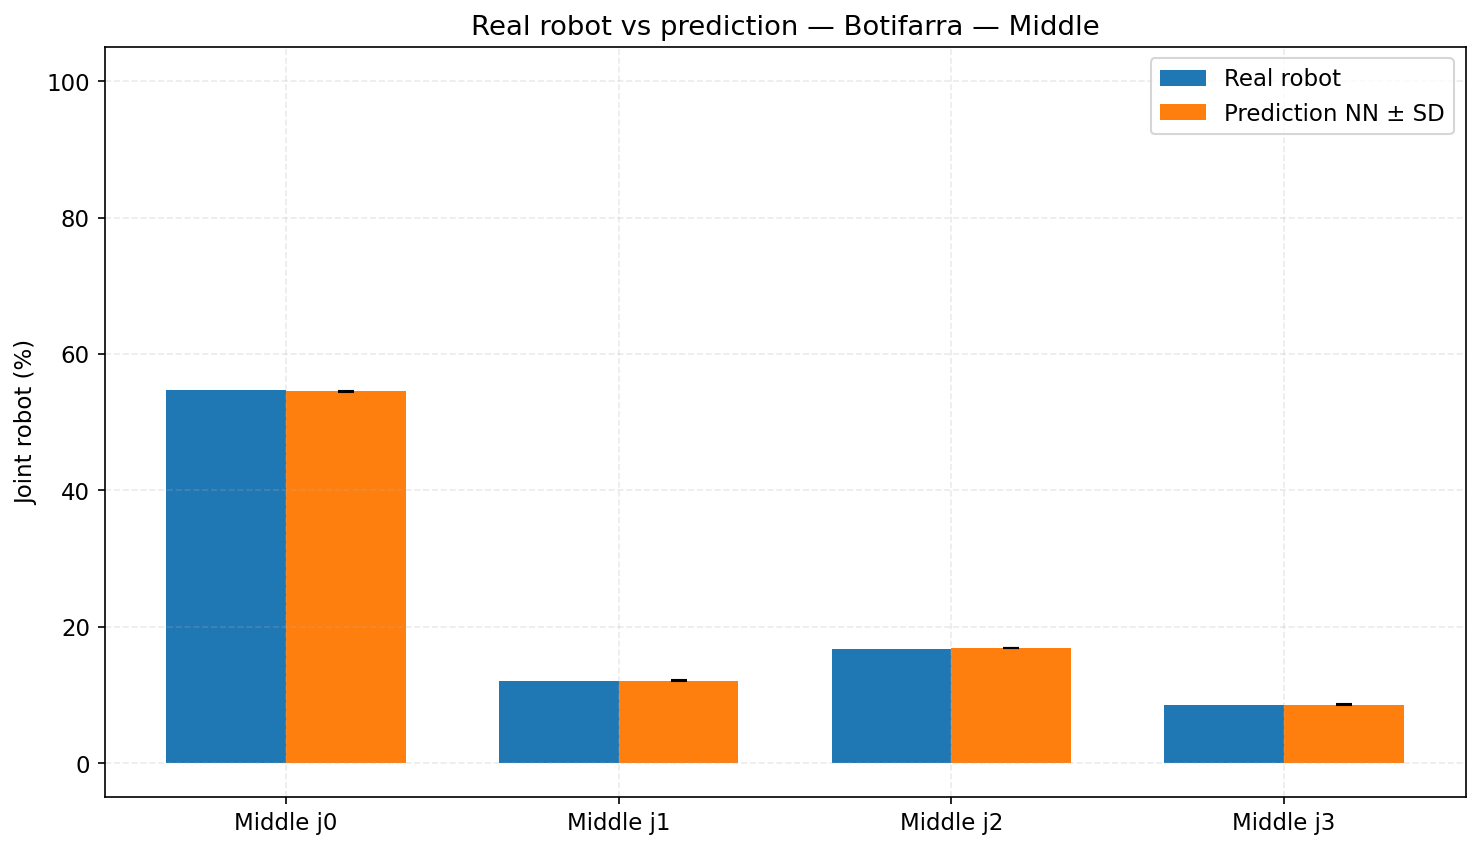

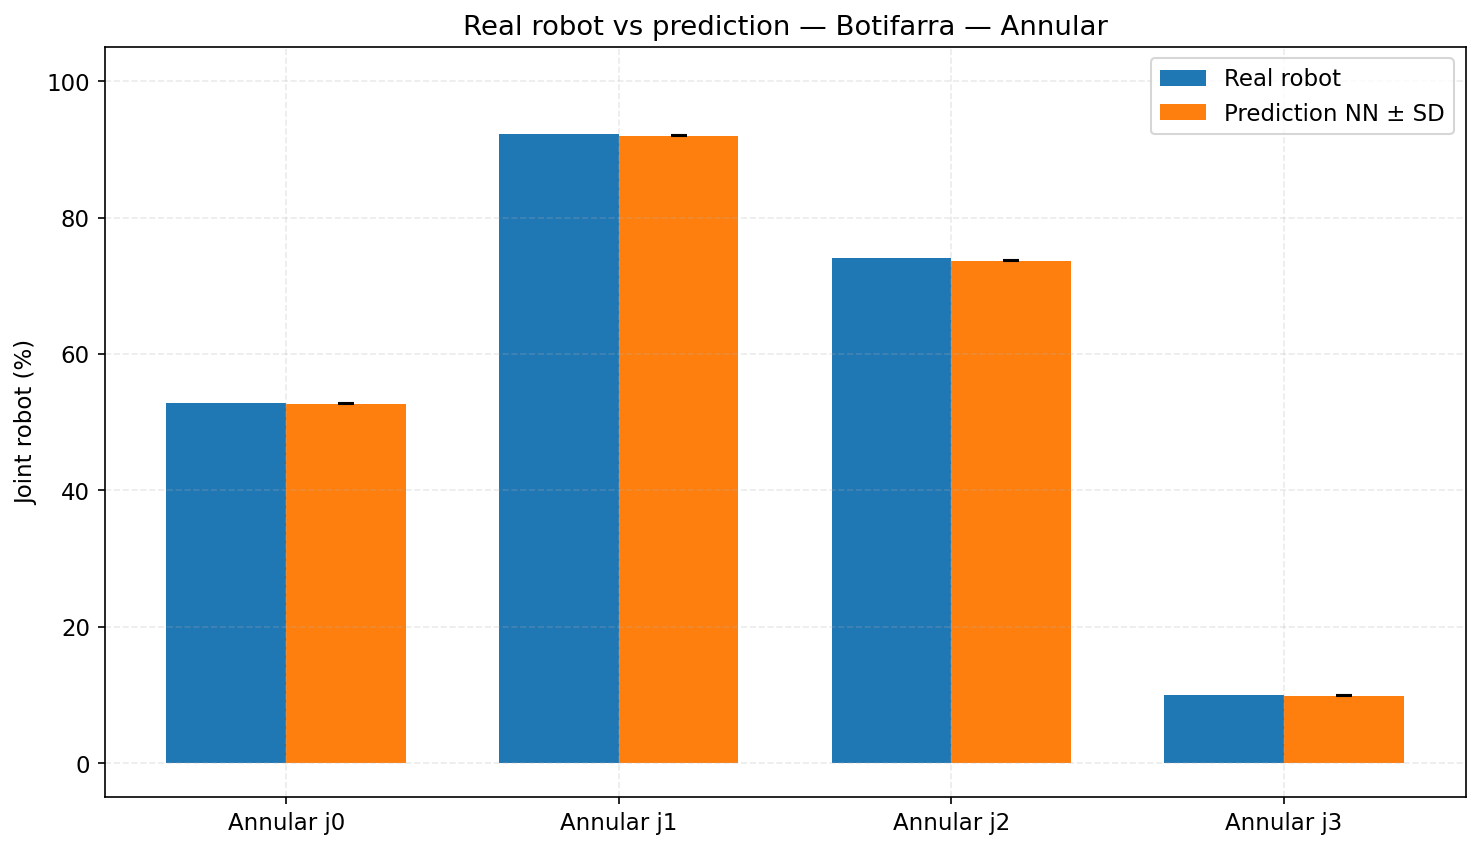

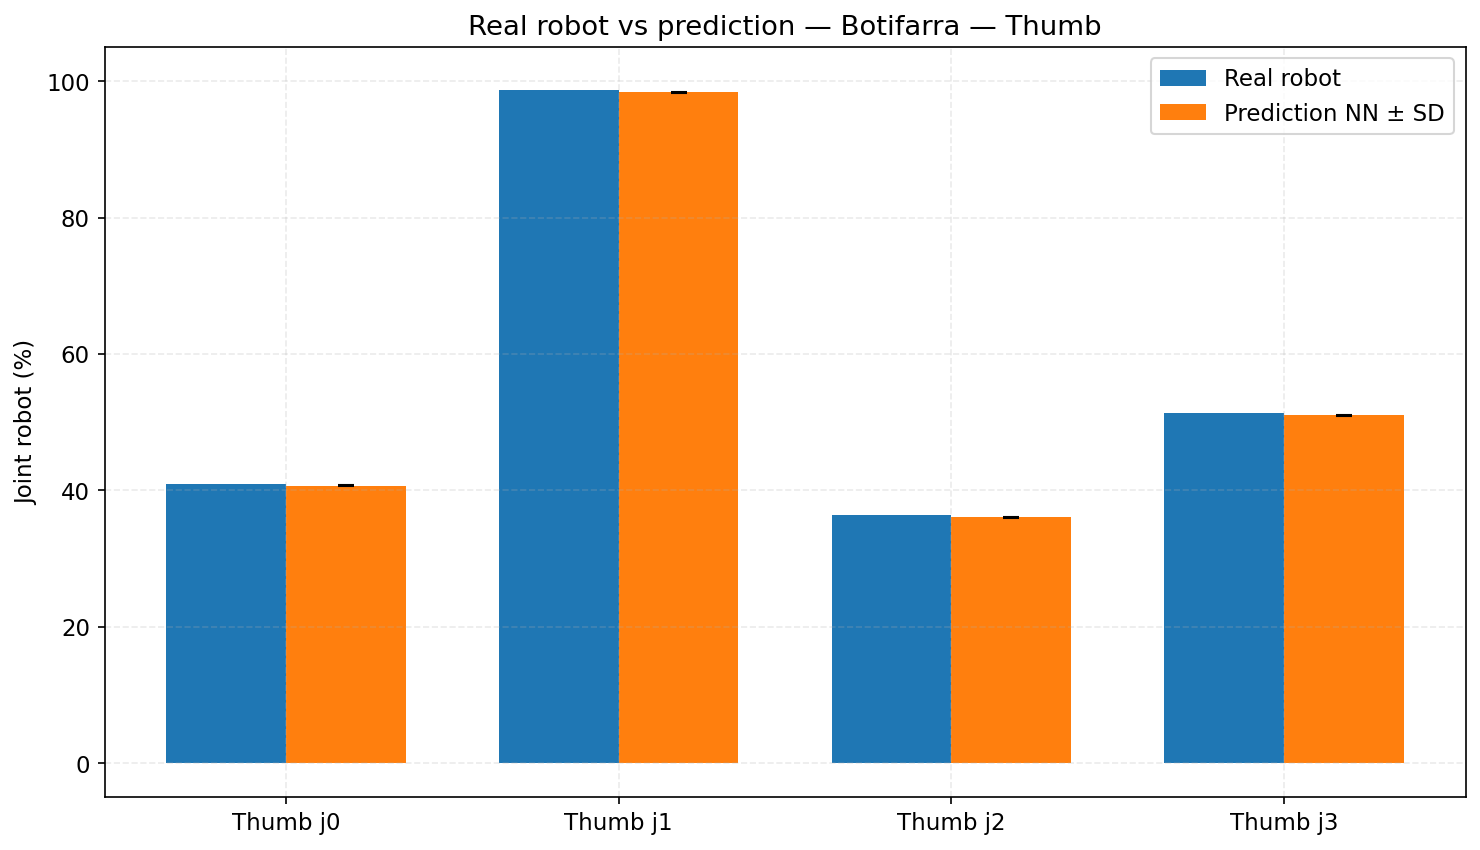

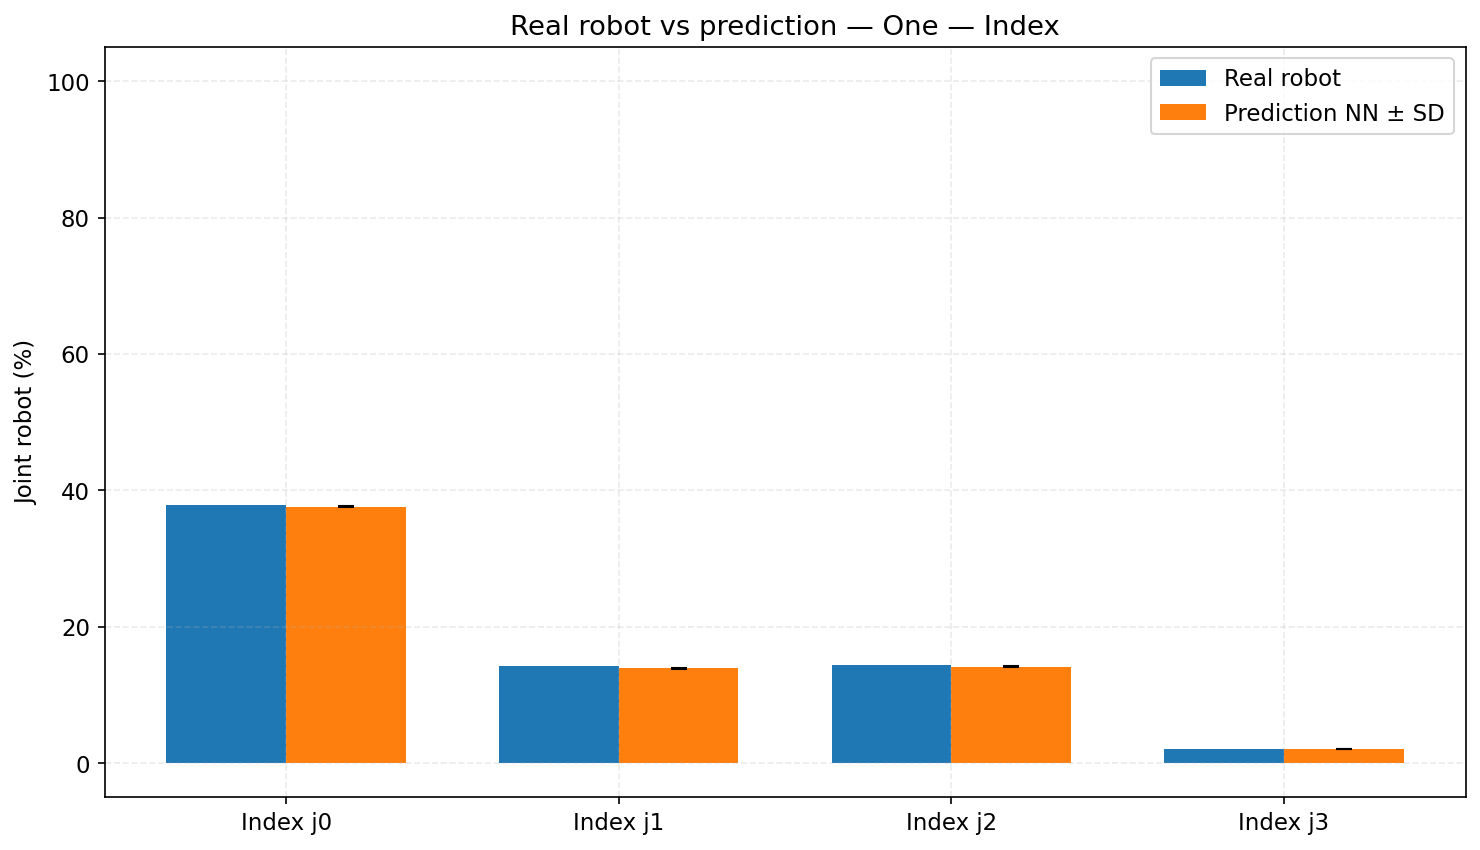

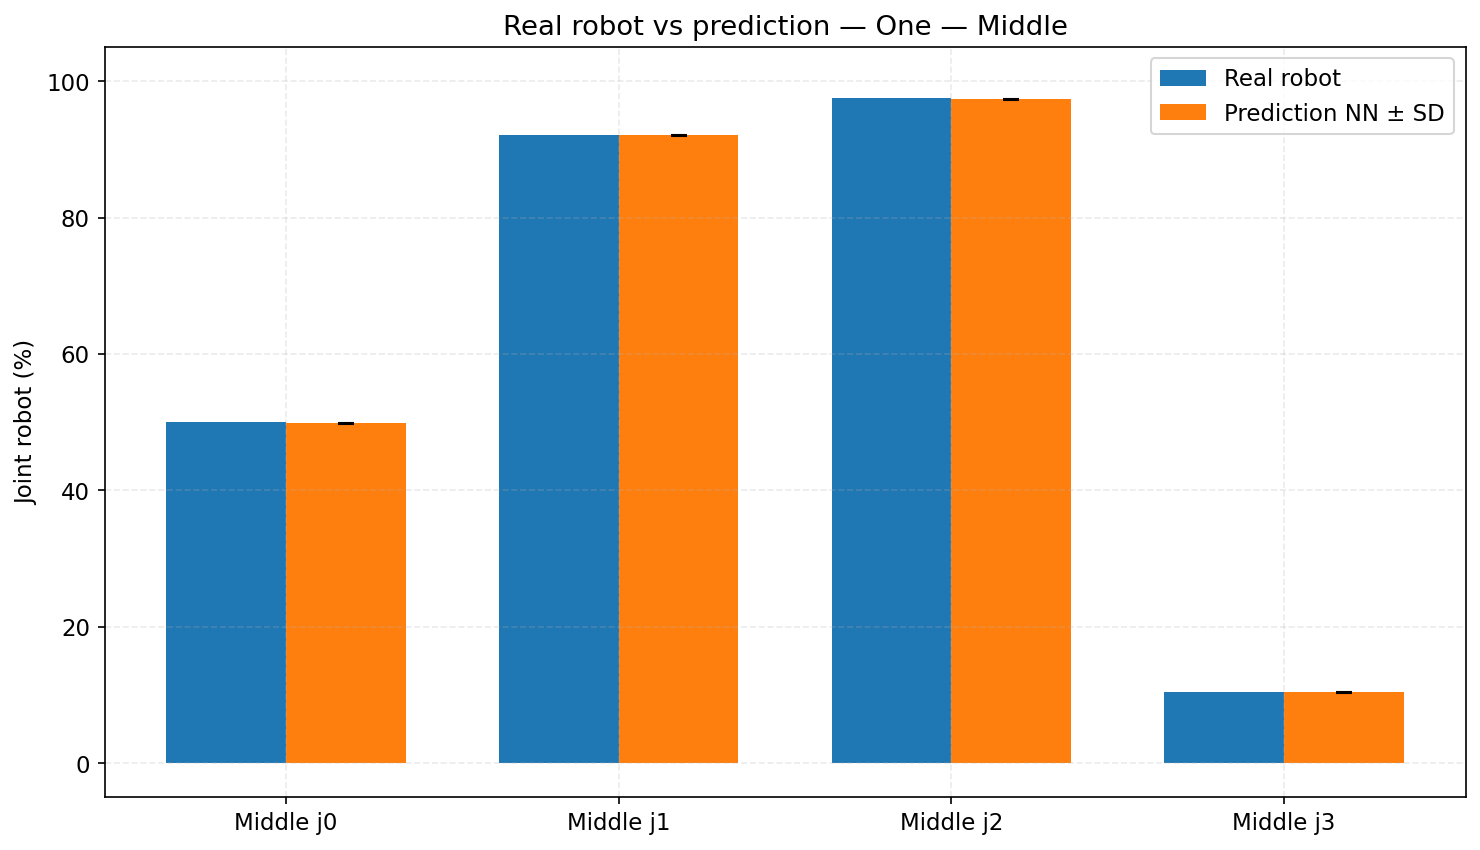

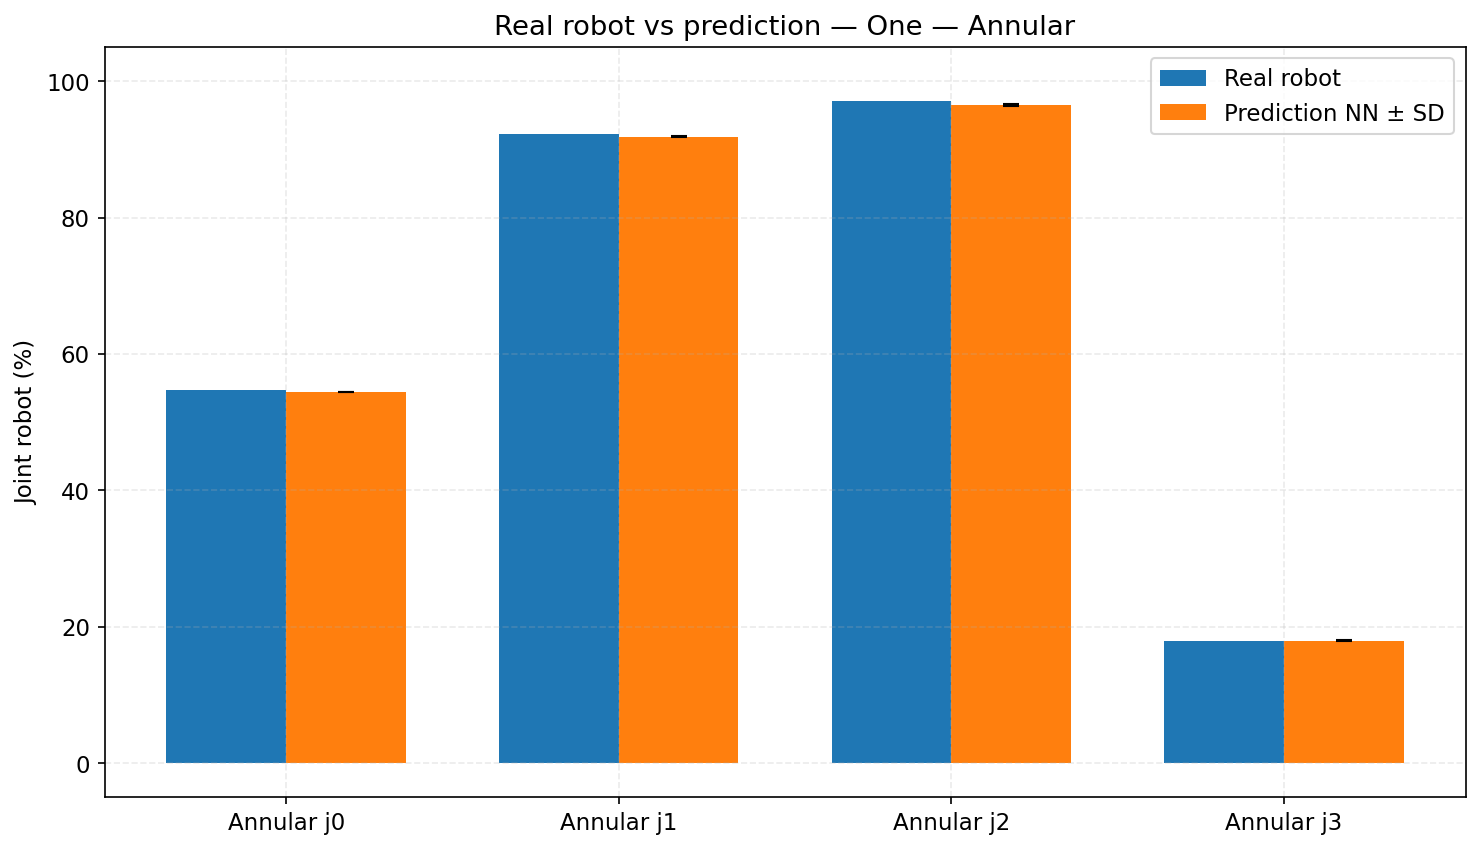

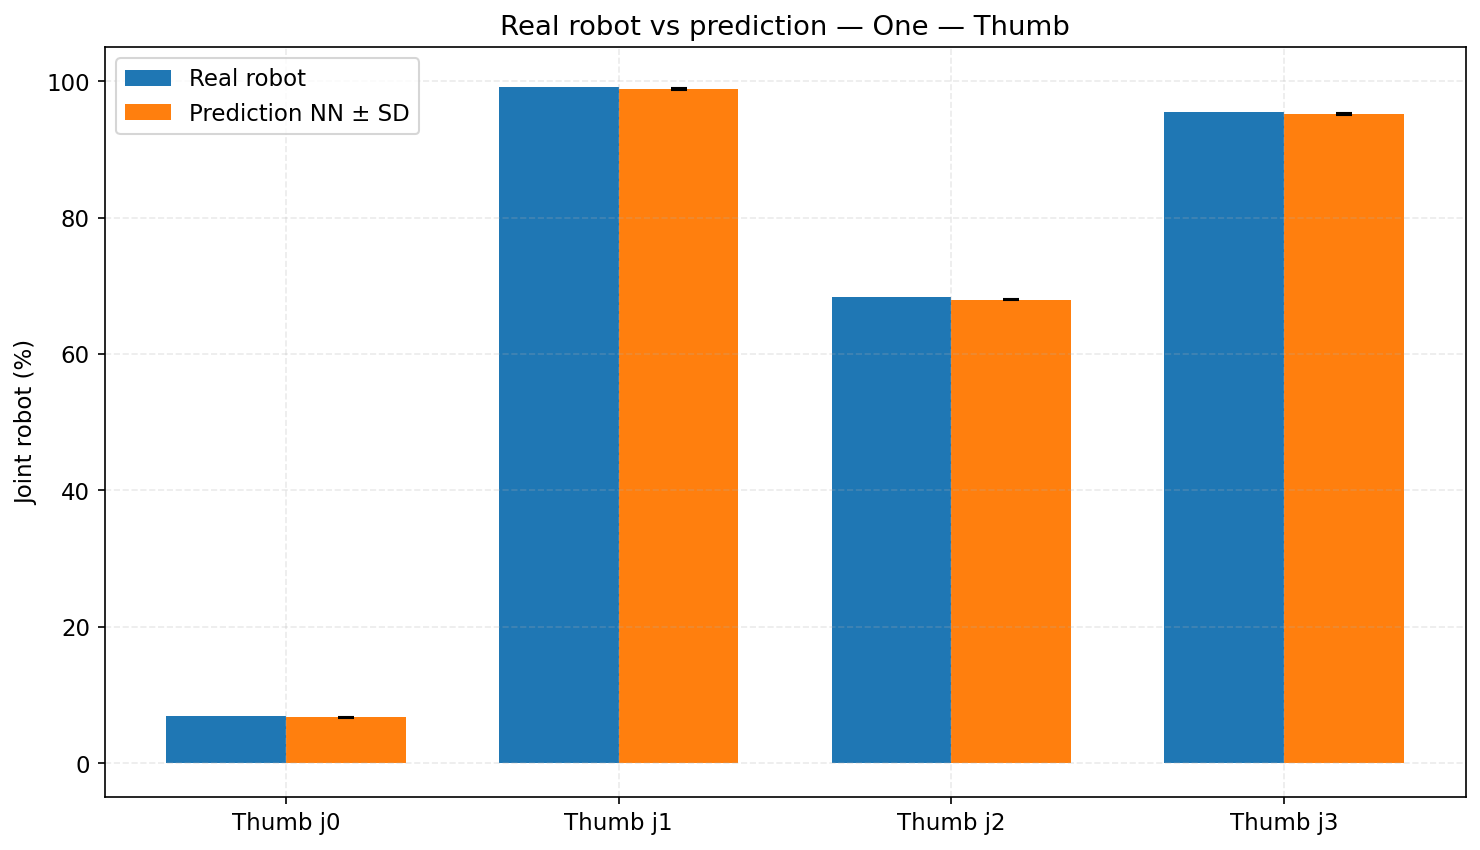

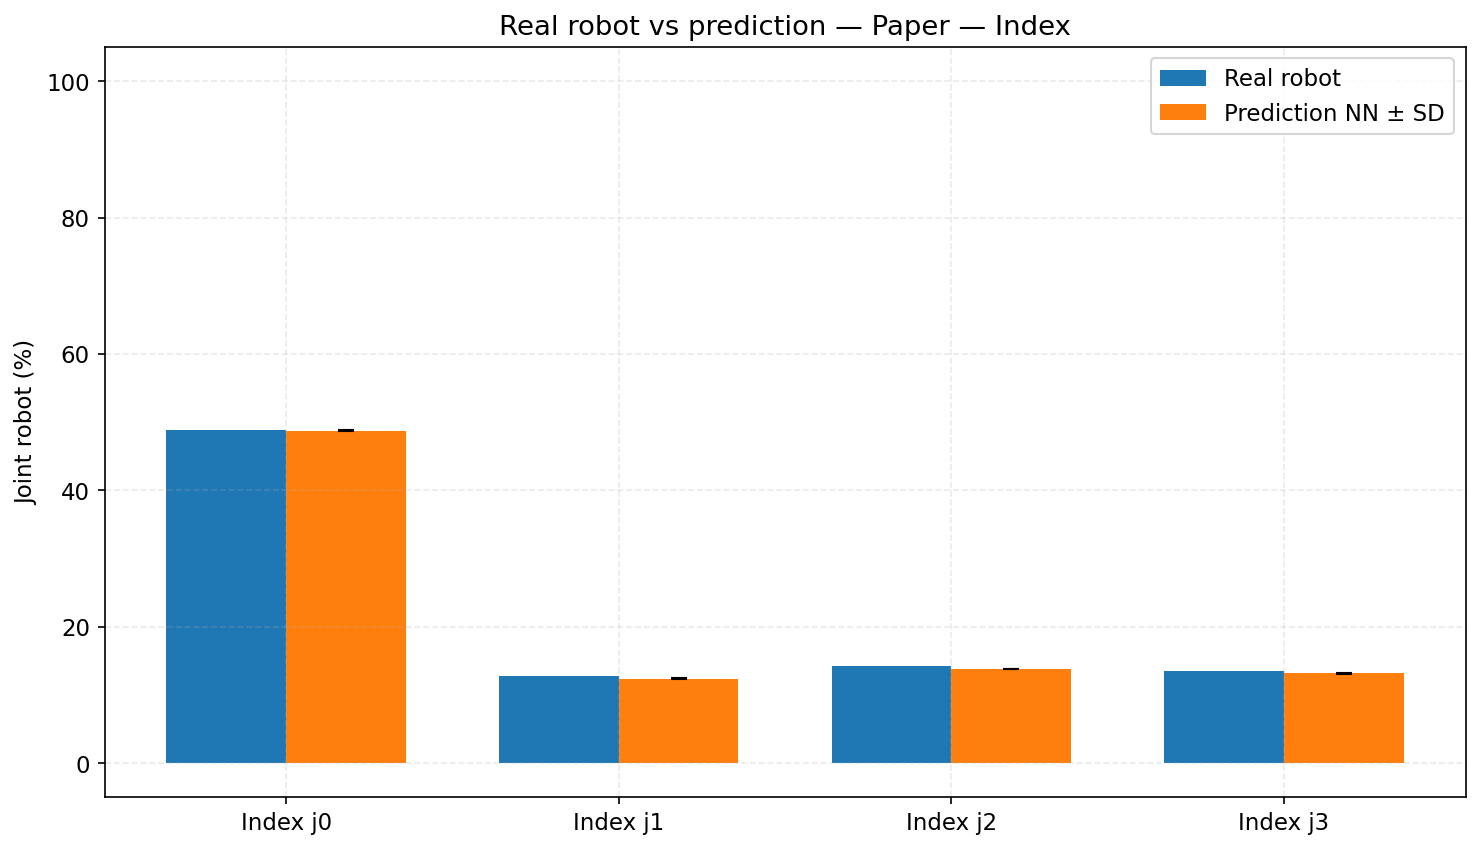

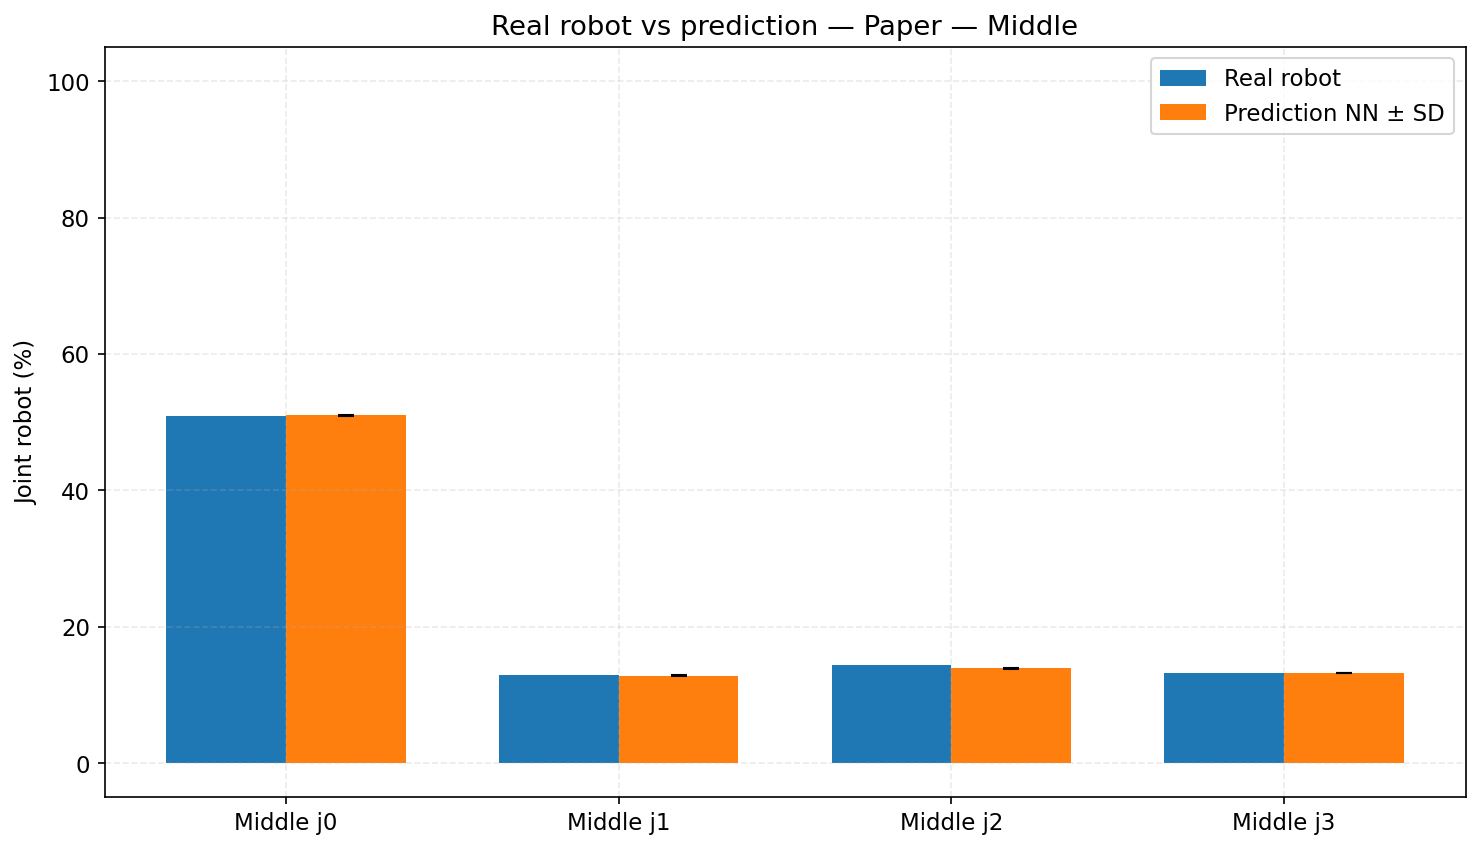

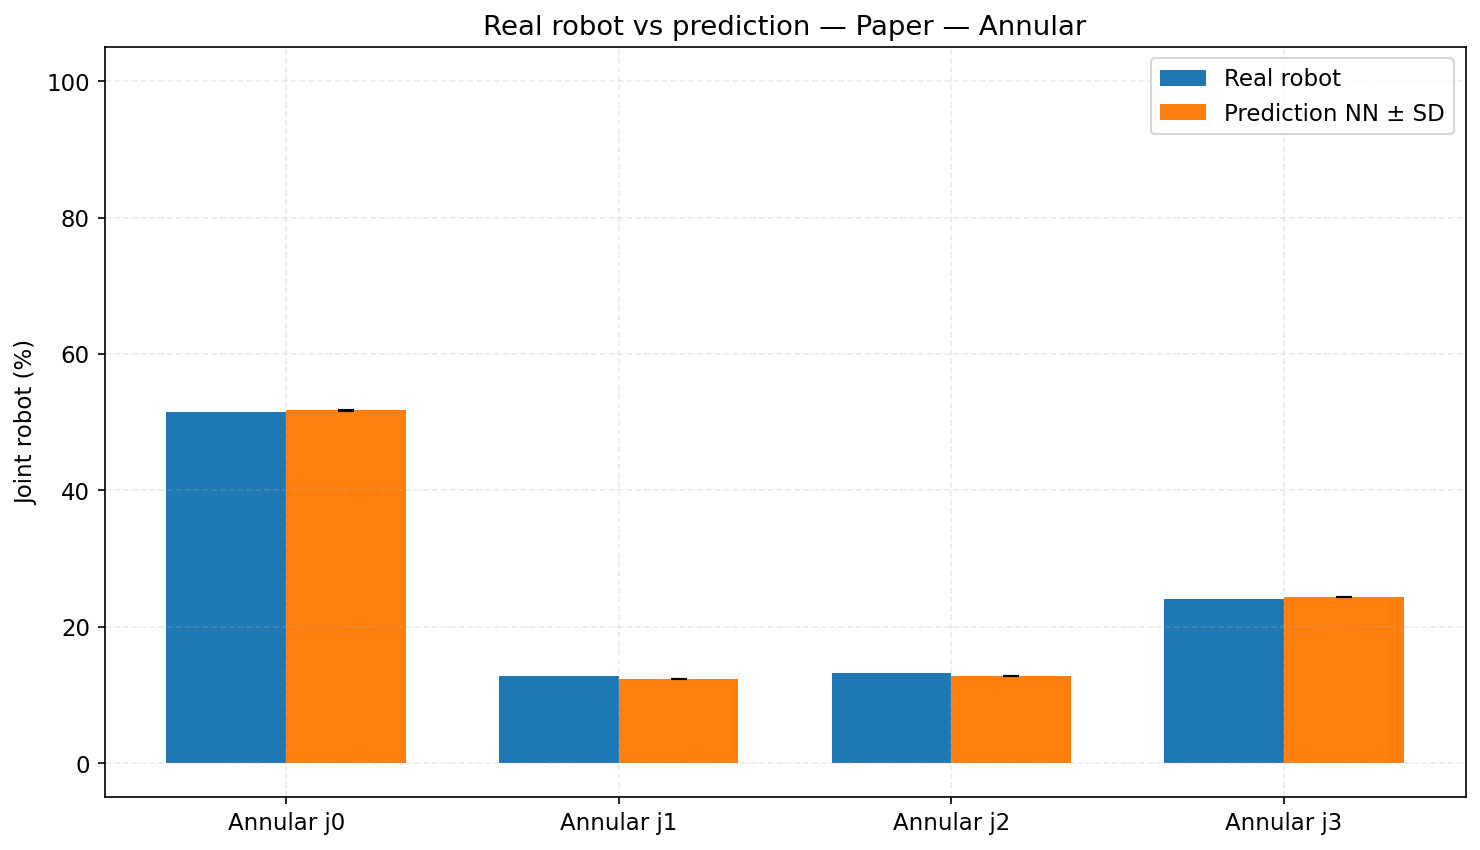

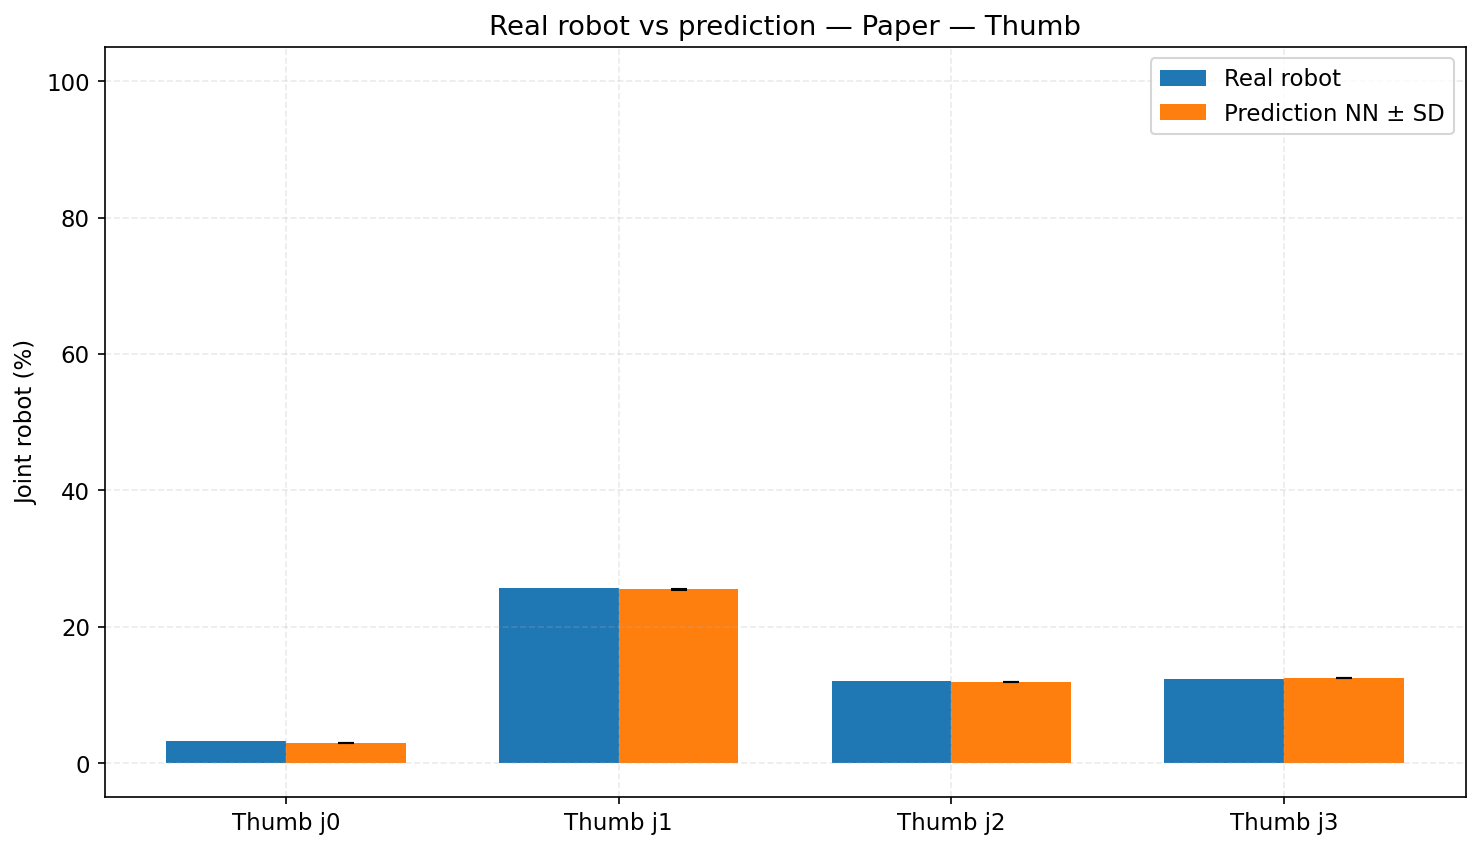

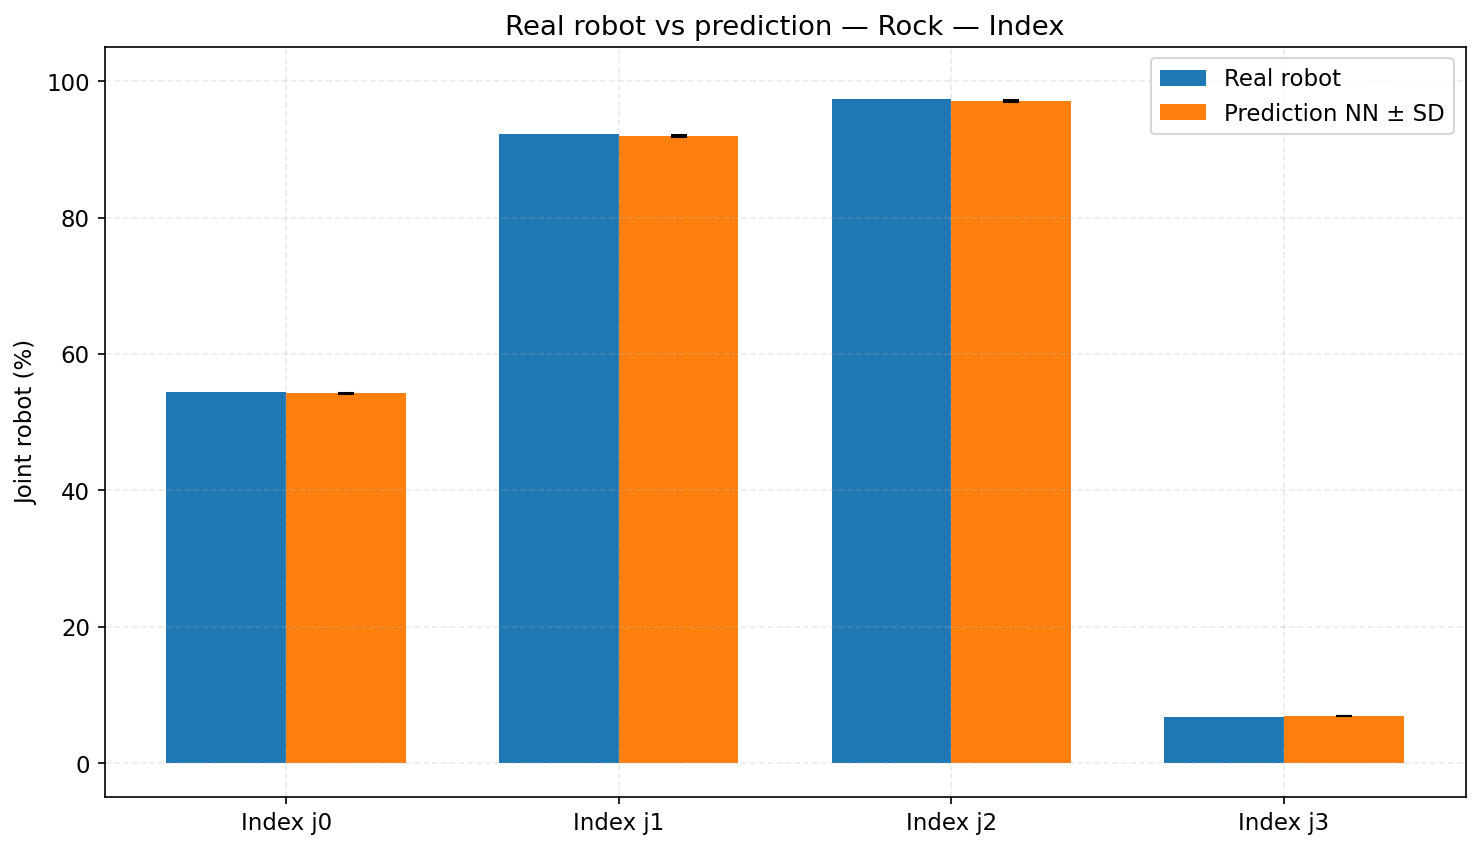

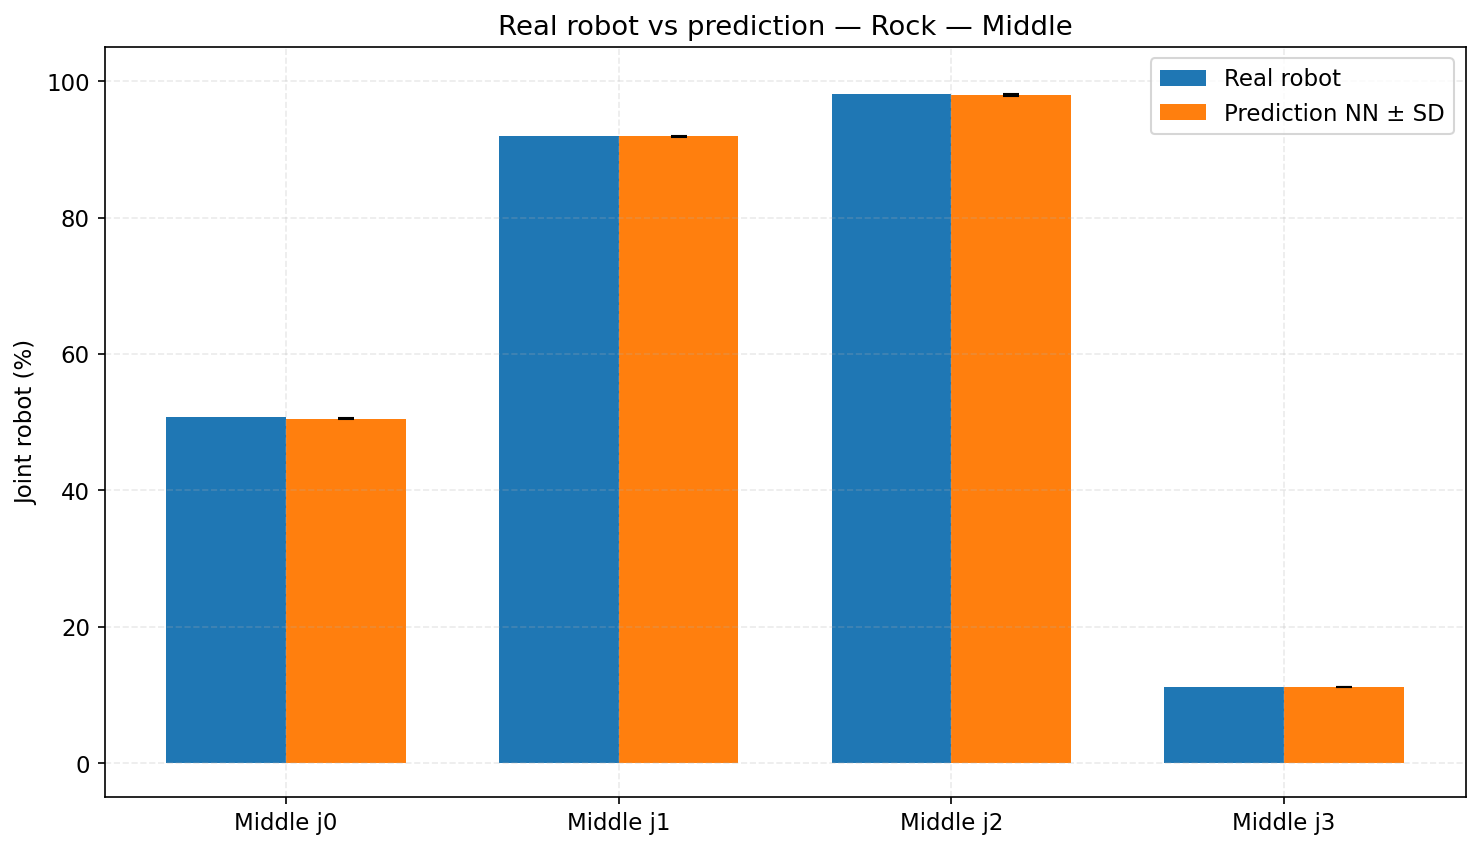

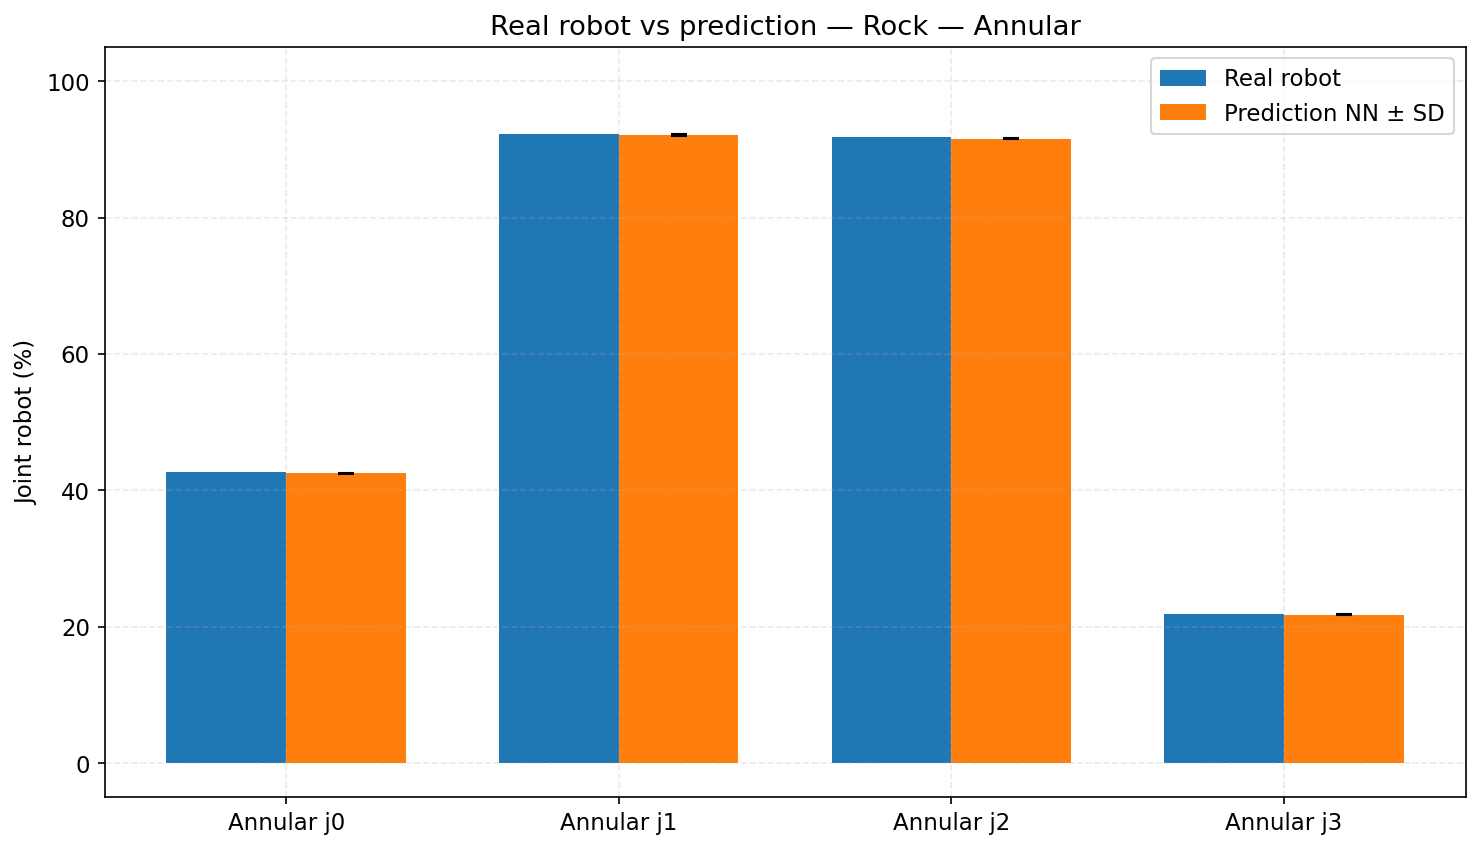

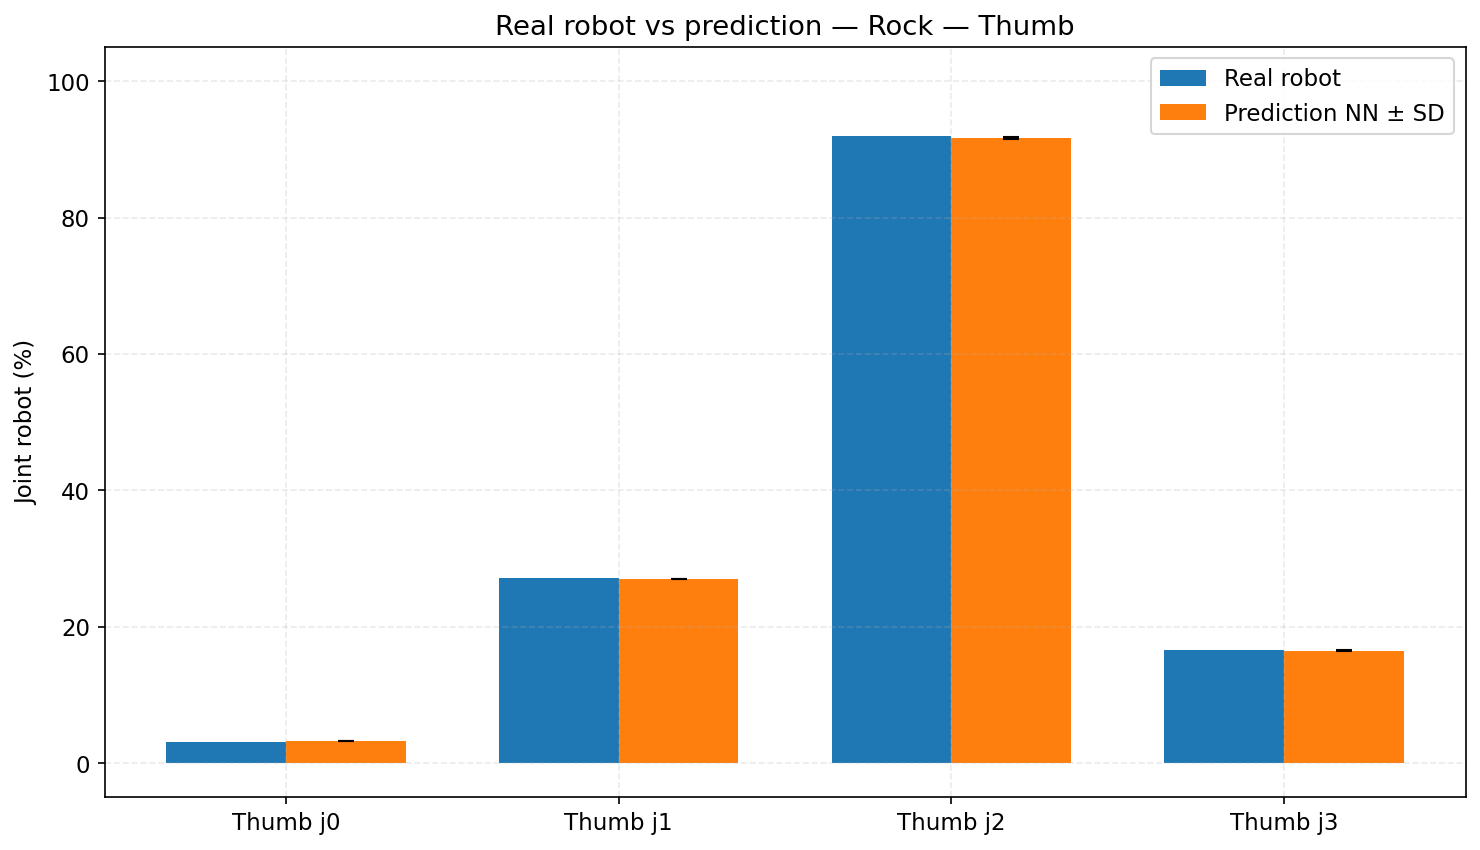

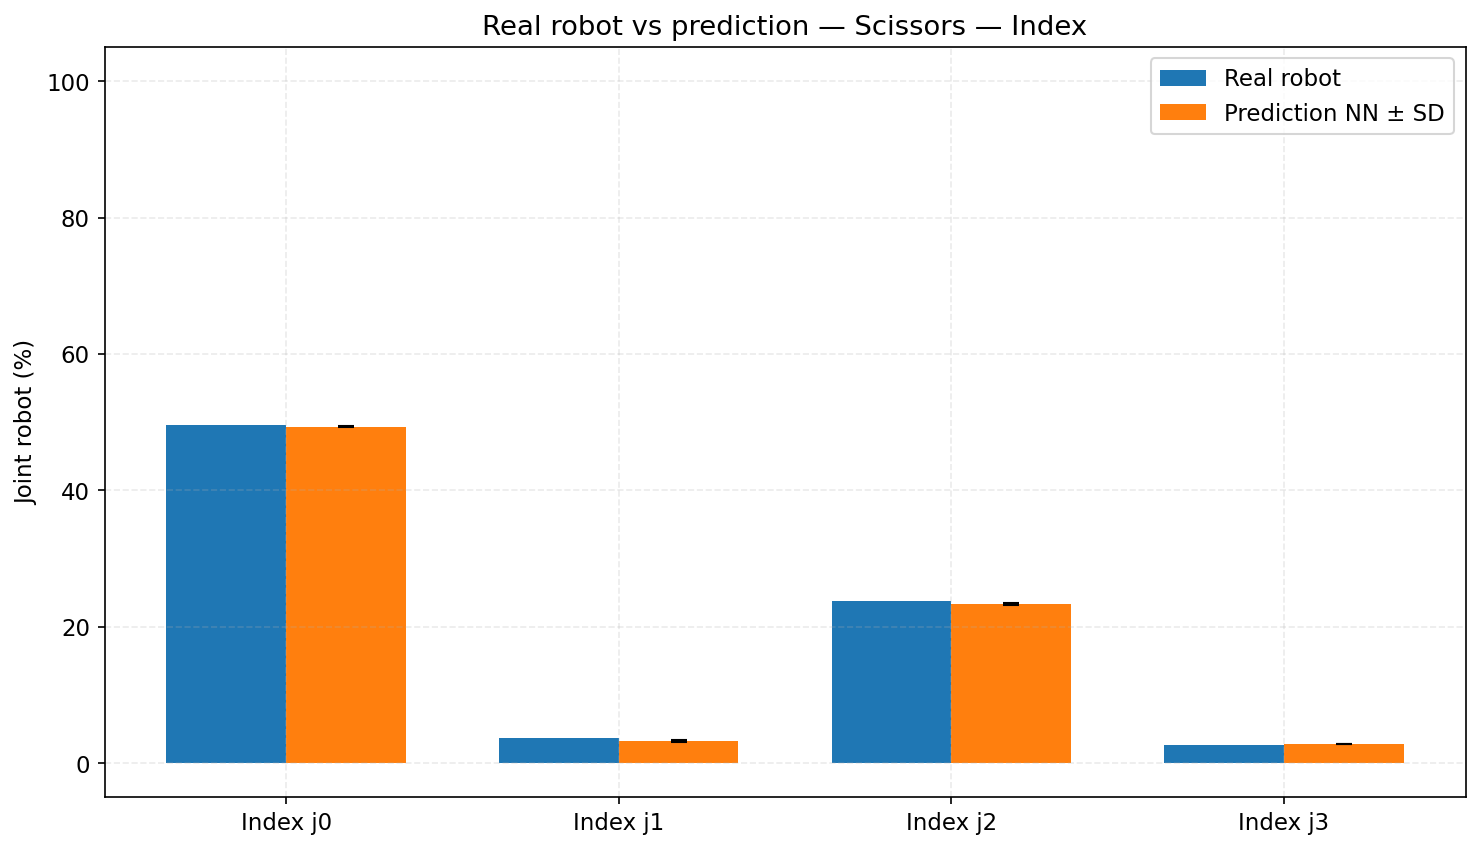

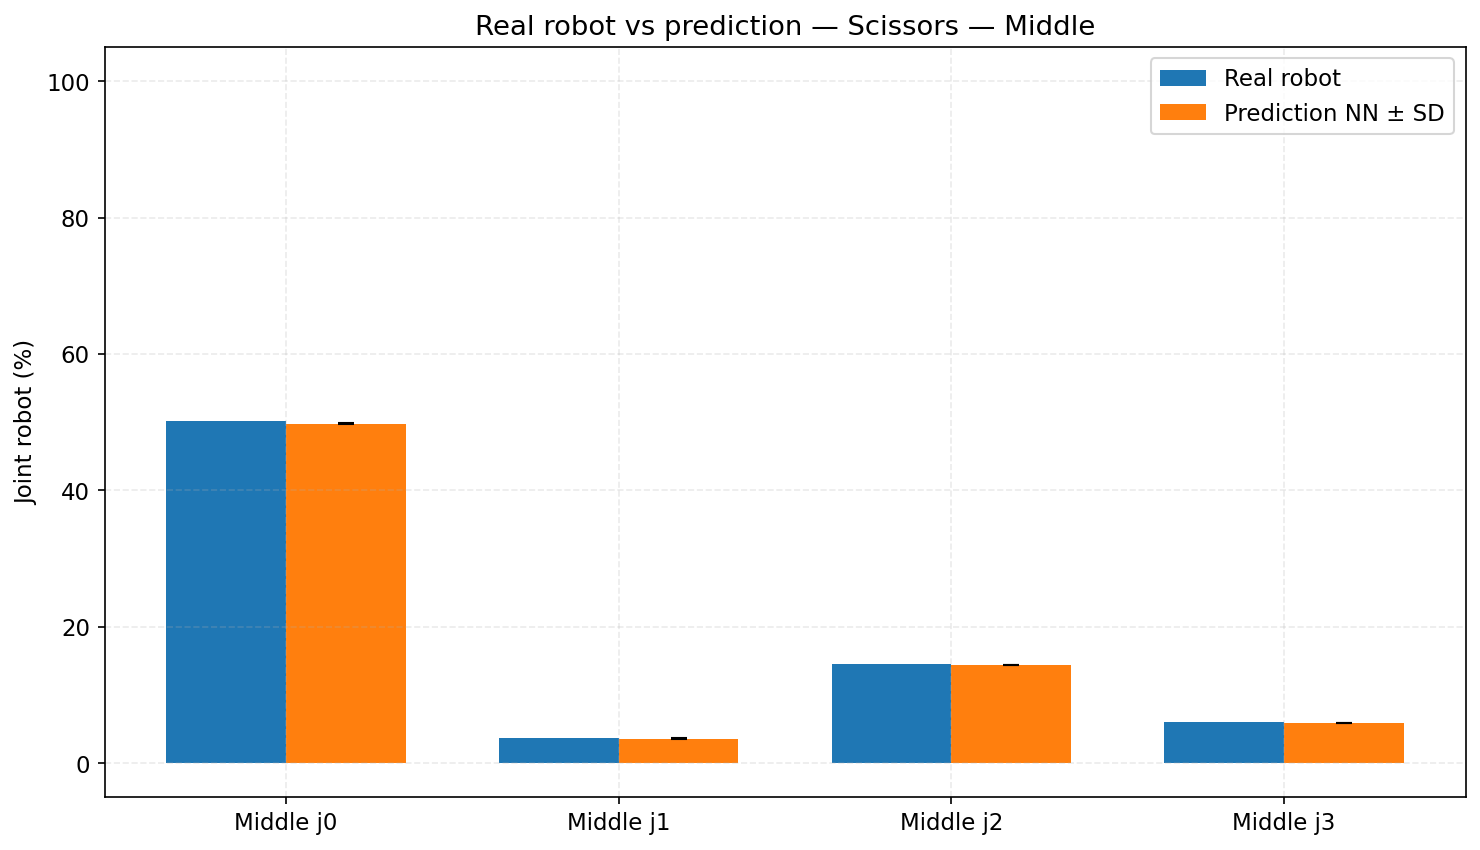

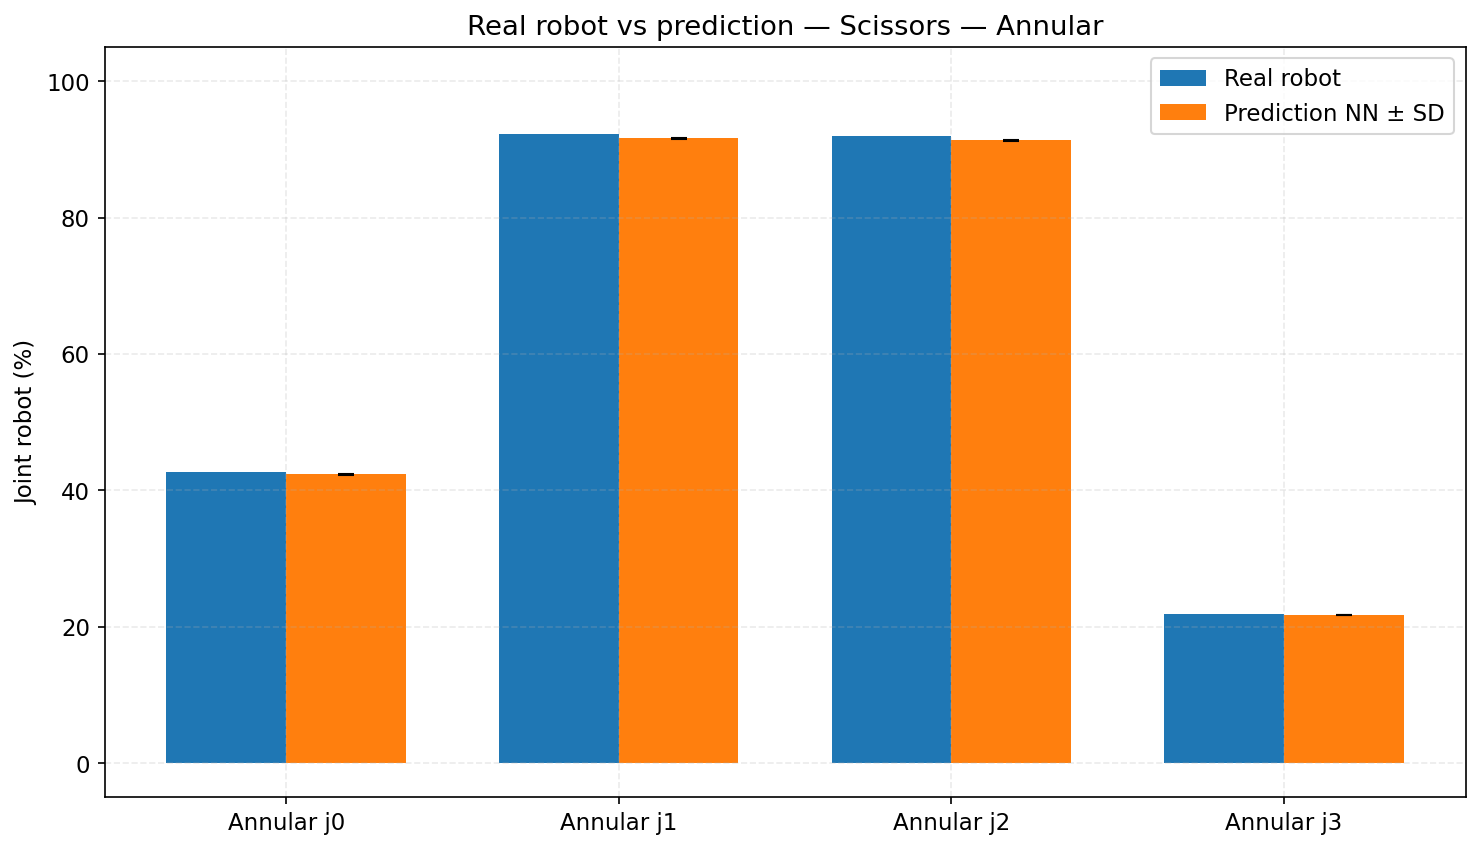

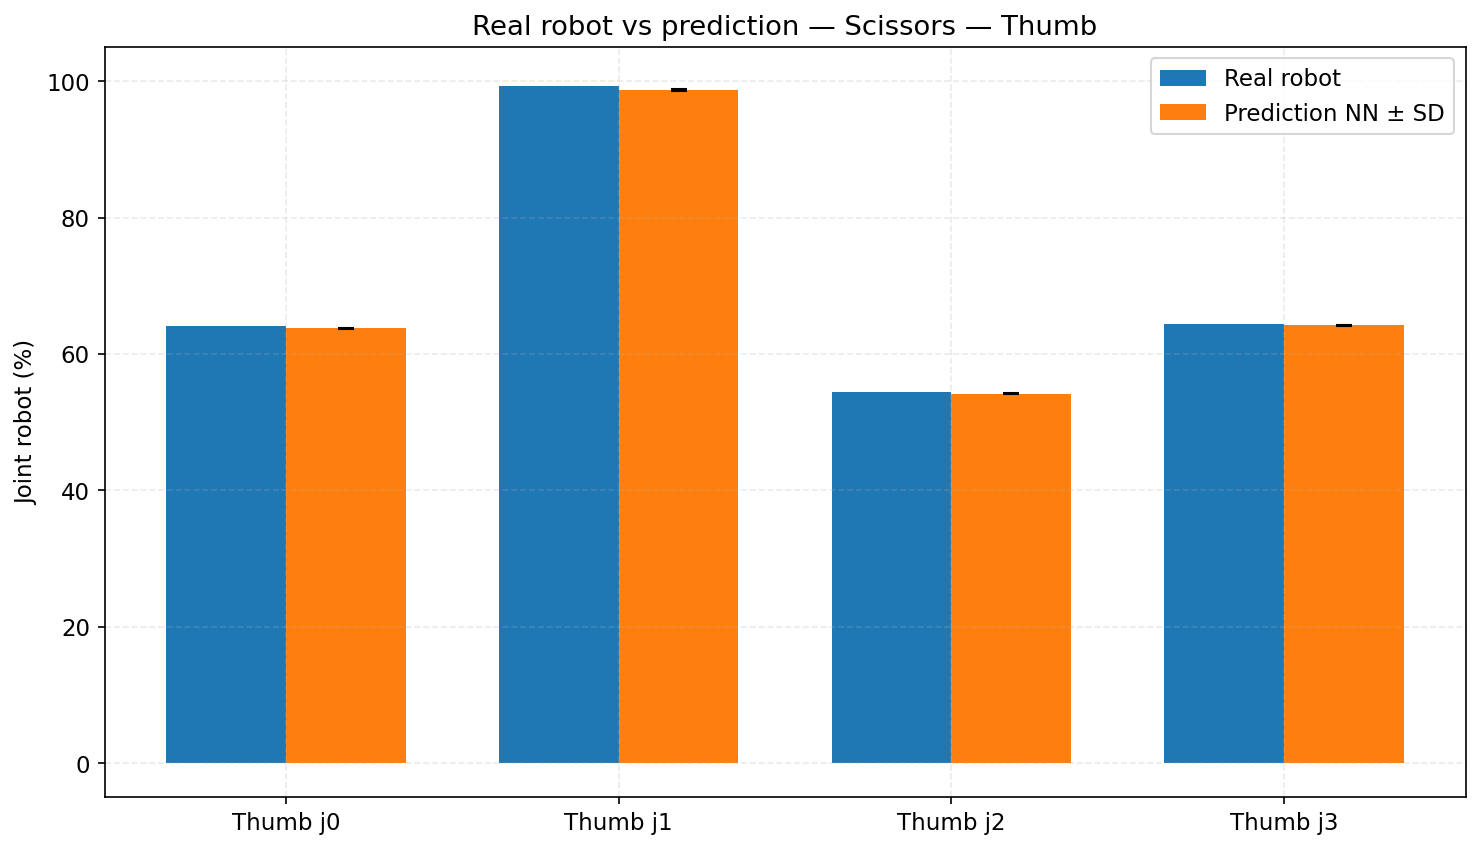

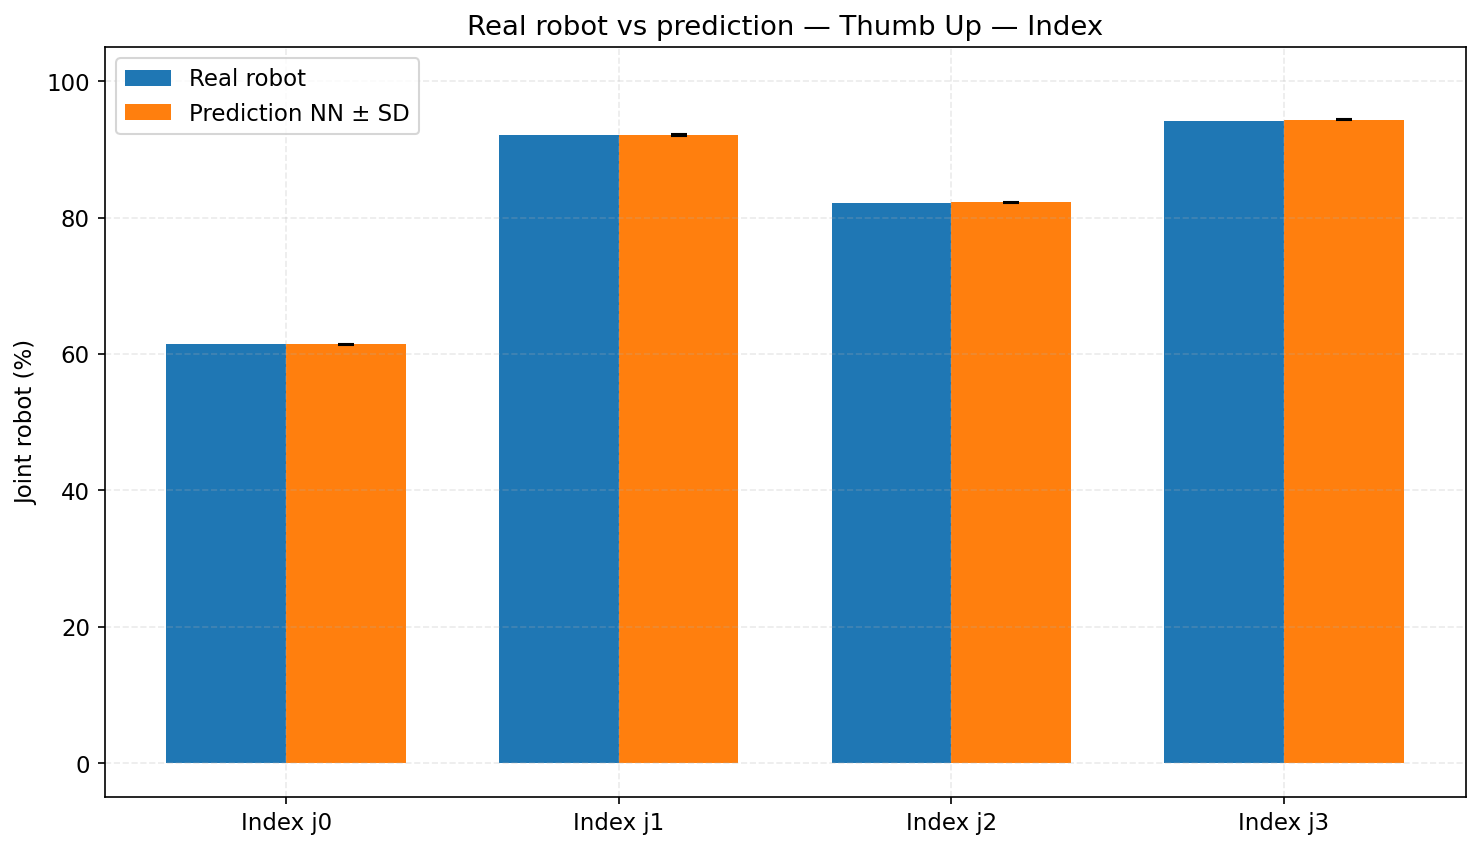

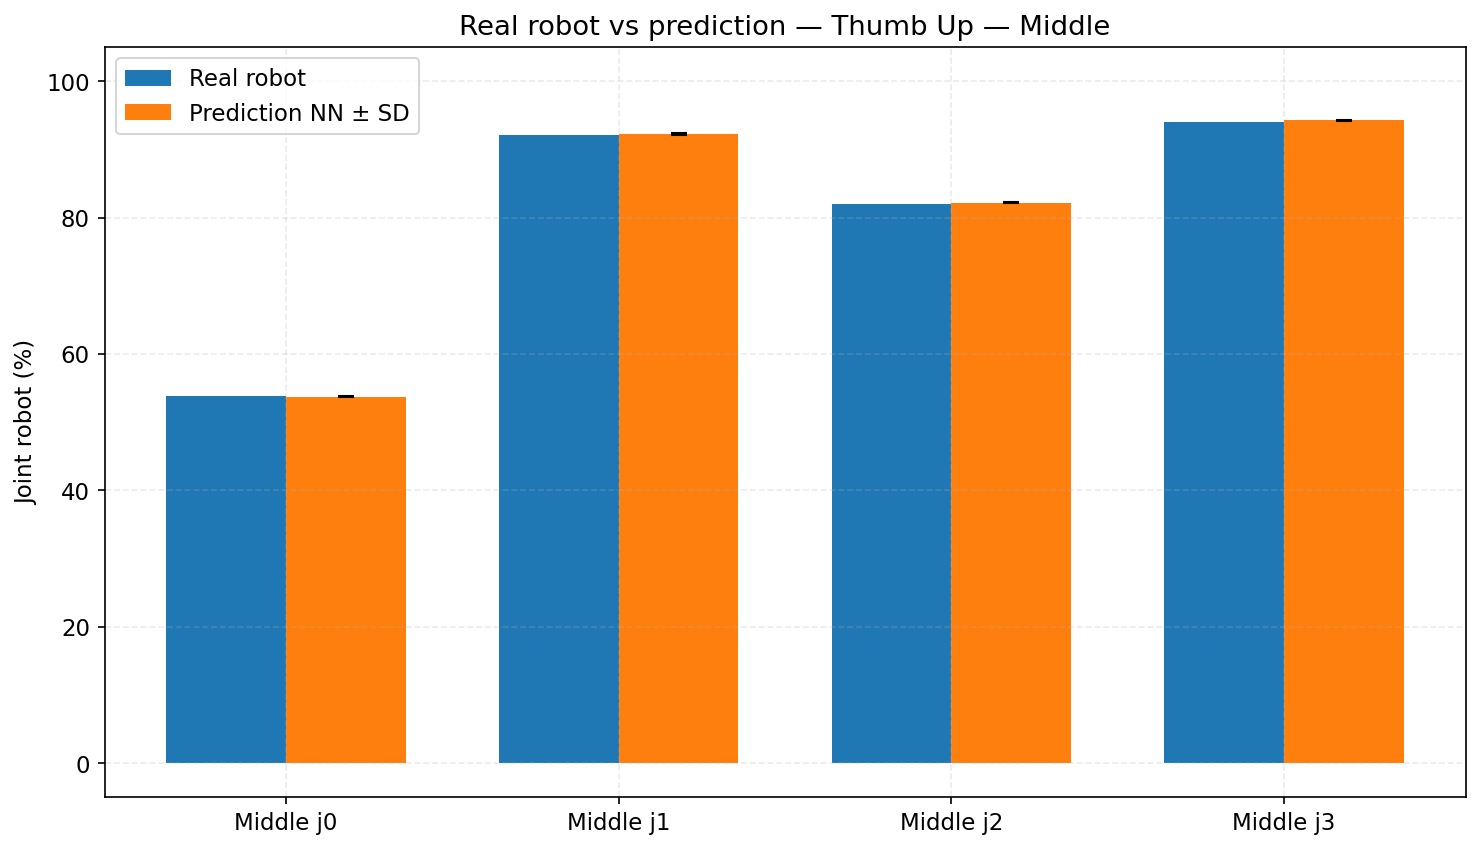

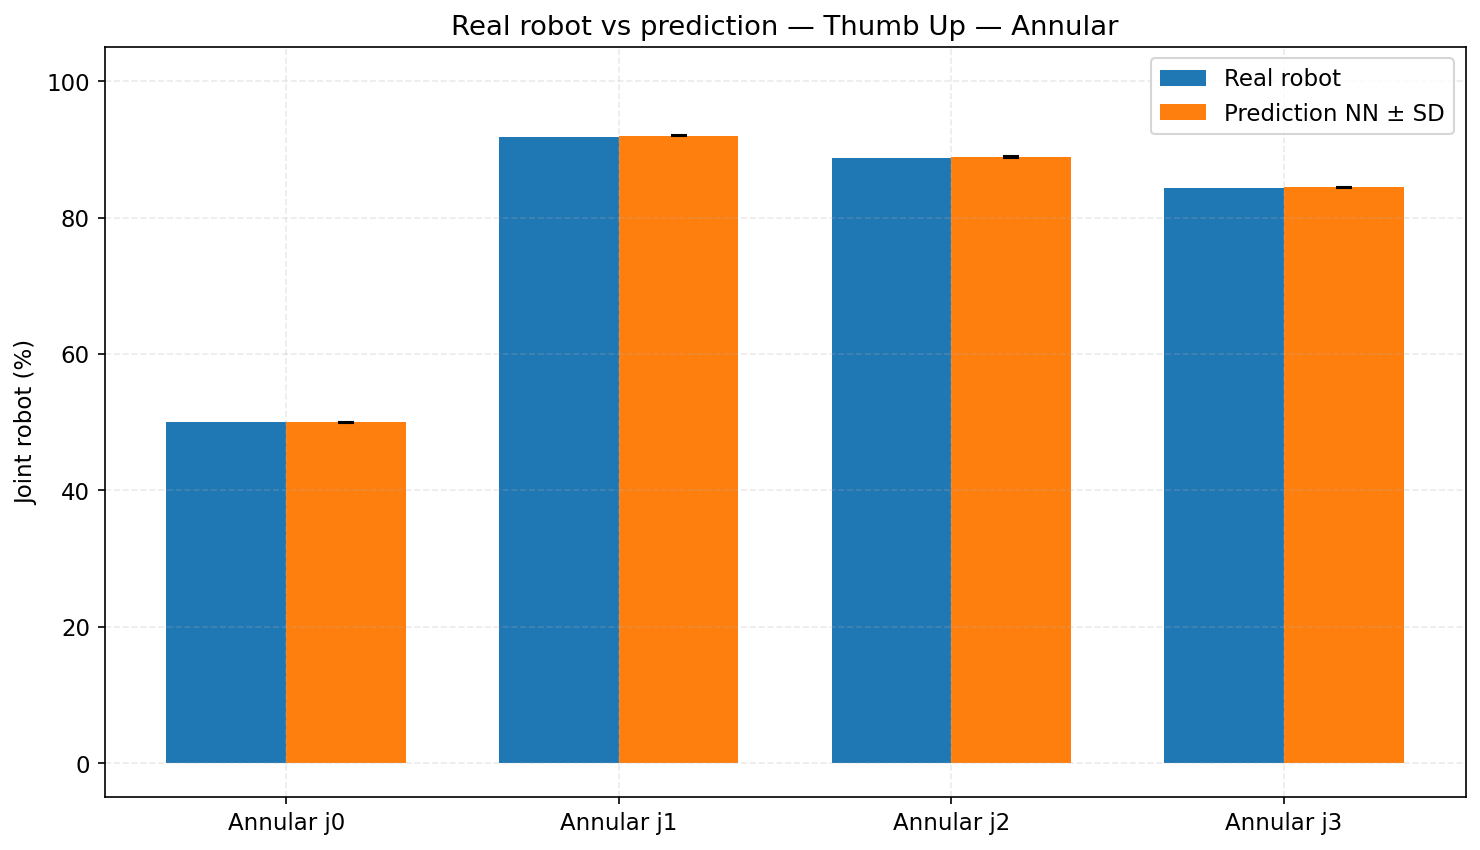

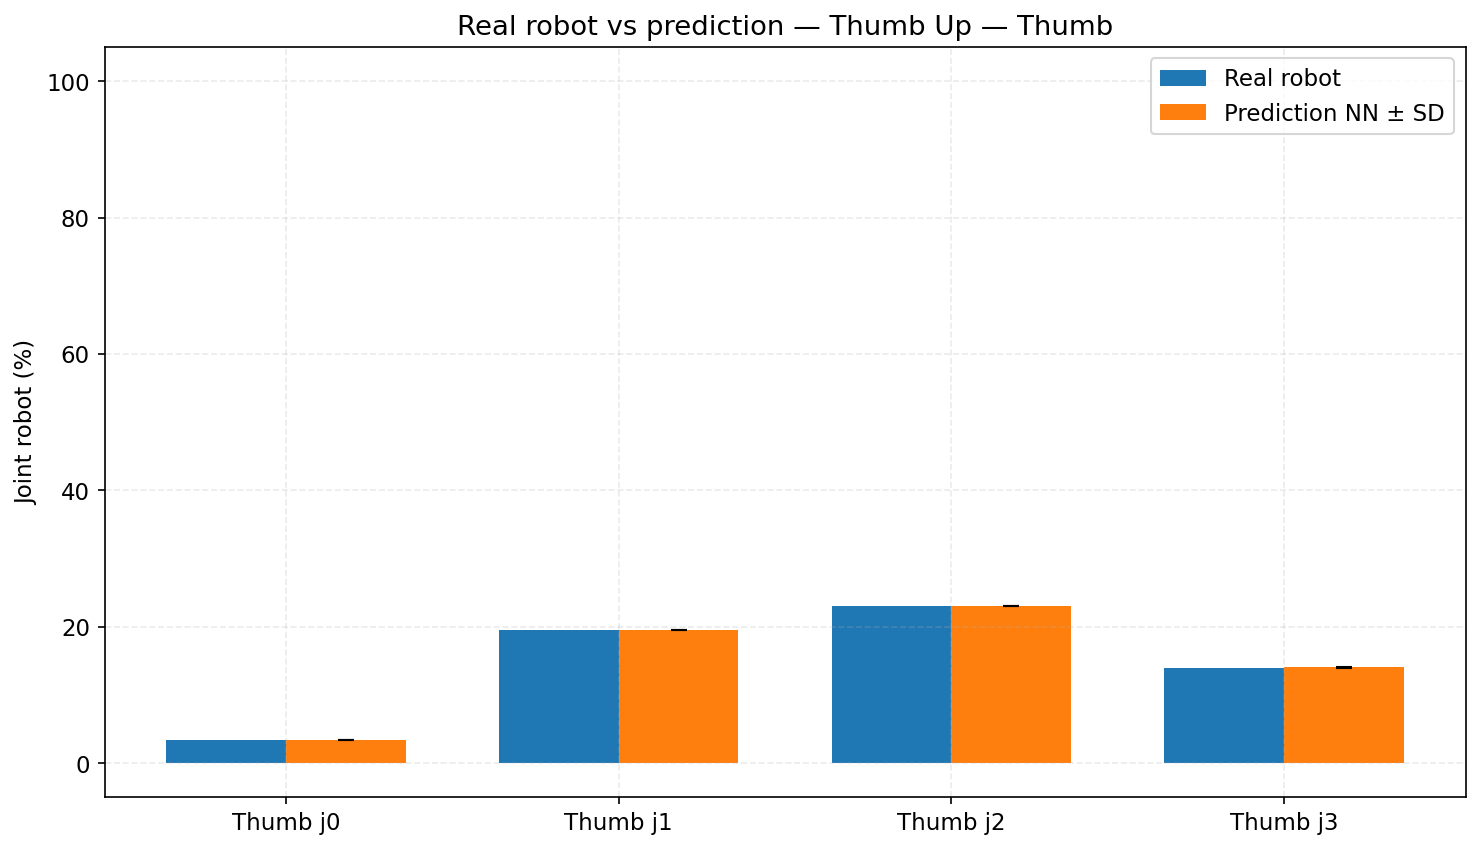

In [18]:
# ============================================================
# PLOTS PER POSICIÓ I DIT
# ============================================================

robot_groups = {
    "Index": ["Index j0", "Index j1", "Index j2", "Index j3"],
    "Middle": ["Middle j0", "Middle j1", "Middle j2", "Middle j3"],
    "Annular": ["Annular j0", "Annular j1", "Annular j2", "Annular j3"],
    "Thumb": ["Thumb j0", "Thumb j1", "Thumb j2", "Thumb j3"],
}

def safe_name(text):
    return (
        text.replace(" ", "_")
        .replace("í", "i")
        .replace("à", "a")
        .replace("è", "e")
        .replace("é", "e")
        .replace("ó", "o")
        .replace("ú", "u")
    )

for pos in sorted(pred_df["position_code"].unique()):
    pos_name = static_position_names[pos]
    pos_folder = output_dir / pos
    pos_folder.mkdir(exist_ok=True)

    subset = position_metrics_df[position_metrics_df["position_code"] == pos].copy()

    for group_name, joints in robot_groups.items():
        s = subset[subset["joint"].isin(joints)].copy()
        s["joint"] = pd.Categorical(s["joint"], categories=joints, ordered=True)
        s = s.sort_values("joint")

        x = np.arange(len(s))
        width = 0.36

        fig, ax = plt.subplots(figsize=(10, 5.8))
        ax.bar(x - width / 2, s["true_mean"], width, label="Real robot")
        ax.bar(x + width / 2, s["pred_mean"], width, yerr=s["pred_std"], capsize=4, label="Prediction NN ± SD")

        ax.set_title(f"Real robot vs prediction — {pos_name} — {group_name}")
        ax.set_xticks(x)
        ax.set_xticklabels(s["joint"])
        ax.set_ylabel("Joint robot (%)")
        ax.set_ylim(-5, 105)
        ax.legend()

        fig.tight_layout()
        fig.savefig(pos_folder / f"{pos}_{safe_name(group_name)}_real_vs_pred.png", bbox_inches="tight")
        plt.show()


Generant resum tots els joints: BotiStat — Botifarra


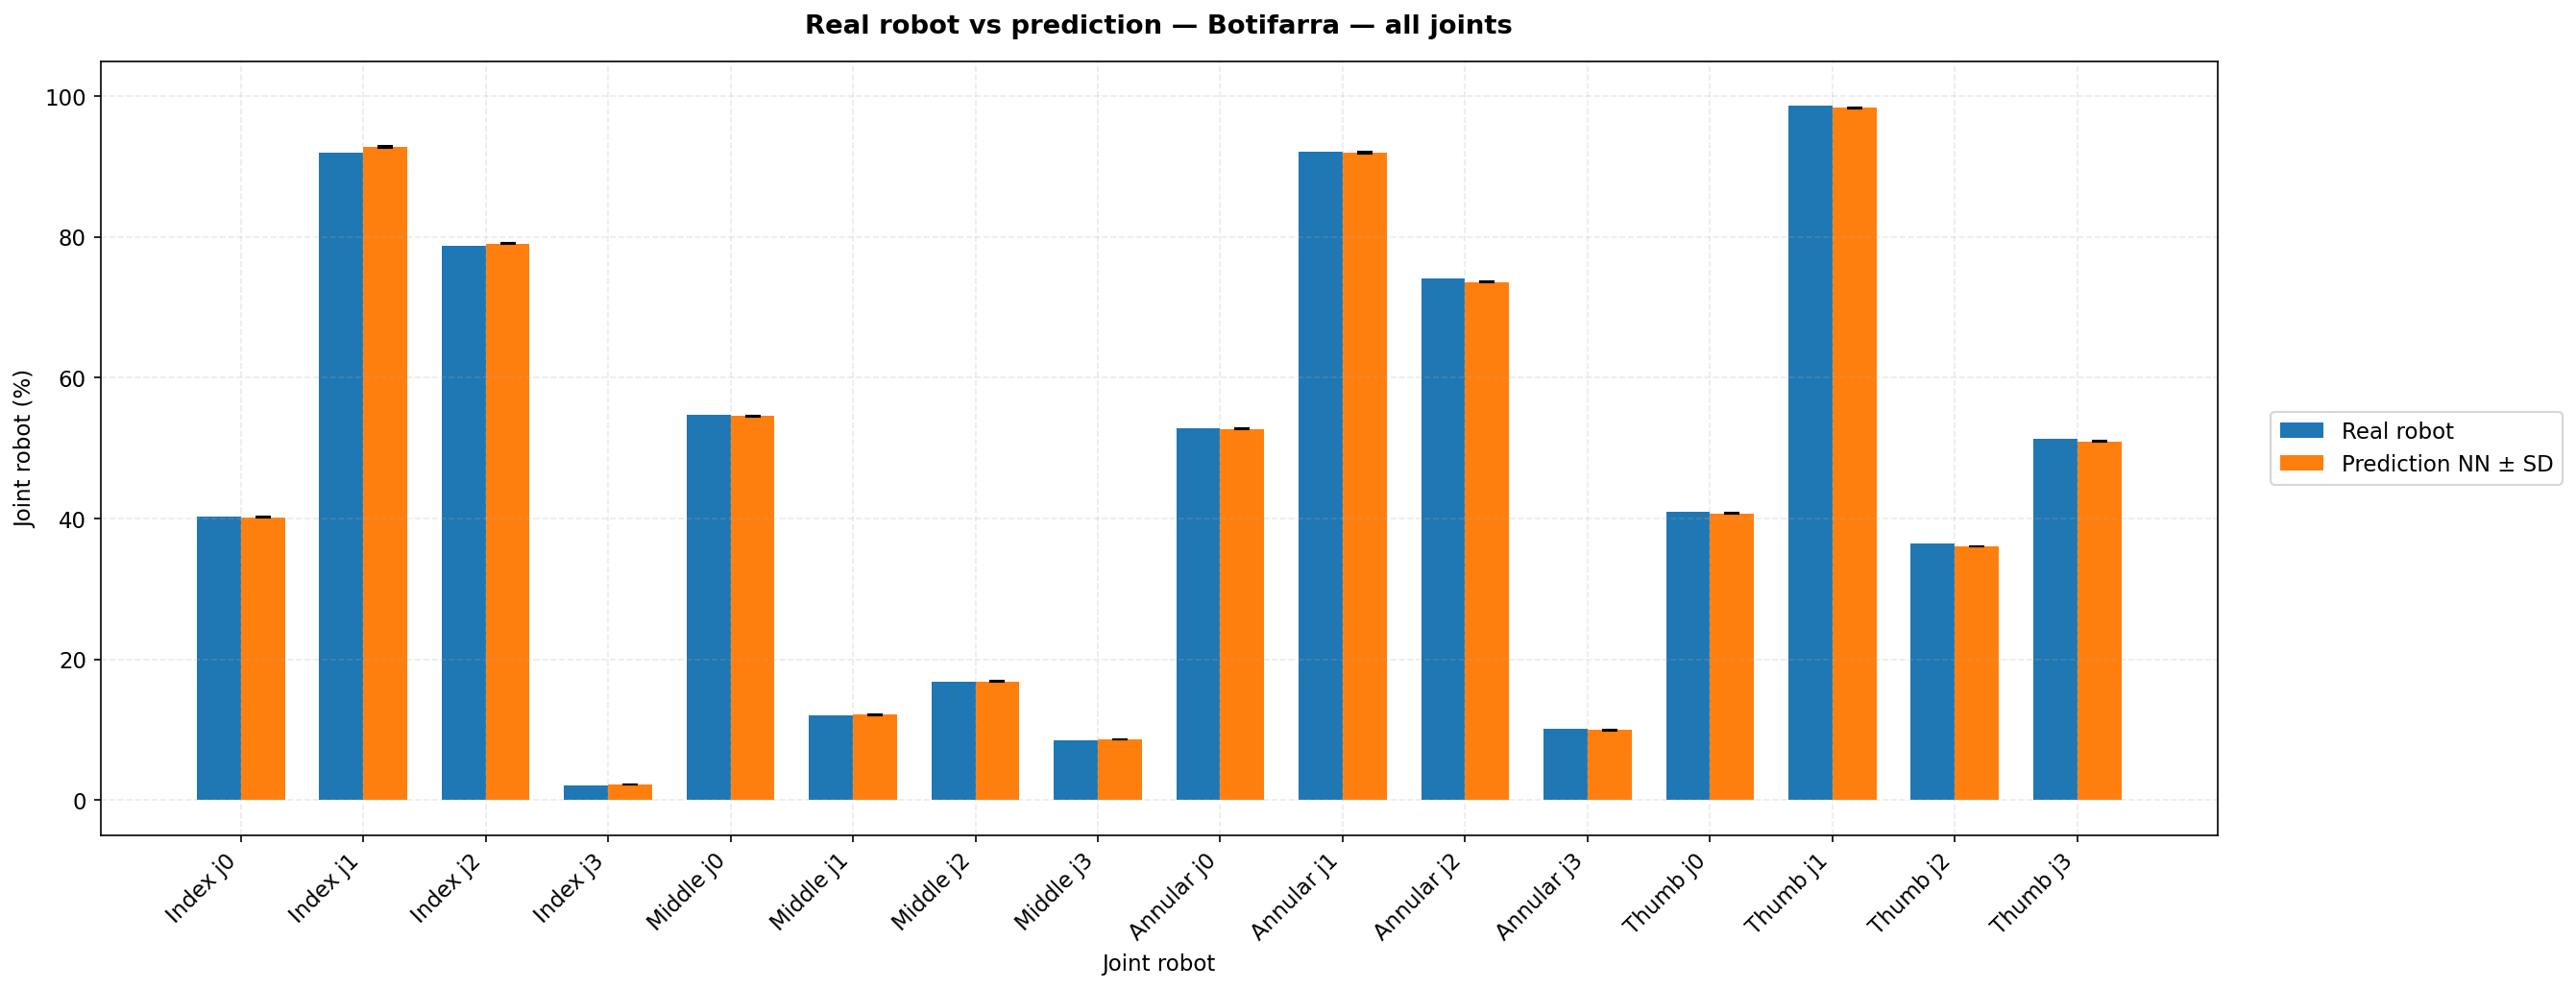

Generant resum tots els joints: OneStat — One


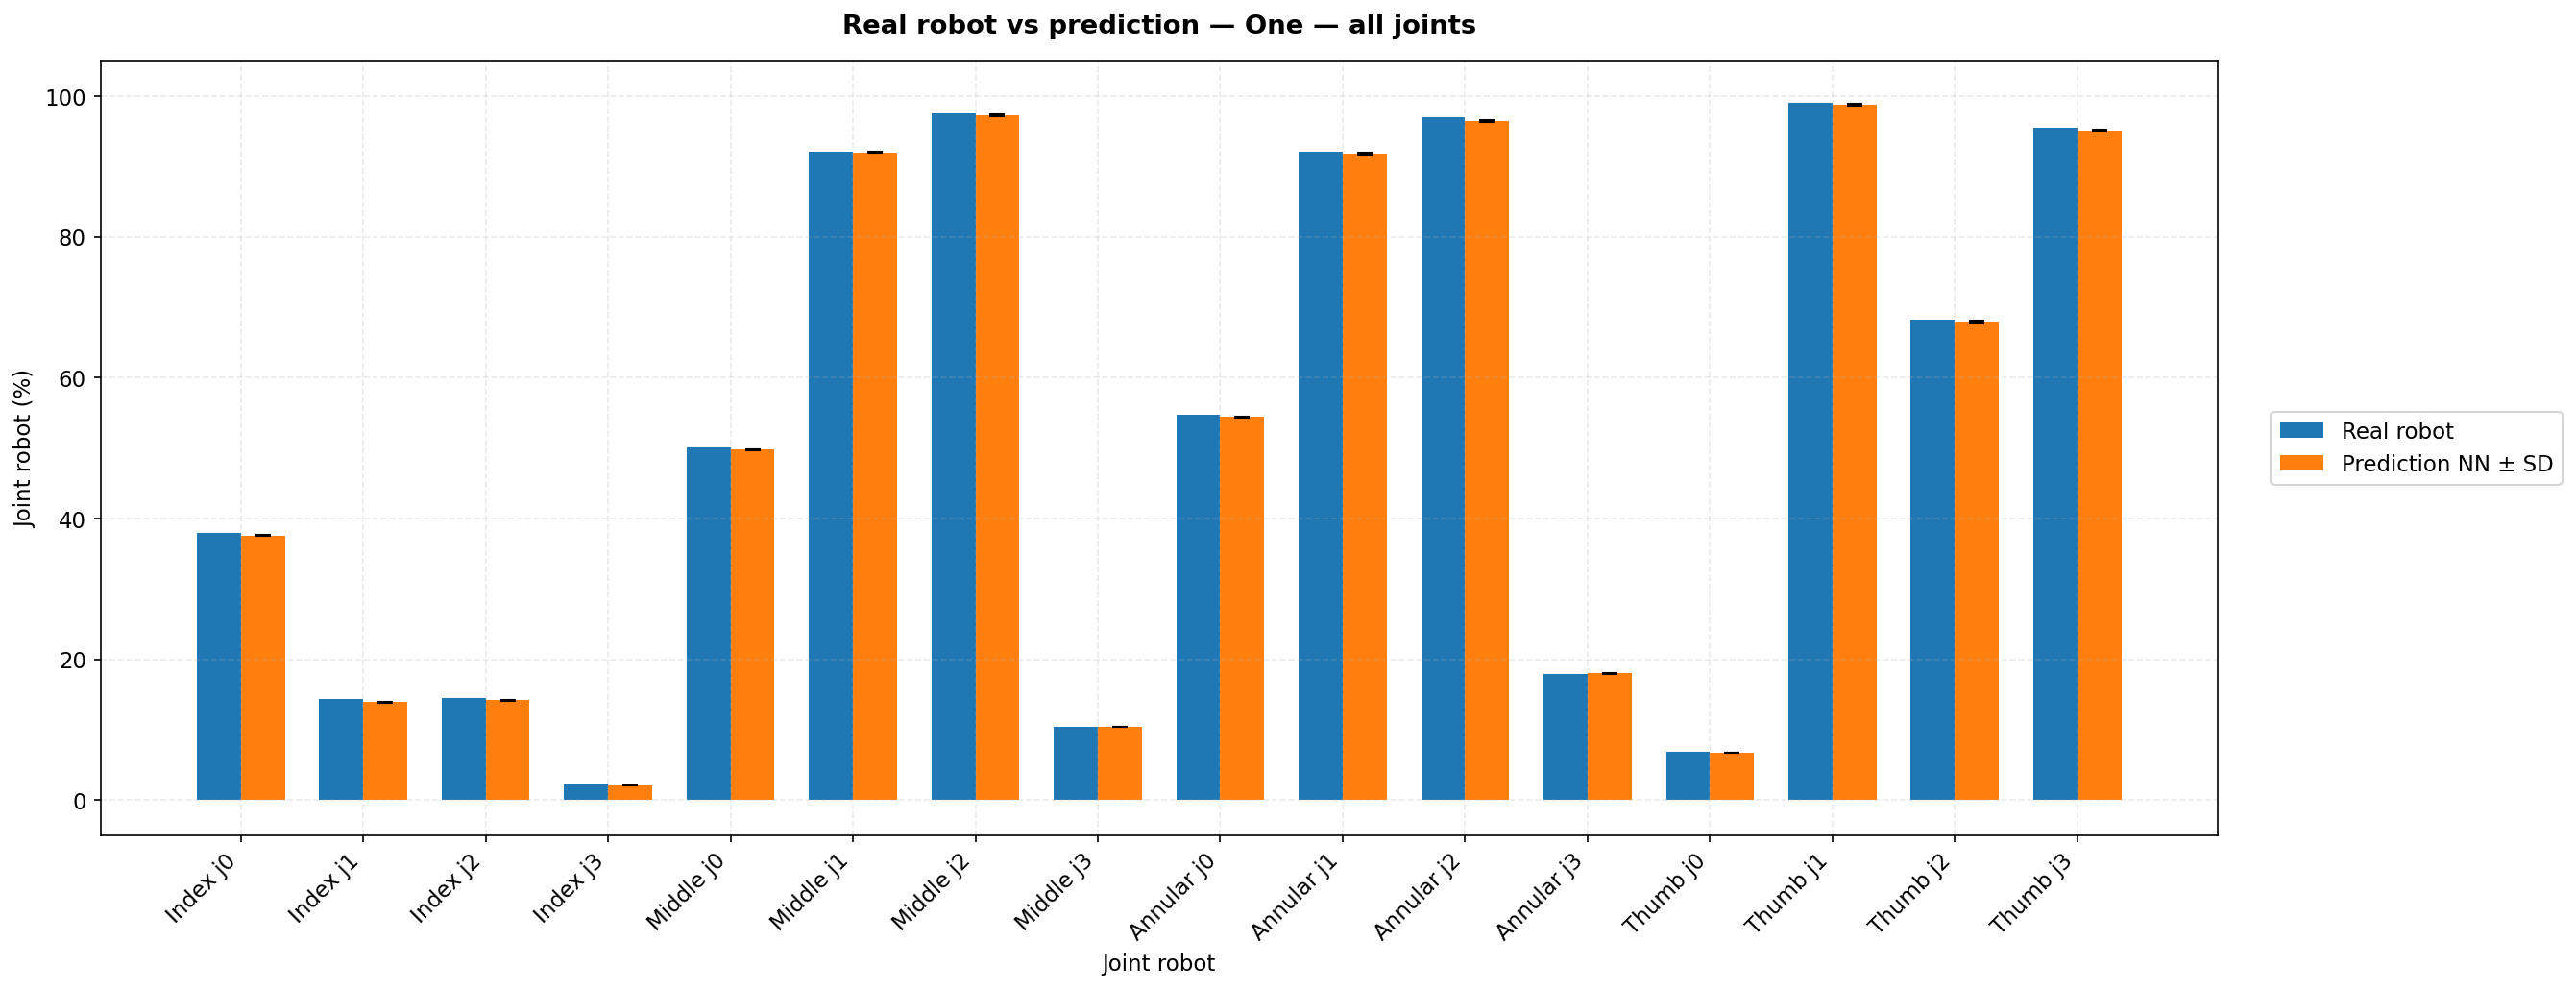

Generant resum tots els joints: PaperStat — Paper


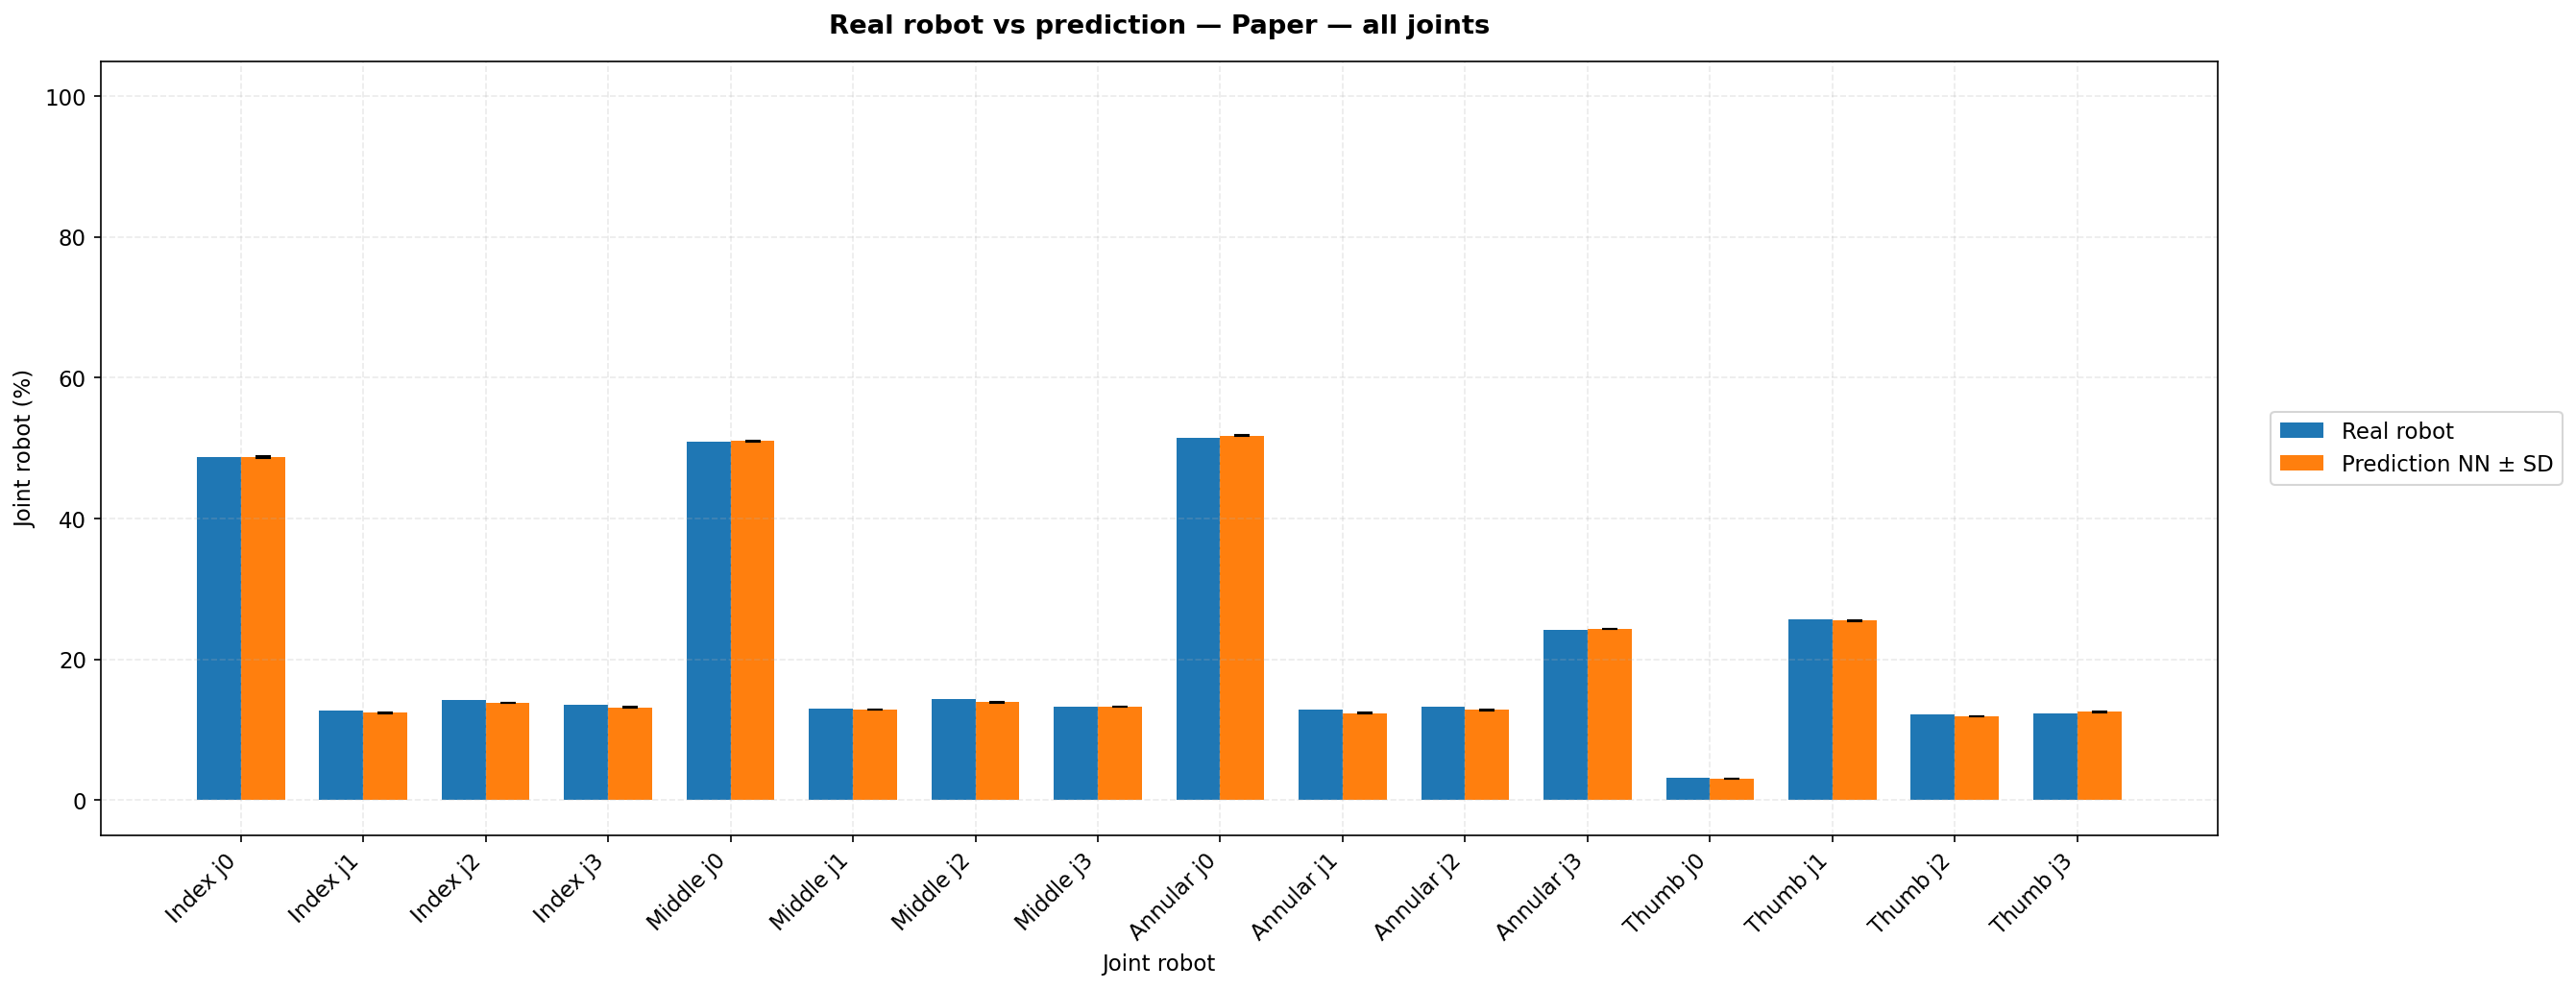

Generant resum tots els joints: RockStat — Rock


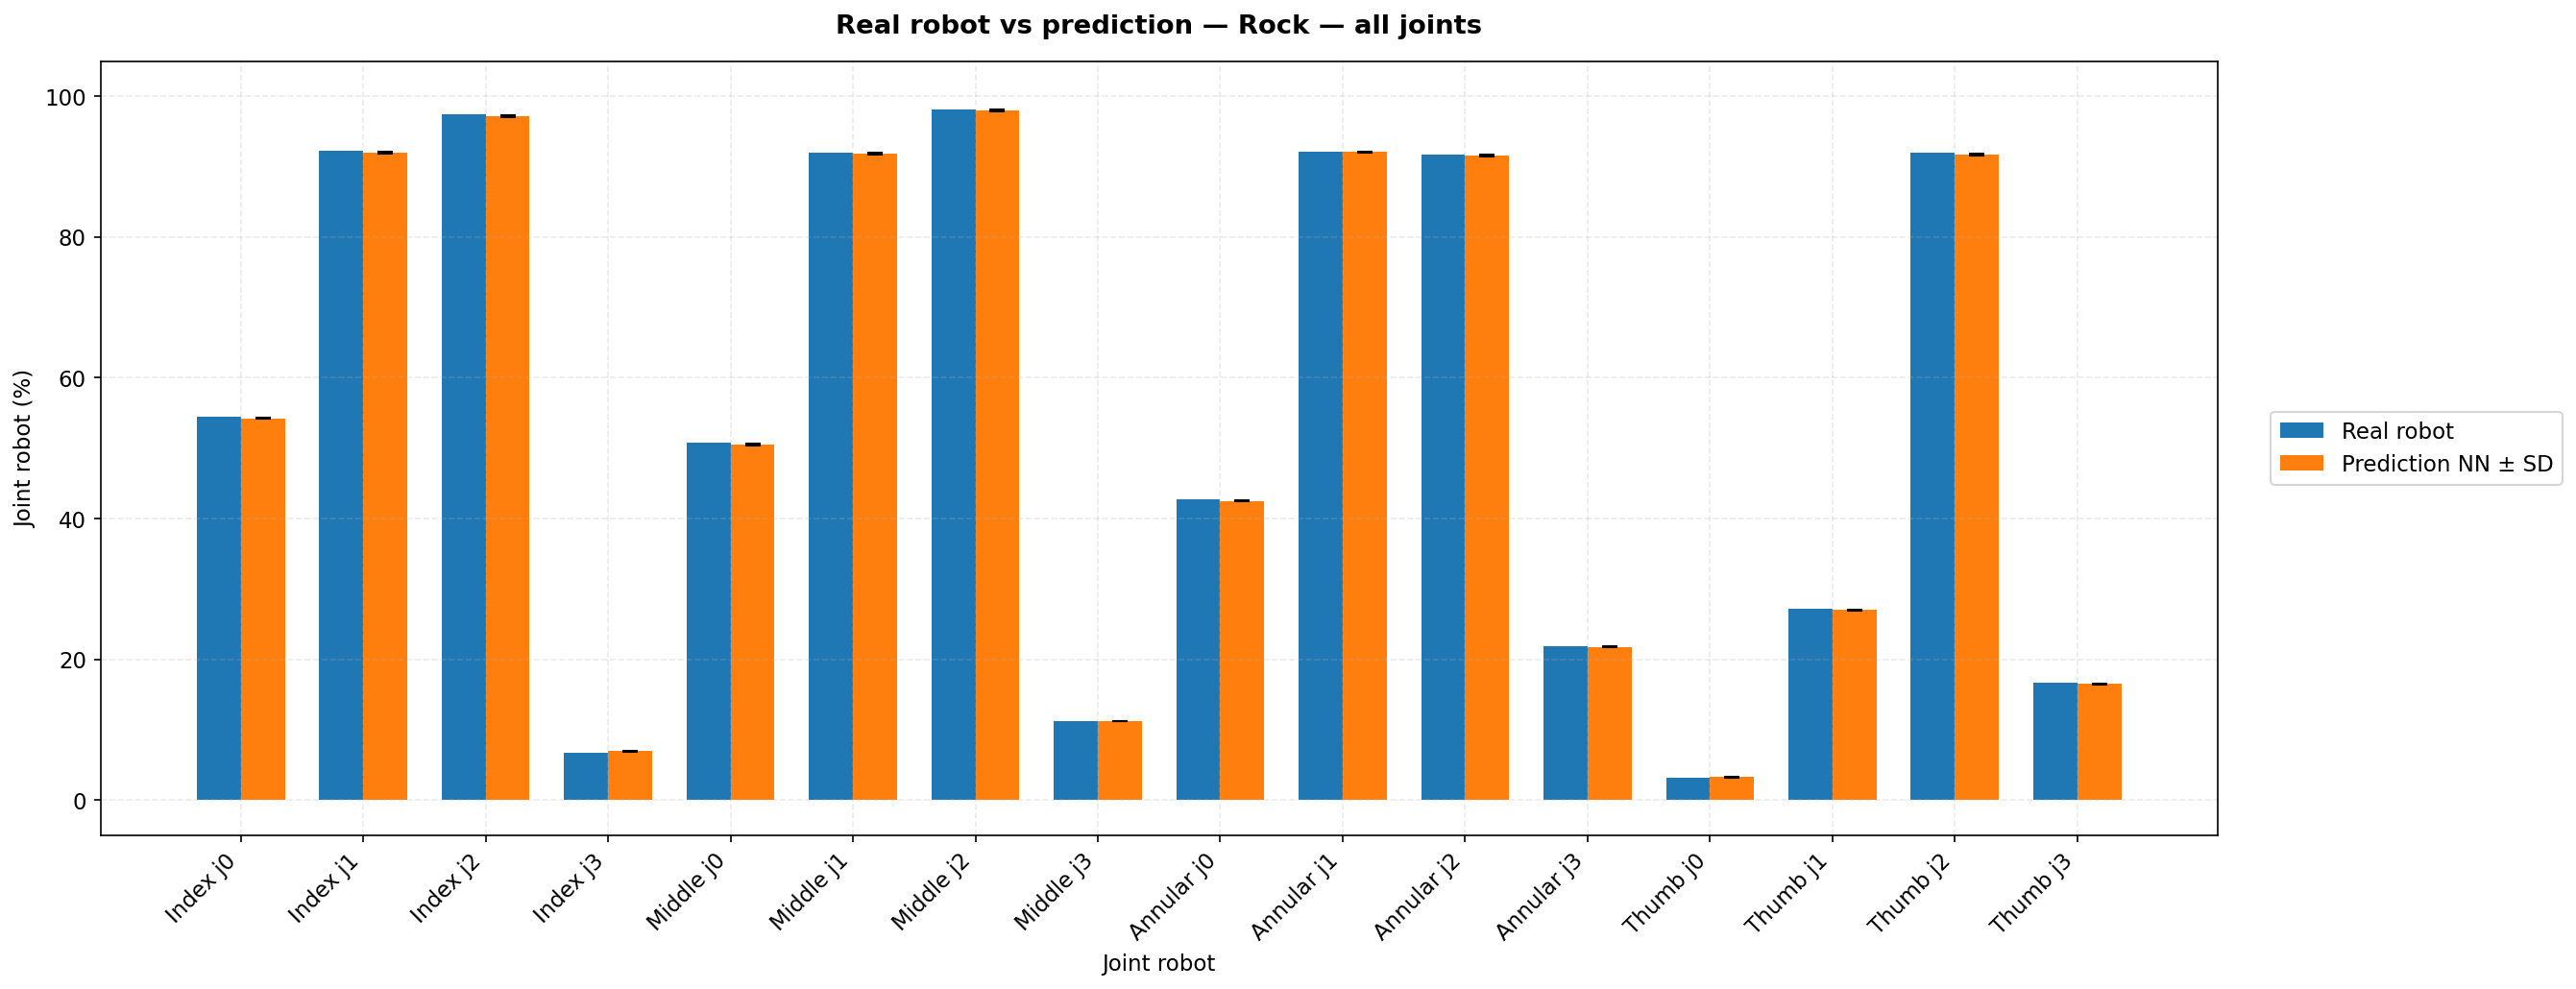

Generant resum tots els joints: ScisStat — Scissors


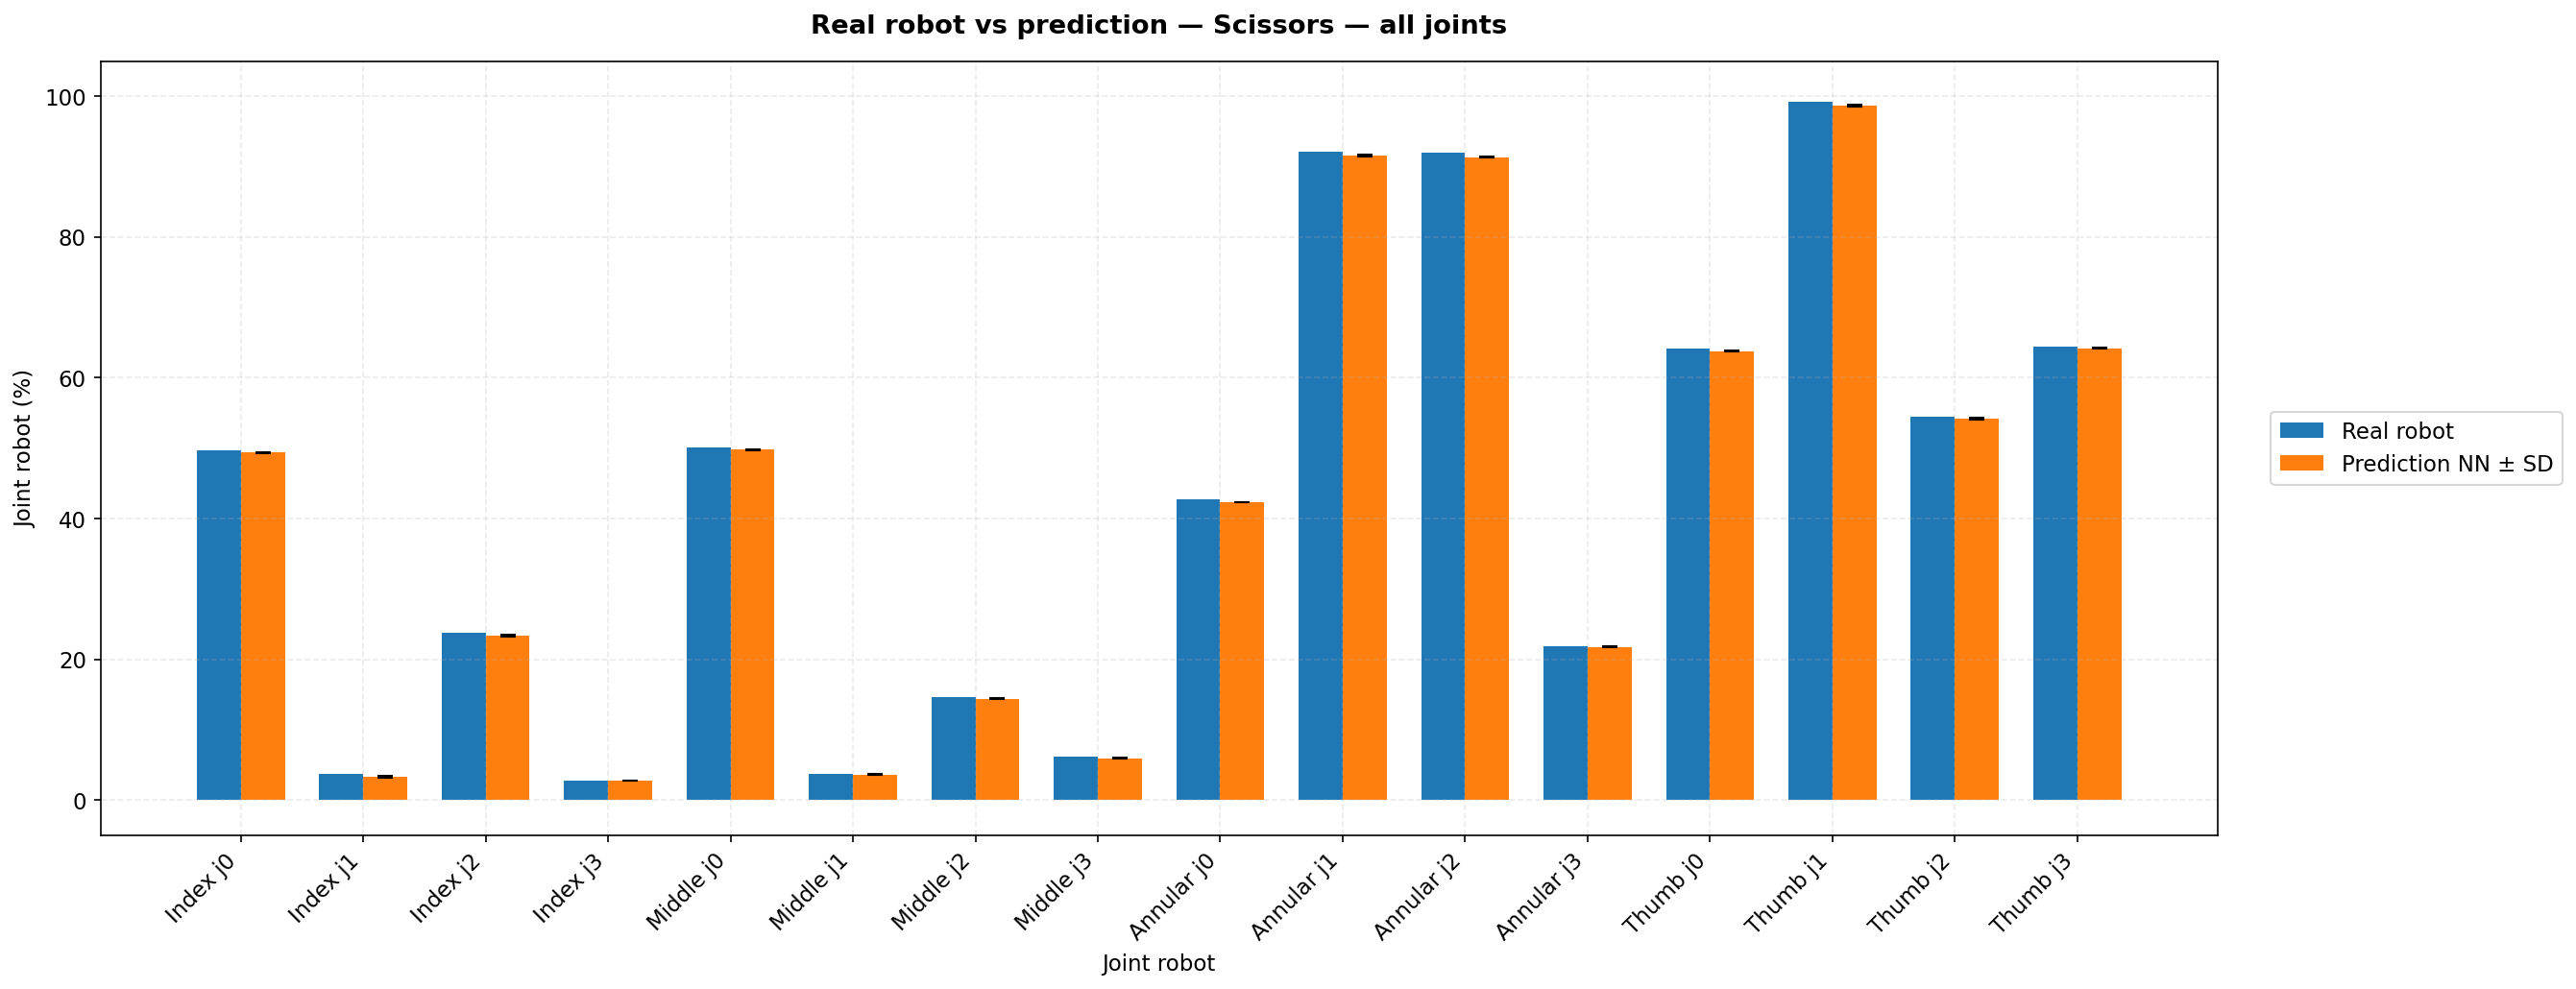

Generant resum tots els joints: ThumbUpStat — Thumb Up


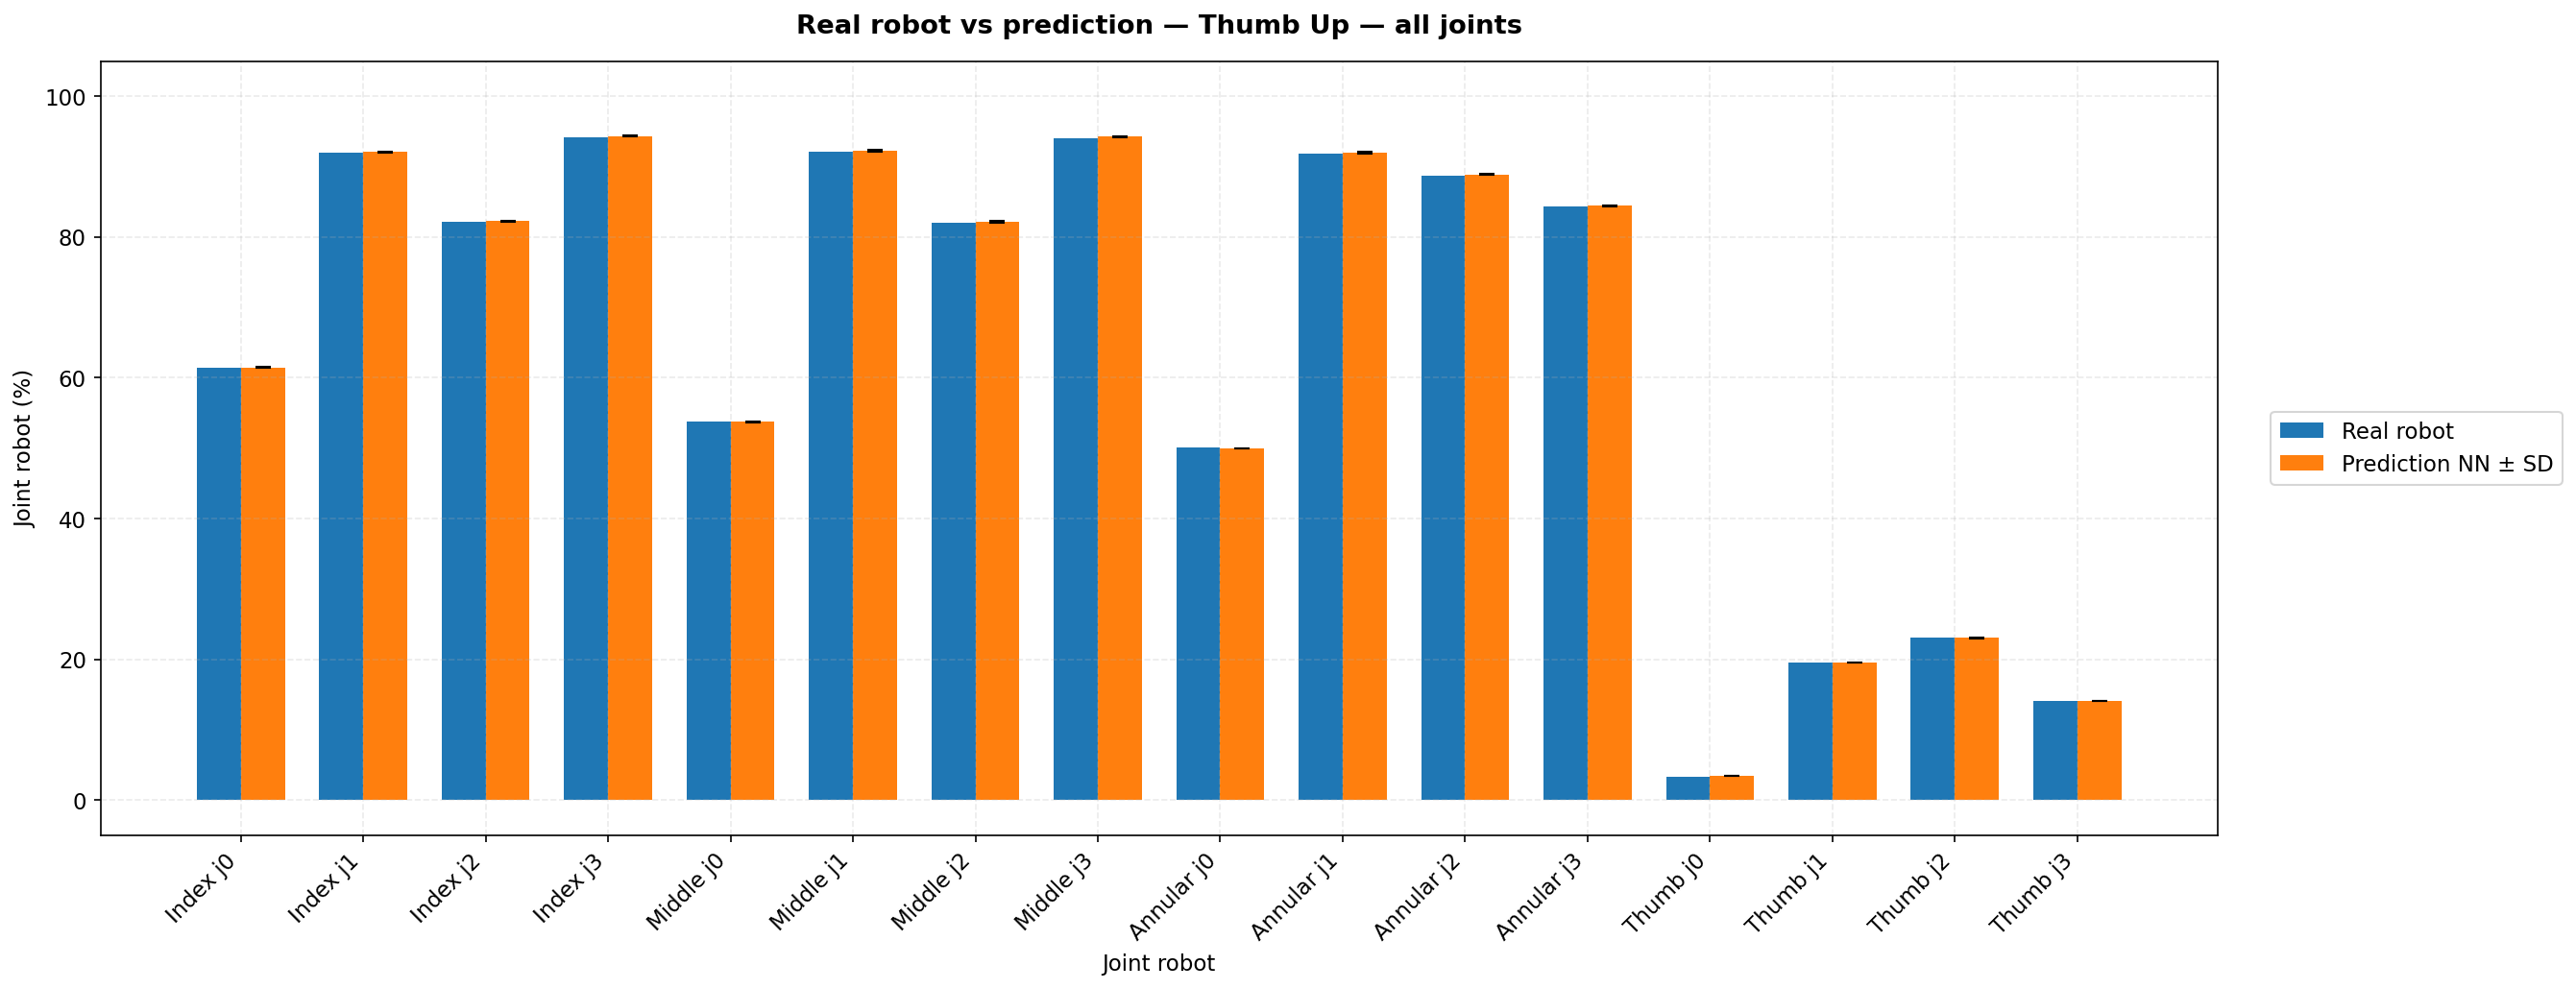

Figures resum amb tots els joints generades.


In [19]:

# ============================================================
# RESUM PER POSICIÓ AMB TOTS ELS JOINTS: REAL VS PREDICCIÓ
# ============================================================

def plot_all_joints_real_vs_prediction_by_position(pos):
    """
    Genera una figura resum per cada posició estàtica amb tots els joints del robot.
    Manté el mateix estil que els plots per grup, però agrupant els 16 joints en una sola figura.
    """

    pos_name = static_position_names[pos]
    pos_folder = output_dir / pos / "summary_all_joints"
    pos_folder.mkdir(parents=True, exist_ok=True)

    subset = position_metrics_df[
        position_metrics_df["position_code"] == pos
    ].copy()

    if subset.empty:
        print(f"No hi ha dades per a {pos}")
        return

    subset["joint"] = pd.Categorical(
        subset["joint"],
        categories=robot_joint_order,
        ordered=True,
    )

    subset = subset.sort_values("joint")

    x = np.arange(len(subset))
    width = 0.36

    fig, ax = plt.subplots(
        figsize=(18, 7),
        dpi=150,
    )

    ax.bar(
        x - width / 2,
        subset["true_mean"],
        width,
        label="Real robot",
    )

    ax.bar(
        x + width / 2,
        subset["pred_mean"],
        width,
        yerr=subset["pred_std"],
        capsize=4,
        label="Prediction NN ± SD",
    )

    ax.set_title(
        f"Real robot vs prediction — {pos_name} — all joints",
        fontweight="bold",
        pad=14,
    )

    ax.set_xlabel("Joint robot")
    ax.set_ylabel("Joint robot (%)")
    ax.set_ylim(-5, 105)

    ax.set_xticks(x)
    ax.set_xticklabels(
        subset["joint"],
        rotation=45,
        ha="right",
    )

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.25,
        linestyle="--",
    )

    fig.tight_layout()

    fig.savefig(
        pos_folder / f"{pos}_all_joints_real_vs_prediction.png",
        bbox_inches="tight",
    )

    fig.savefig(
        pos_folder / f"{pos}_all_joints_real_vs_prediction.pdf",
        bbox_inches="tight",
    )

    subset.to_csv(
        pos_folder / f"{pos}_all_joints_real_vs_prediction_metrics.csv",
        index=False,
    )

    plt.show()


# ============================================================
# GENERAR RESUMS DE TOTES LES POSICIONS
# ============================================================

for pos in sorted(position_metrics_df["position_code"].unique()):
    print(f"Generant resum tots els joints: {pos} — {static_position_names[pos]}")

    plot_all_joints_real_vs_prediction_by_position(pos)

print("Figures resum amb tots els joints generades.")


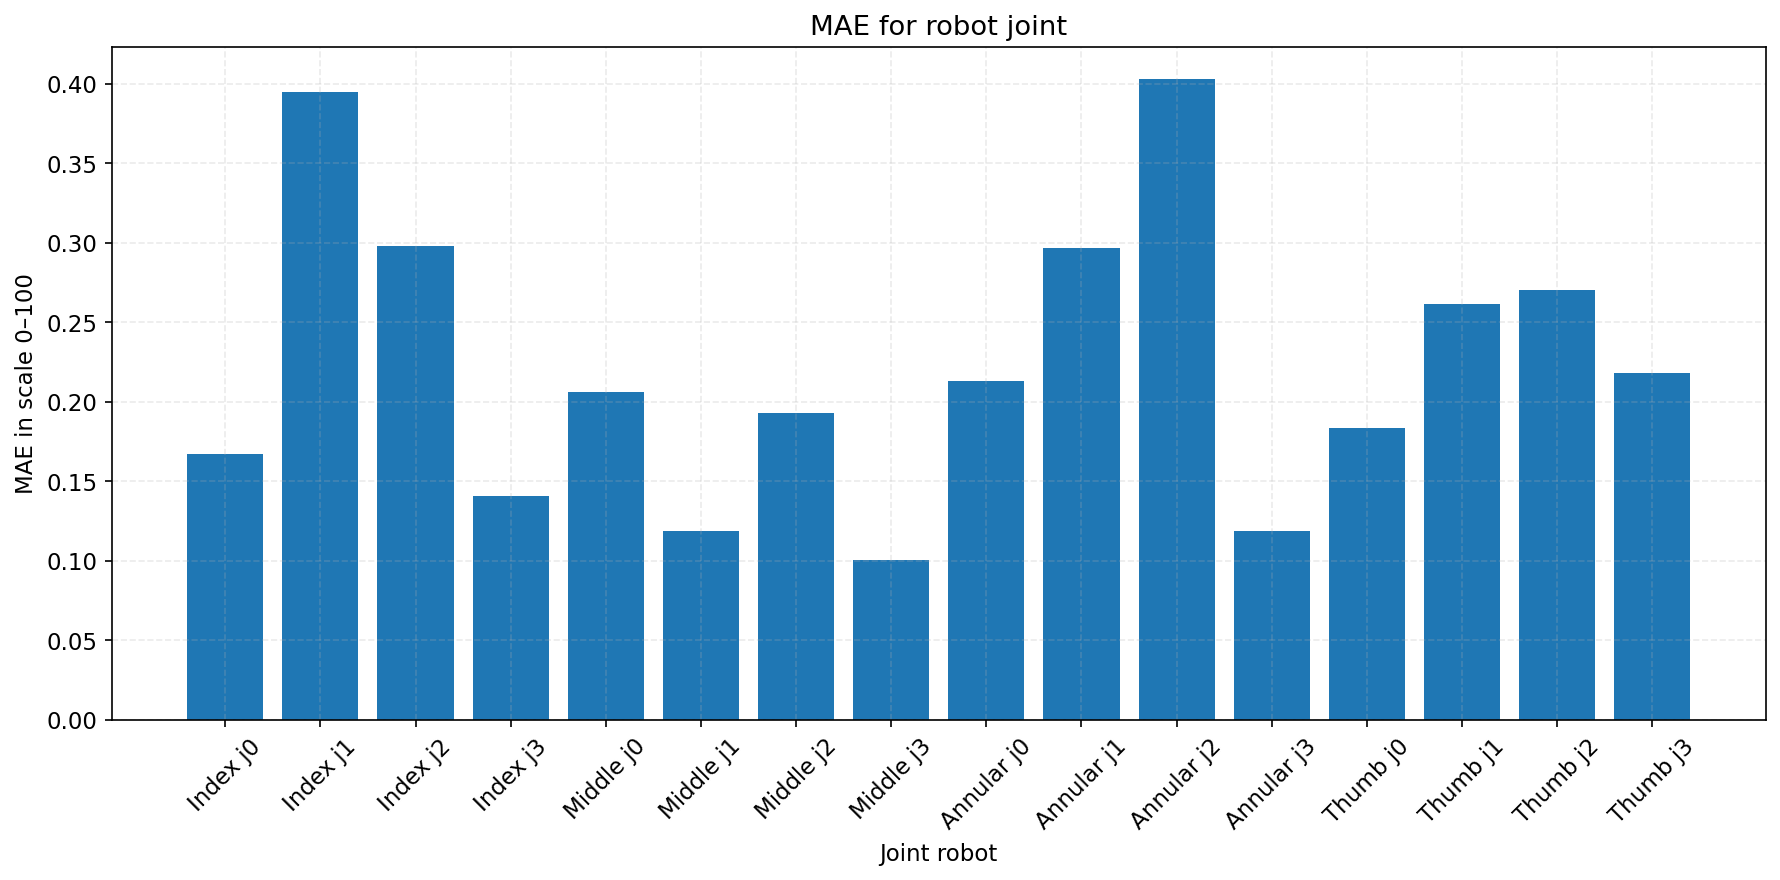

In [25]:
# ============================================================
# ERROR PER JOINT
# ============================================================

plot_df = metrics_df.copy()
plot_df["joint"] = pd.Categorical(plot_df["joint"], categories=robot_joint_order, ordered=True)
plot_df = plot_df.sort_values("joint")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["joint"].astype(str), plot_df["MAE"])
ax.set_title("MAE for robot joint")
ax.set_xlabel("Joint robot")
ax.set_ylabel("MAE in scale 0–100")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(output_dir / "mae_by_robot_joint.png", bbox_inches="tight")
plt.show()


Generant resum estàtic: BotiStat — Botifarra


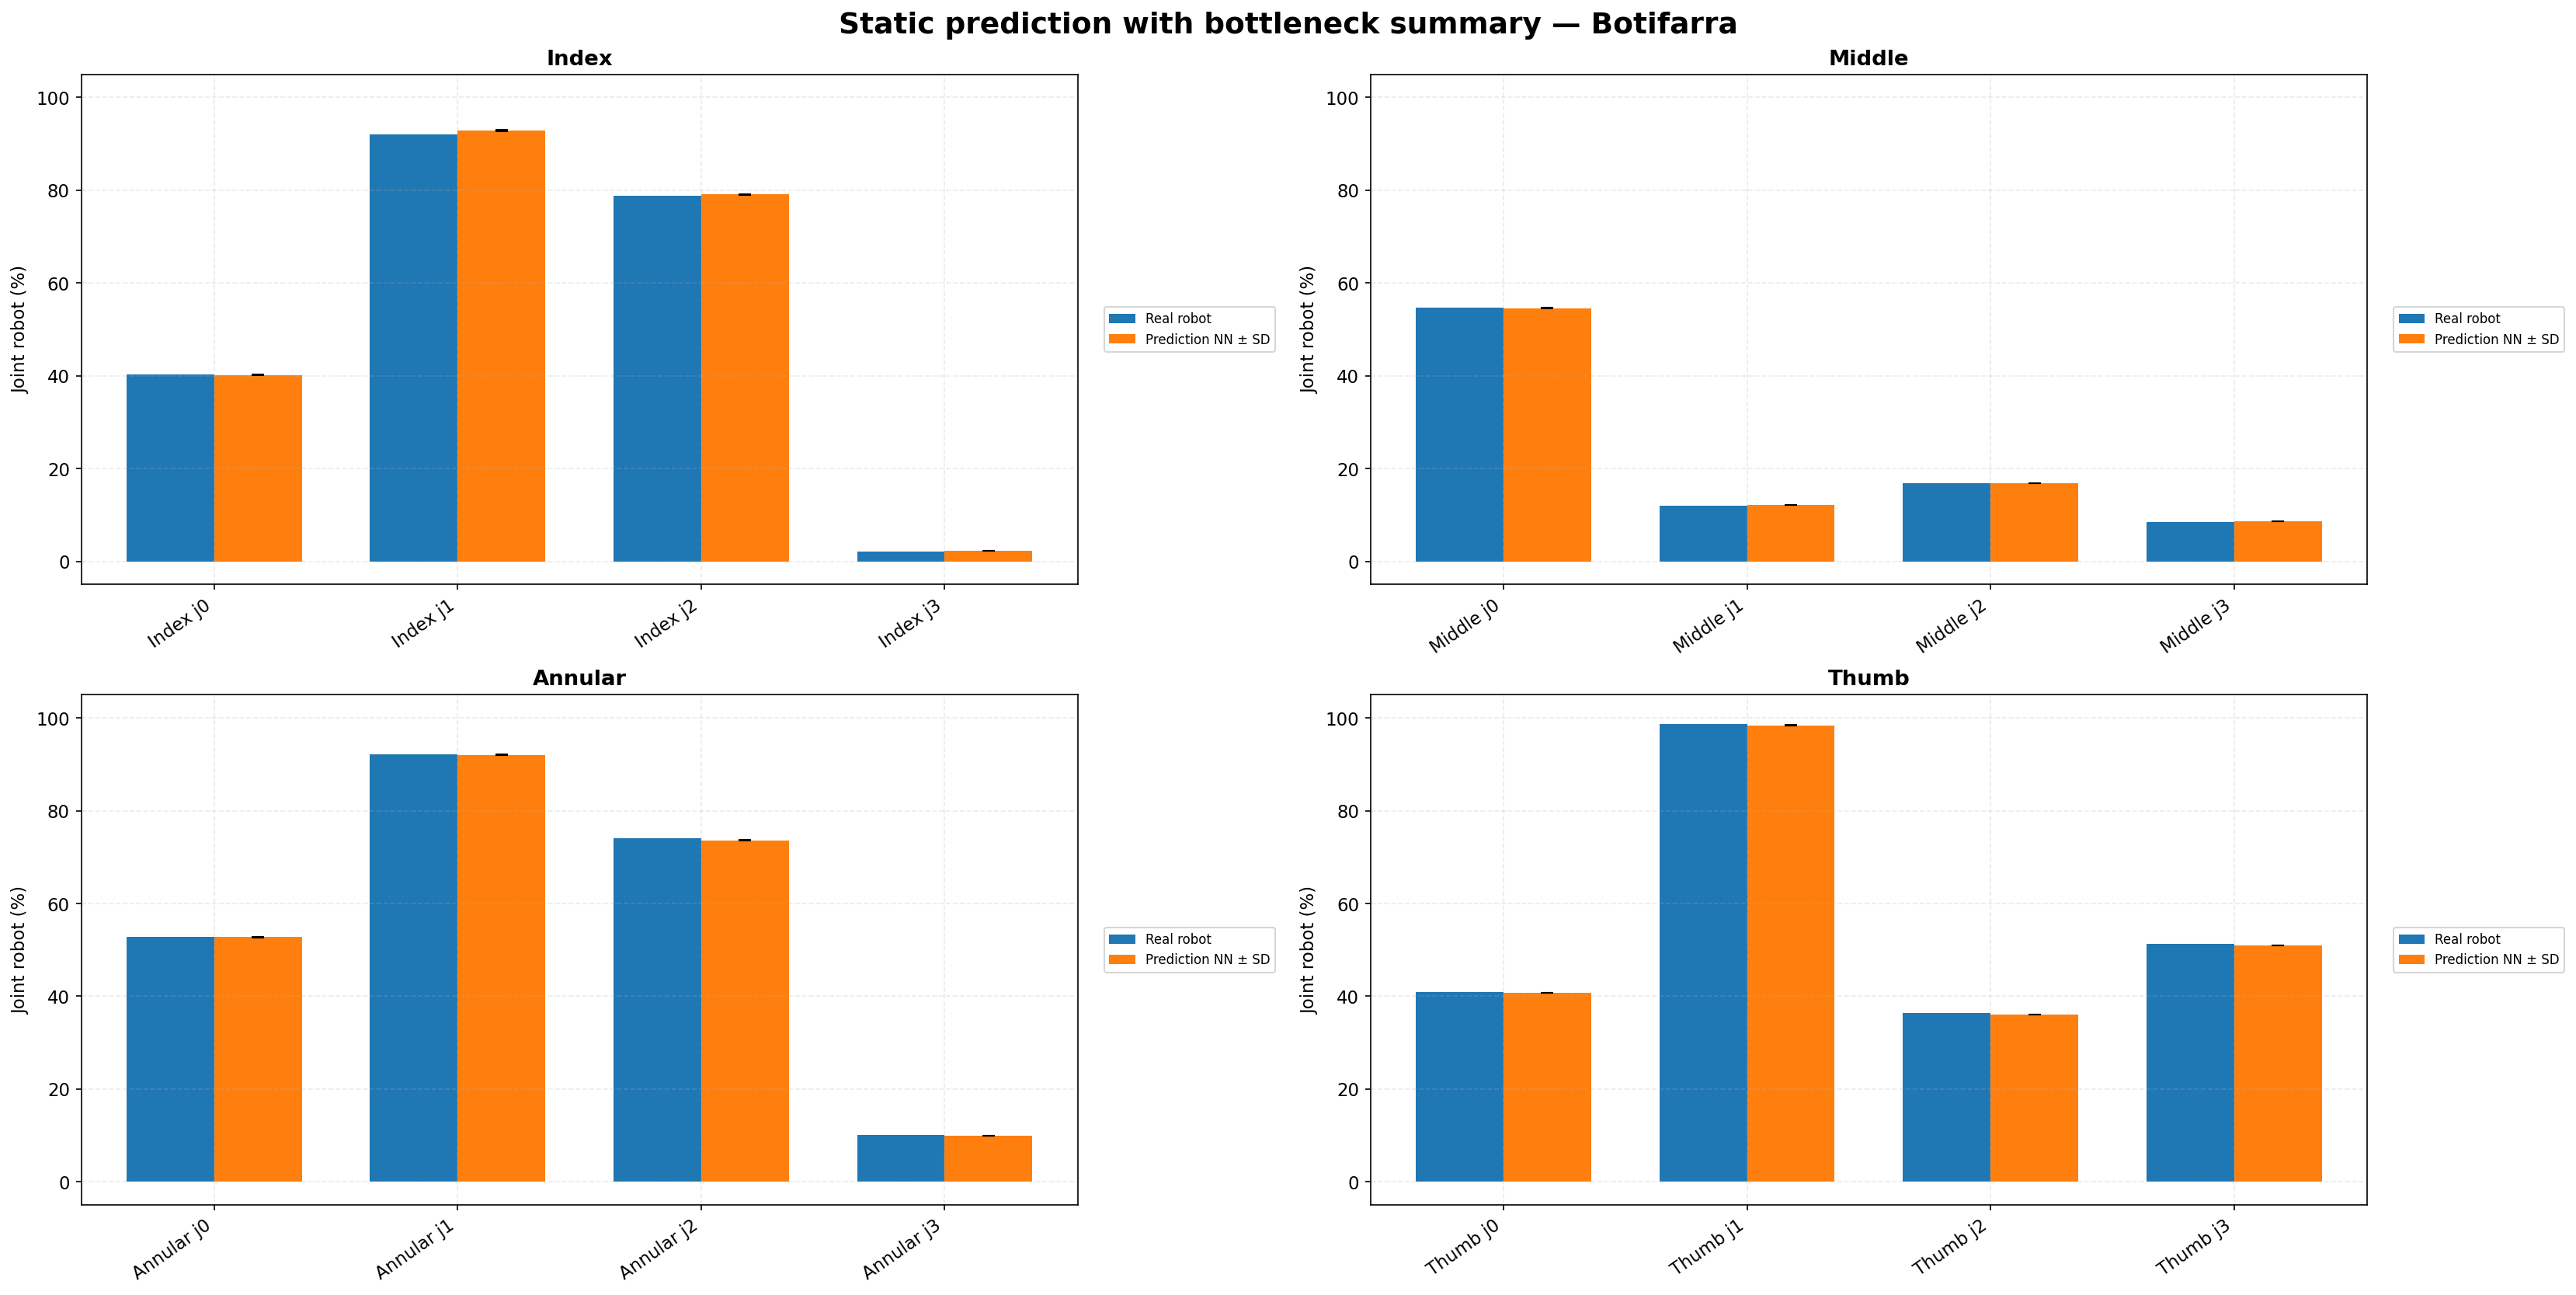

Generant resum estàtic: OneStat — One


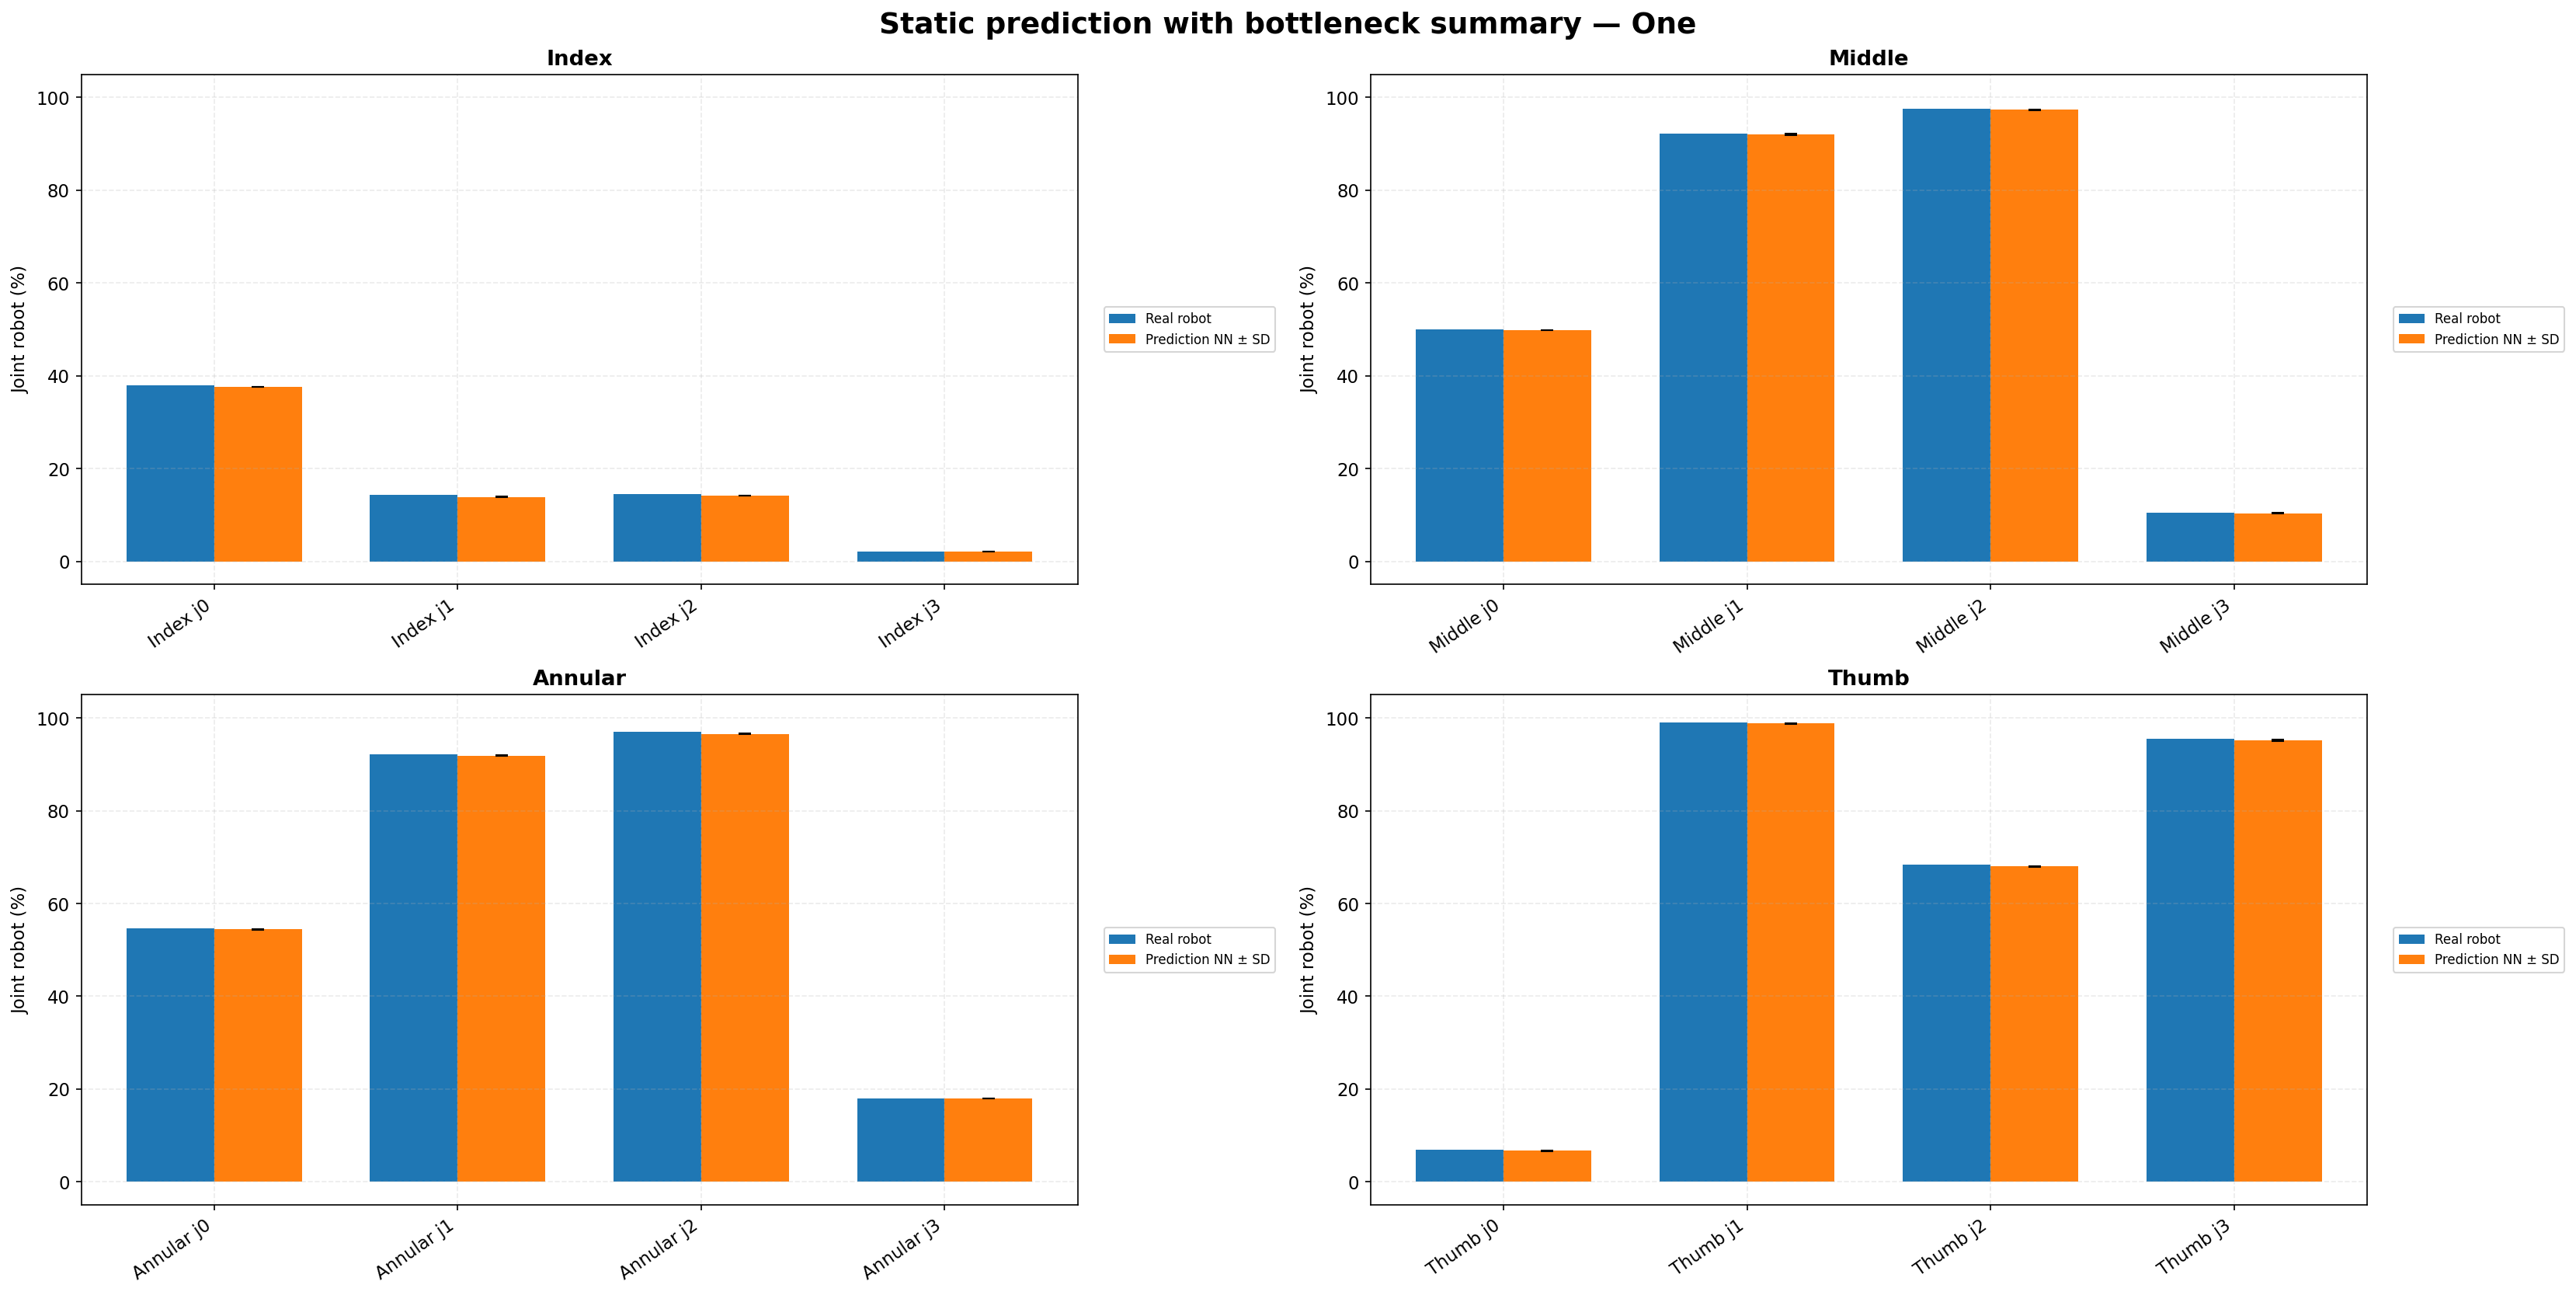

Generant resum estàtic: PaperStat — Paper


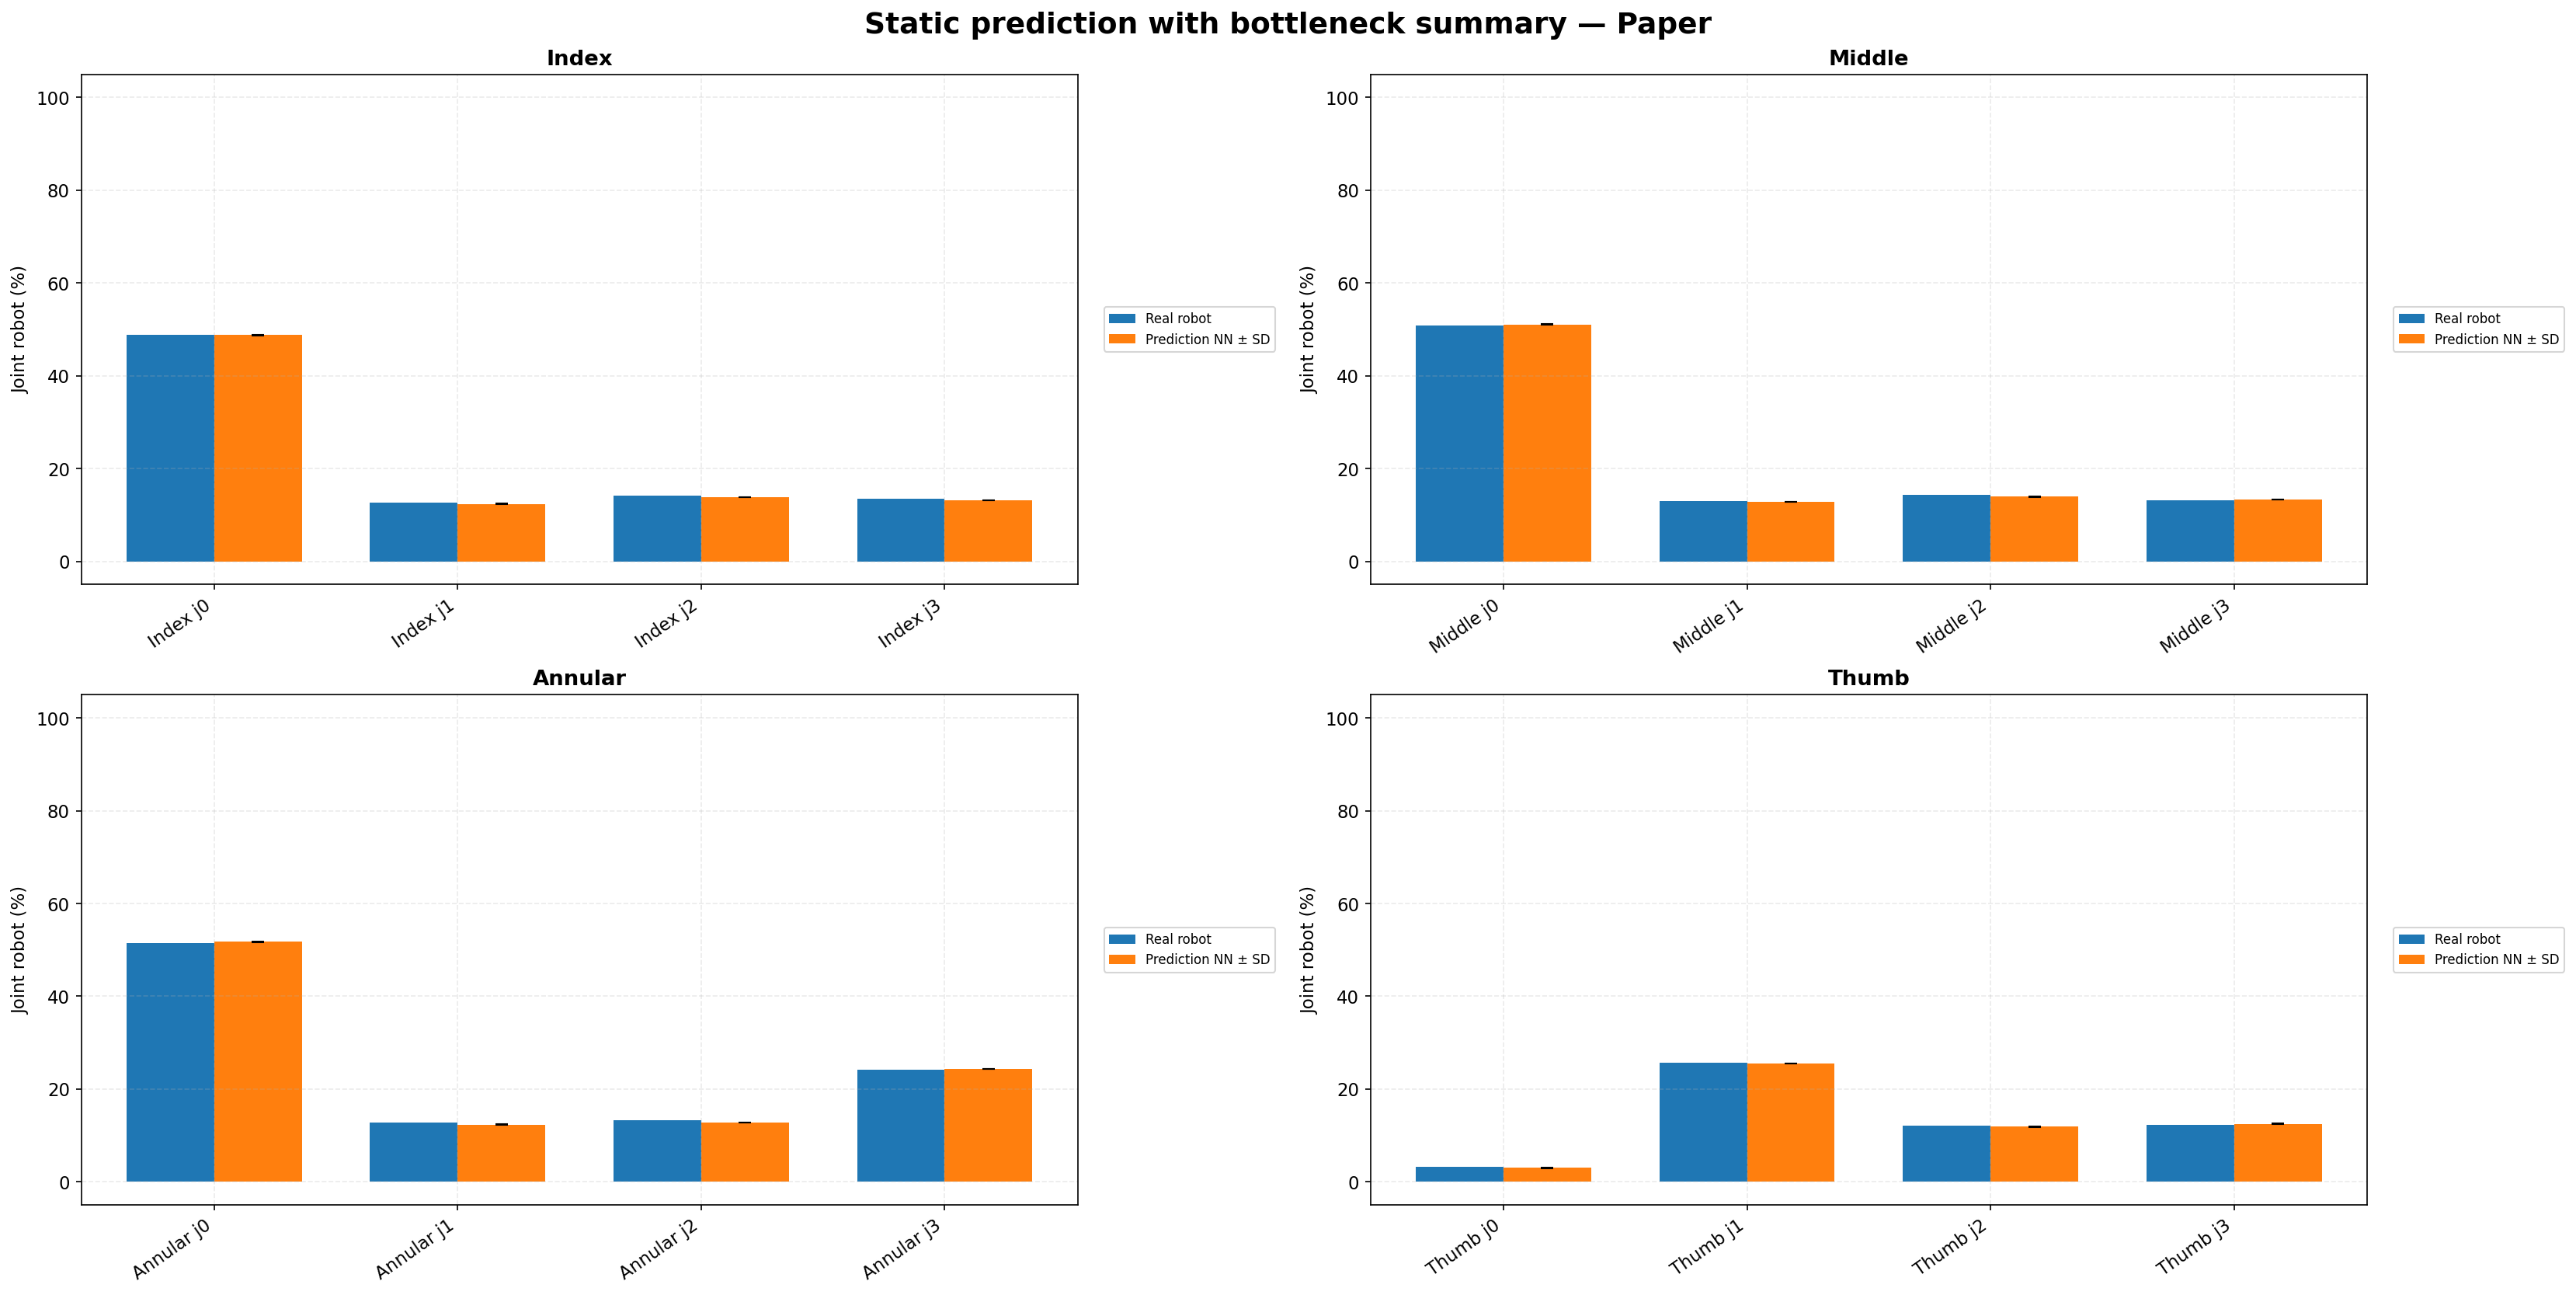

Generant resum estàtic: RockStat — Rock


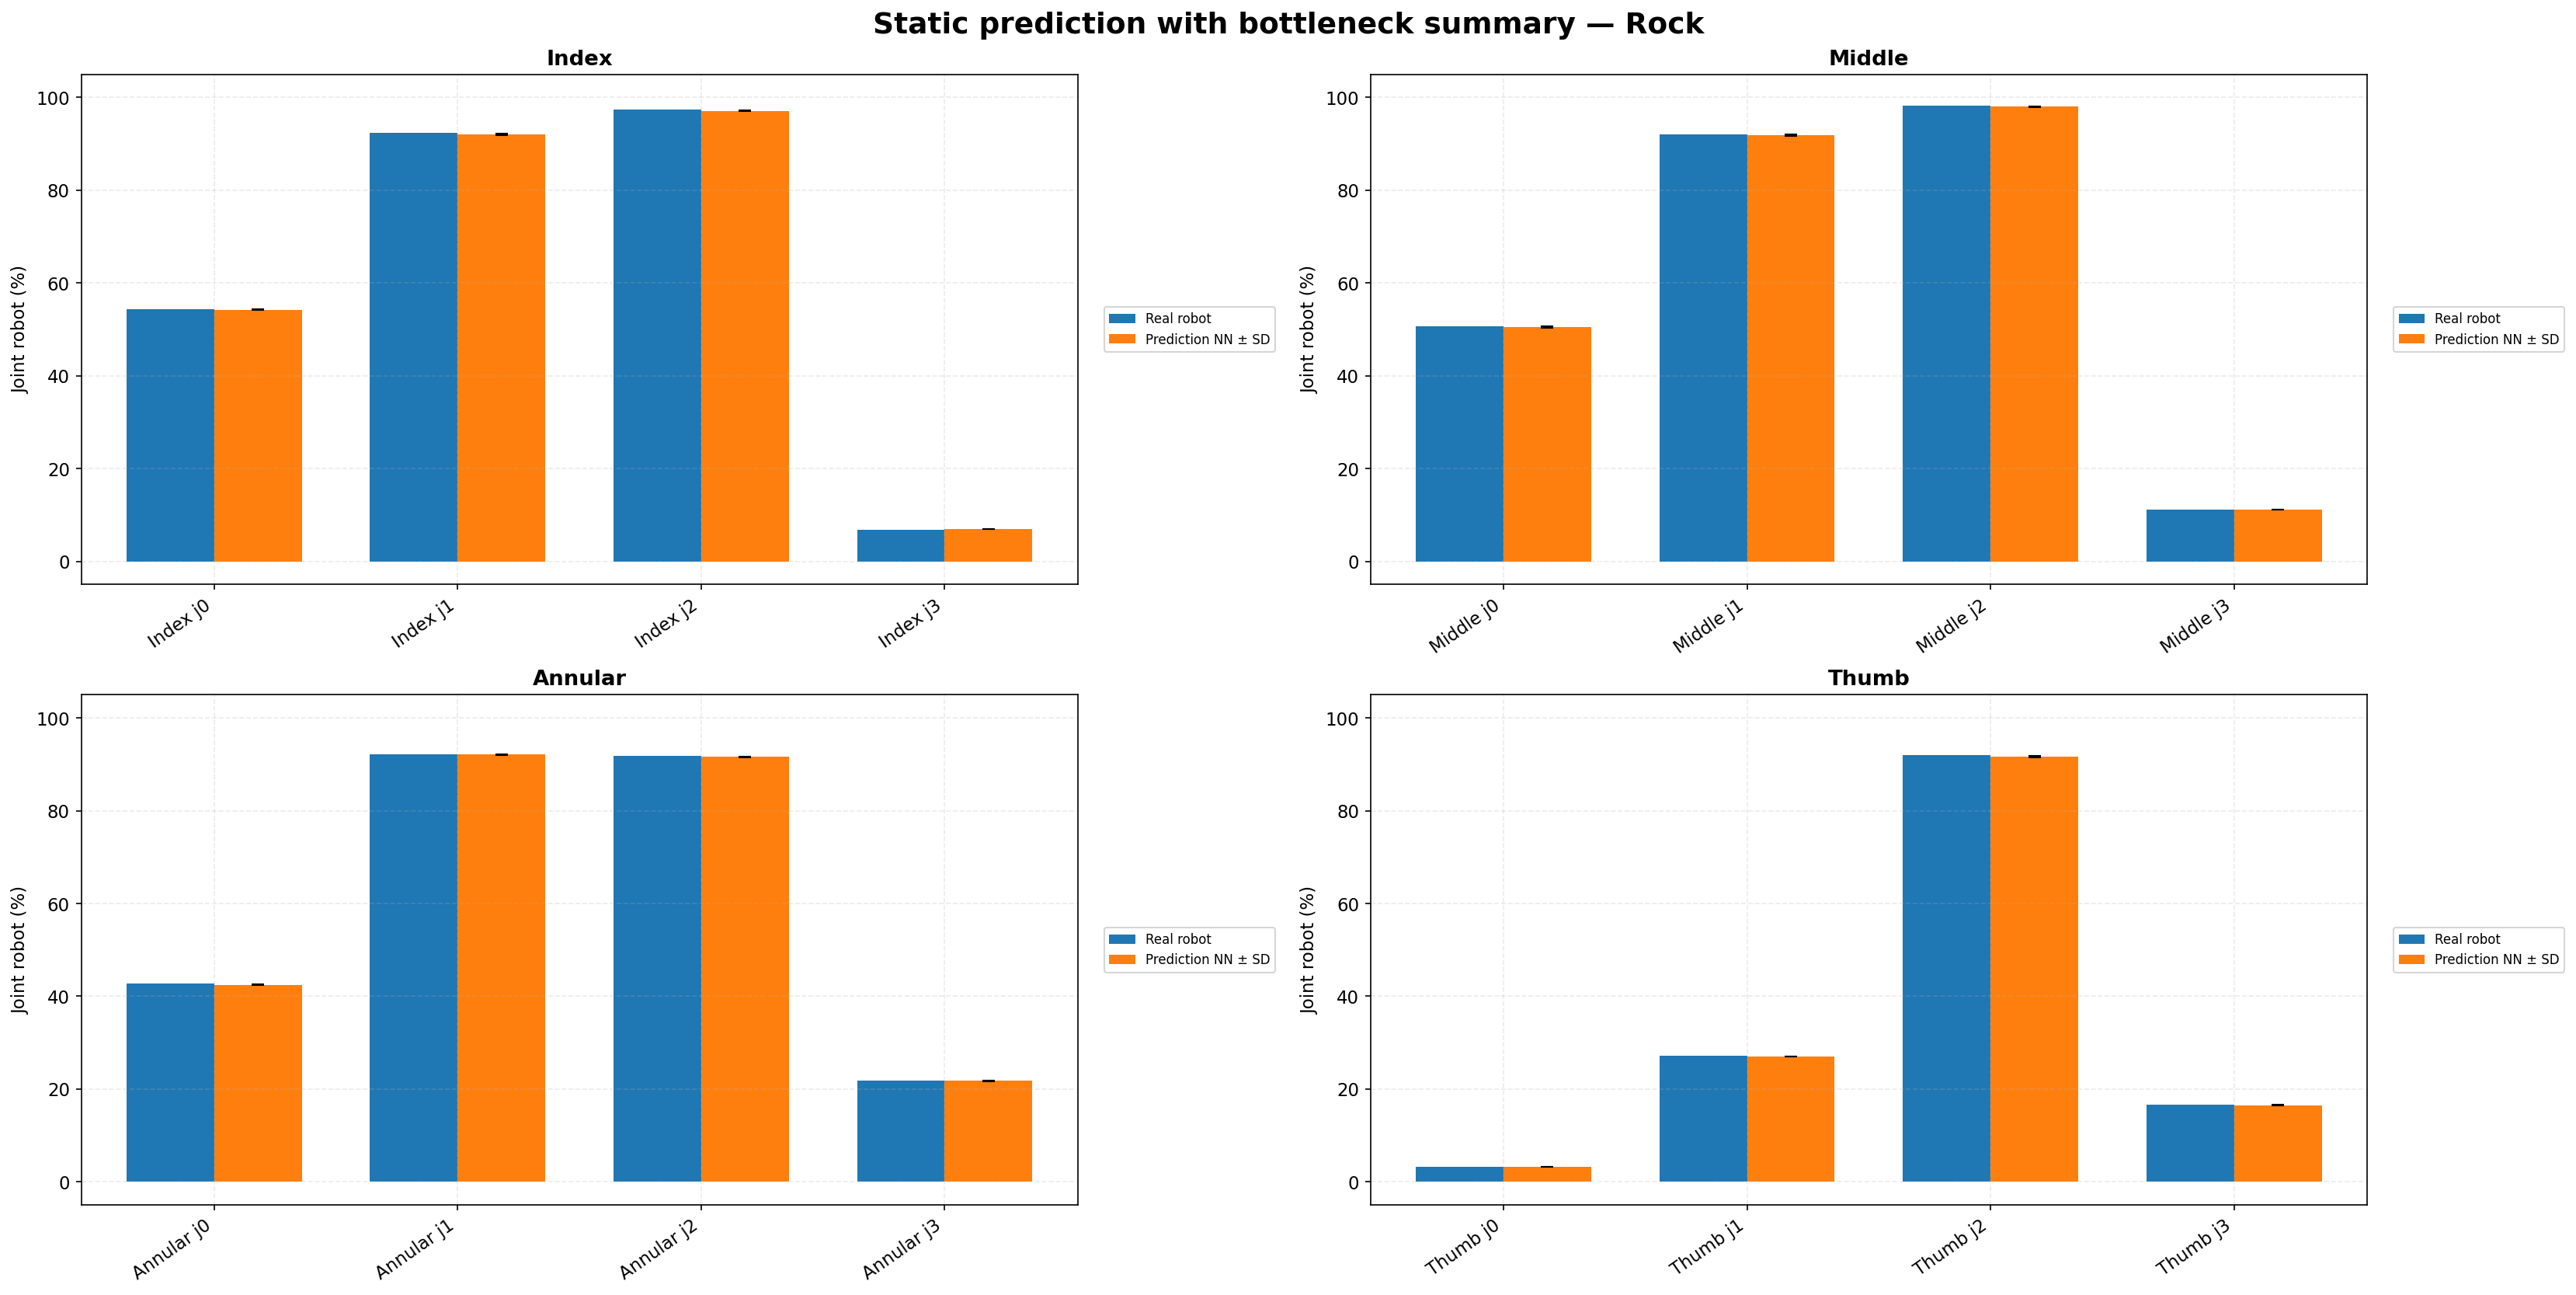

Generant resum estàtic: ScisStat — Scissors


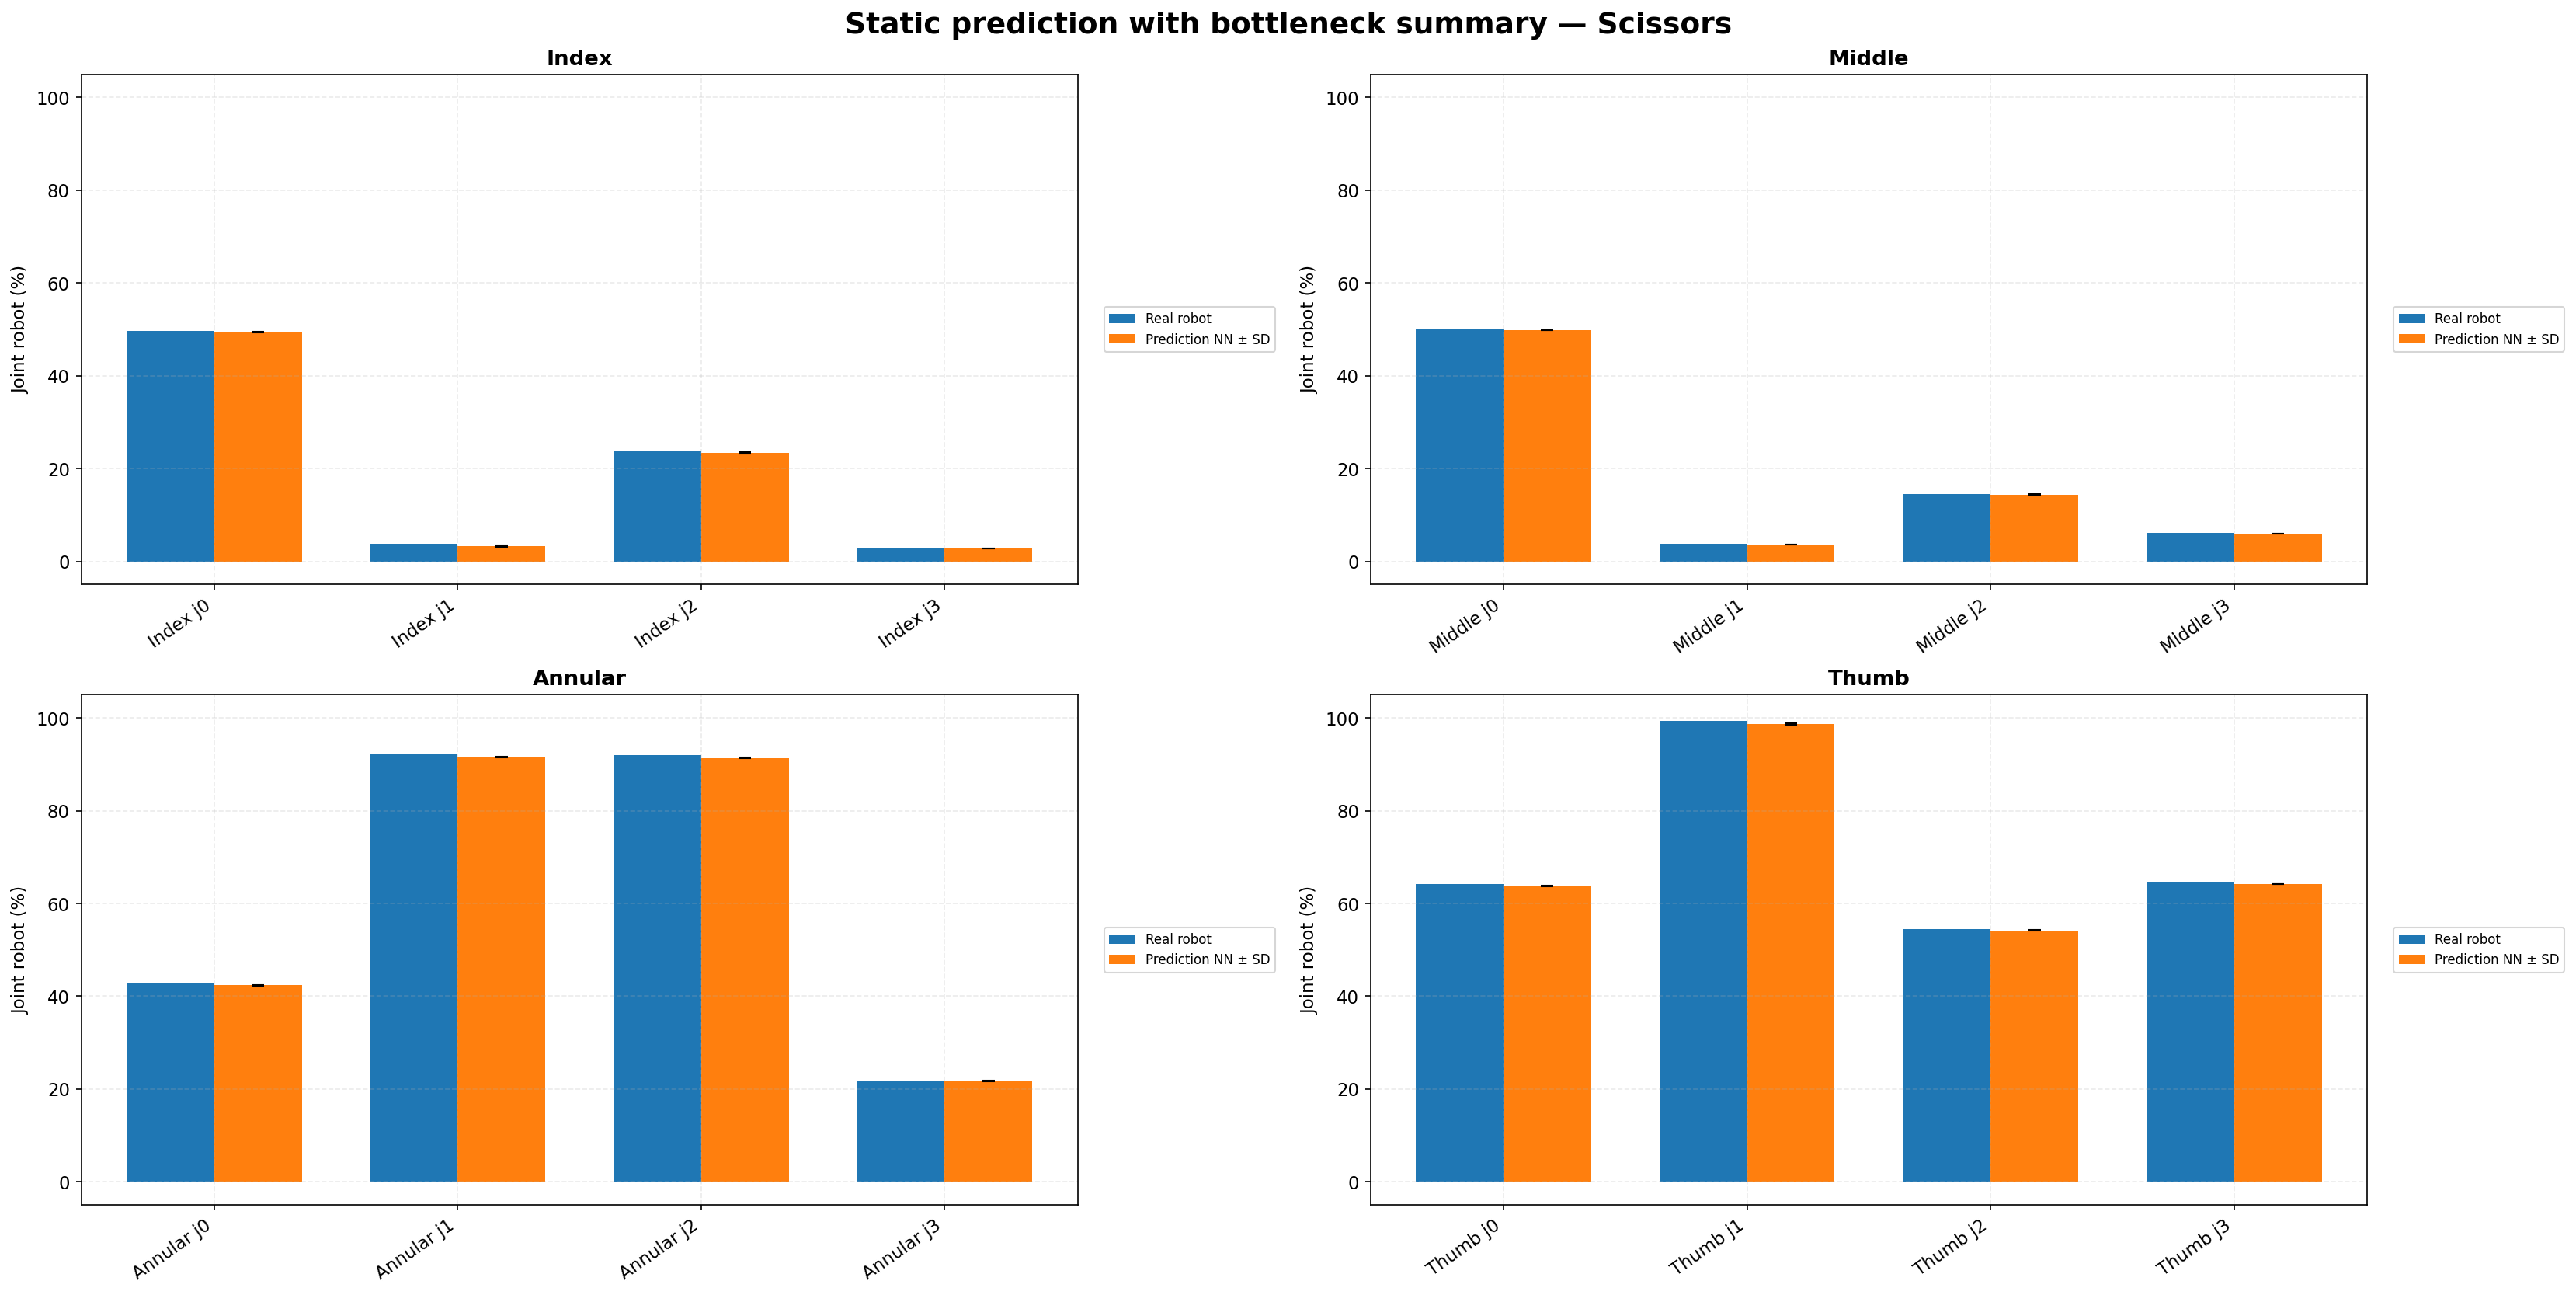

Generant resum estàtic: ThumbUpStat — Thumb Up


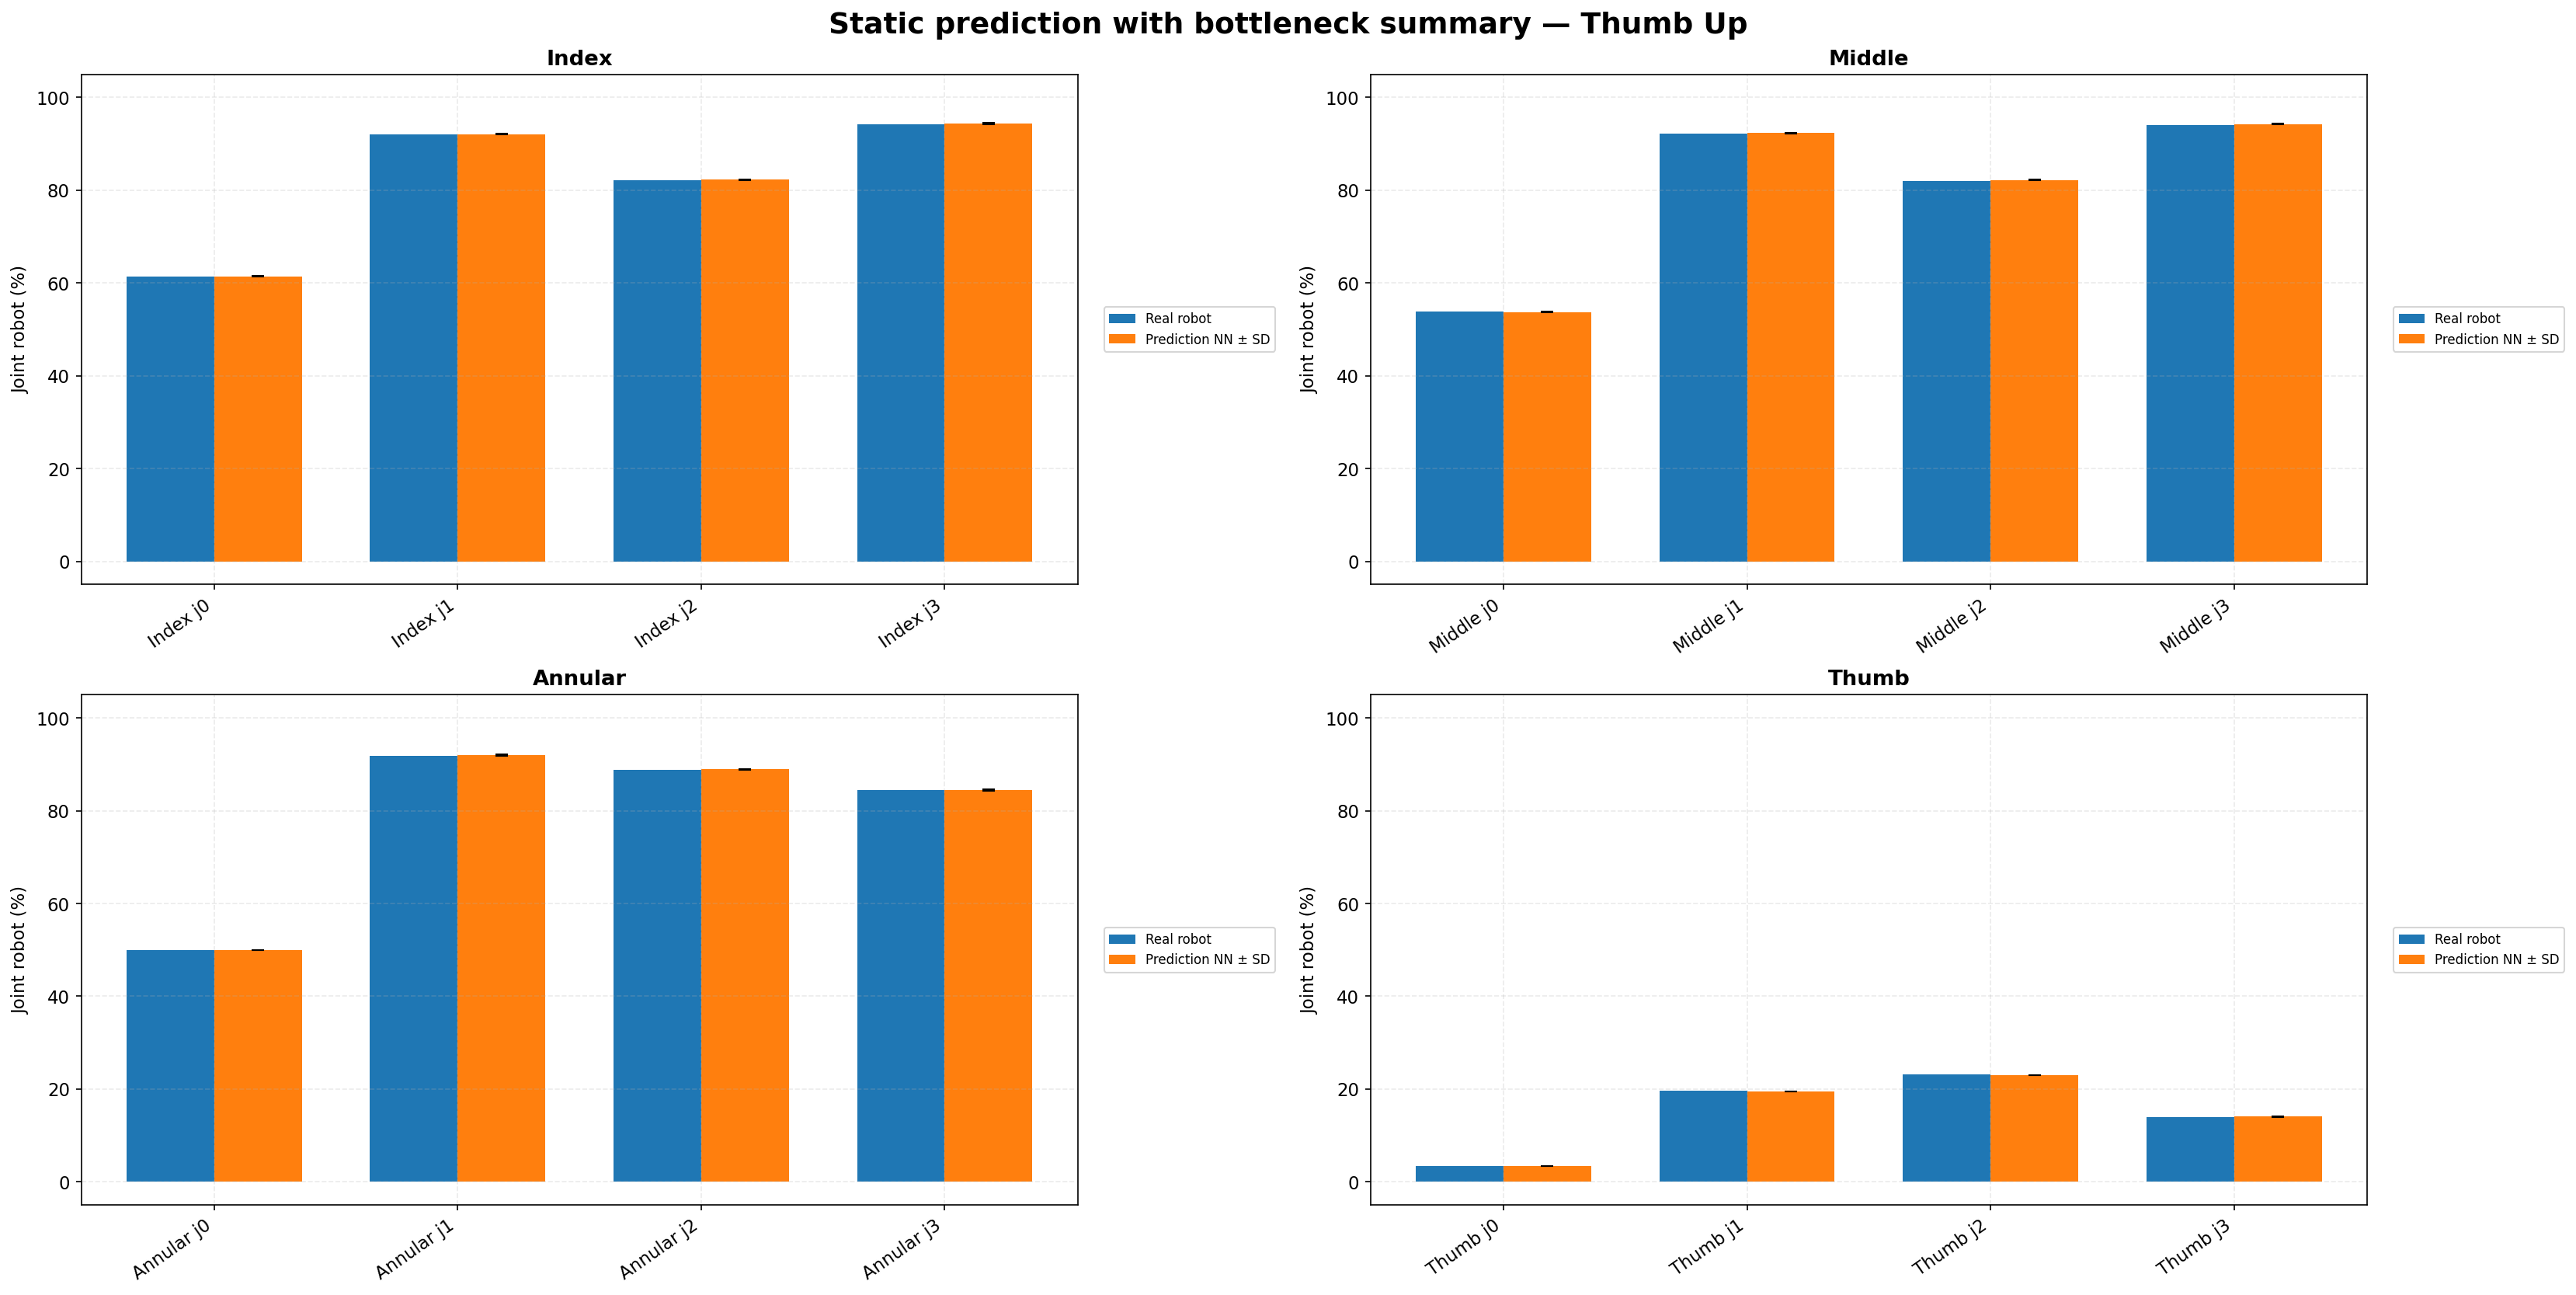

Resums estàtics generats.


In [26]:

# ============================================================
# RESUM DE PREDICCIONS PER POSICIÓ ESTÀTICA
# ============================================================

def plot_static_prediction_summary_2x2(pos, position_metrics_df, output_dir):
    """Figura resum 2x2 per posició estàtica: robot real vs predicció mitjana ± SD."""

    pos_name = static_position_names[pos]
    pos_folder = output_dir / pos / "summary_predictions"
    pos_folder.mkdir(parents=True, exist_ok=True)

    subset = position_metrics_df[
        position_metrics_df["position_code"] == pos
    ].copy()

    if subset.empty:
        print(f"No hi ha dades per a {pos}")
        return

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(22, 11),
        dpi=150,
        constrained_layout=True,
    )

    axes = axes.flatten()

    summary_rows = []

    for ax, (group_name, joints) in zip(axes, robot_groups.items()):
        group_subset = subset[
            subset["joint"].isin(joints)
        ].copy()

        group_subset["joint"] = pd.Categorical(
            group_subset["joint"],
            categories=joints,
            ordered=True,
        )

        group_subset = group_subset.sort_values("joint")

        x = np.arange(len(group_subset))
        width = 0.36

        ax.bar(
            x - width / 2,
            group_subset["true_mean"],
            width,
            label="Real robot",
        )

        ax.bar(
            x + width / 2,
            group_subset["pred_mean"],
            width,
            yerr=group_subset["pred_std"],
            capsize=4,
            label="Prediction NN ± SD",
        )

        ax.set_title(
            group_name,
            fontweight="bold",
        )

        ax.set_xticks(x)
        ax.set_xticklabels(group_subset["joint"], rotation=35, ha="right")
        ax.set_ylabel("Joint robot (%)")
        ax.set_ylim(-5, 105)

        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fontsize=8,
        )

        summary_rows.append(group_subset)

    fig.suptitle(
        f"Static prediction with bottleneck summary — {pos_name}",
        fontsize=18,
        fontweight="bold",
    )

    fig.savefig(
        pos_folder / f"{pos}_summary_static_prediction_2x2_bottleneck.png",
        bbox_inches="tight",
    )

    fig.savefig(
        pos_folder / f"{pos}_summary_static_prediction_2x2_bottleneck.pdf",
        bbox_inches="tight",
    )

    summary_df = pd.concat(summary_rows, ignore_index=True)

    summary_df.to_csv(
        pos_folder / f"{pos}_summary_static_prediction_metrics.csv",
        index=False,
    )

    plt.show()


# ============================================================
# GENERAR TOTS ELS RESUMS PER POSICIÓ
# ============================================================

for pos in sorted(position_metrics_df["position_code"].unique()):
    print(f"Generant resum estàtic: {pos} — {static_position_names[pos]}")

    plot_static_prediction_summary_2x2(
        pos,
        position_metrics_df,
        output_dir,
    )

print("Resums estàtics generats.")


In [23]:
# ============================================================
# GUARDAR MODEL
# ============================================================

model.save(output_dir / "glove_to_robot_static_bottleneck.keras")

with open(output_dir / "x_scaler.pkl", "wb") as f:
    pickle.dump(x_scaler, f)

config = {
    "input_joints": input_joints,
    "robot_joint_order": robot_joint_order,
    "glove_value_key": glove_value_key,
    "clip_to_0_100": clip_to_0_100,
    "use_bottleneck": use_bottleneck,
    "bottleneck_dim": bottleneck_dim,
    "bottleneck_activation": bottleneck_activation,
    "bottleneck_l1": bottleneck_l1,
}

with open(output_dir / "model_config.pkl", "wb") as f:
    pickle.dump(config, f)

print("Model, scaler i configuració guardats a:", output_dir)


Model, scaler i configuració guardats a: nn_static_glove_to_robot_bottleneck


## Nota important

Aquest model pot donar errors molt baixos perquè totes les mostres d’una mateixa postura tenen el mateix vector objectiu del robot.  
Per validar generalització real, el següent pas seria fer **leave-one-position-out**: entrenar amb 5 postures i provar amb la postura que queda fora.


## Com provar diferents graus d'estrangulació

Aquest notebook comença amb:

```python
bottleneck_dim = 18
```

Per reduir més:

```python
bottleneck_dim = 16
bottleneck_dim = 12
bottleneck_dim = 8
```

Compara sempre:

- `MAE global`
- `RMSE global`
- error per joint
- `bottleneck_representation_test_static.csv`
- `bottleneck_heatmap_static.png`

Si el MAE es manté semblant, la compressió està funcionant.


In [27]:

# ============================================================
# DESCARREGAR RESULTATS DE COLAB EN ZIP
# ============================================================

import shutil
from pathlib import Path

zip_name = "resultats_bottleneck_estatic"

zip_path = shutil.make_archive(
    zip_name,
    "zip",
    output_dir,
)

print("ZIP creat:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("No s'ha pogut iniciar la descàrrega automàtica.")
    print("Pots descarregar manualment aquest fitxer:")
    print(zip_path)
    print("Error:", e)


ZIP creat: /content/resultats_bottleneck_estatic.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>